## Análisis Bivariable

### By:
Karen Ninco

### Date:
2026-08-21

### Description:

#### Requerimiento
Realizar un análisis exploratorio de datos (EDA) para caracterizar los datos disponibles del proyecto, continuando con el análisis bivariable: la relación entre la variable objetivo (`disease`) y cada una de las demás variables, así como las relaciones entre las variables predictoras entre sí (numérica-numérica, categórica-categórica y categórica-numérica).

Tomar como ejemplo los pasos de: https://joserzapata.github.io/post/ciencia-datos-proyecto-python/3-analysis/bivariate-data-analysis/

Para cada relación se estudia mediante gráficos (boxplots, densidad, dispersión, tablas cruzadas y barras) y, cuando aplica, tasas o promedios agrupados, buscando identificar patrones, asociaciones y posibles variables relevantes para el modelo.

#### Entregables:
Notebook con el análisis bivariable de los datos.
Se debe realizar un Pull request para ingresar el notebook a la rama main, con mínimo 1 revisión y que pase los checks de CI/CD.


## 📚 Import libraries

In [833]:
import sys
import warnings
from pathlib import Path

import pandas as pd
import seaborn as sns

warnings.simplefilter(action="ignore", category=FutureWarning)

In [834]:
pd.set_option("display.float_format", "{:.2f}".format)

In [835]:
print("Python version: ", sys.version)
print("Pandas version: ", pd.__version__)

Python version:  3.12.3 (main, Jun 19 2026, 12:46:00) [GCC 13.3.0]
Pandas version:  3.0.5


## 💾 Load data

In [836]:
DATA_DIR = Path.cwd().resolve().parents[1] / "data" / "02_intermediate"
corazon_df = pd.read_parquet(DATA_DIR / "corazon_clean.parquet")

## 📊 Data description

#### General data information

In [837]:
corazon_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3030 entries, 0 to 3029
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   age         2998 non-null   float64 
 1   sex         2966 non-null   category
 2   chest_pain  2944 non-null   category
 3   rest_bp     2947 non-null   float64 
 4   chol        2943 non-null   float64 
 5   fbs         2933 non-null   boolean 
 6   rest_ecg    2832 non-null   category
 7   max_hr      2858 non-null   Int16   
 8   exang       2877 non-null   boolean 
 9   old_peak    2878 non-null   float64 
 10  slope       2878 non-null   category
 11  ca          2867 non-null   Int8    
 12  thal        2900 non-null   category
 13  disease     2919 non-null   boolean 
dtypes: Int16(1), Int8(1), boolean(3), category(5), float64(4)
memory usage: 142.5 KB


In [838]:
# size of the dataframe
corazon_df.shape

(3030, 14)

In [839]:
# sample of the dataframe
corazon_df.sample(5)

,age,sex,chest_pain,rest_bp,chol,fbs,rest_ecg,max_hr,exang,old_peak,slope,ca,thal,disease
1847,40.00,Male,asymptomatic,110.00,167.00,False,left ventricular hypertrophy,114,True,2.00,2,0,reversable,True
1923,54.00,Male,nontypical,108.00,309.00,False,normal,156,False,0.00,1,0,reversable,False
1387,57.00,Male,asymptomatic,152.00,274.00,False,normal,88,True,1.20,2,1,reversable,True
1965,41.00,Male,nonanginal,112.00,250.00,False,normal,179,False,0.00,1,0,normal,False
1540,50.00,Female,nonanginal,120.00,219.00,False,normal,158,False,1.60,2,0,normal,False


#### Number of missing values

In [840]:
corazon_df.isnull().sum()

age            32
sex            64
chest_pain     86
rest_bp        83
chol           87
fbs            97
rest_ecg      198
max_hr        172
exang         153
old_peak      152
slope         152
ca            163
thal          130
disease       111
dtype: int64

Target Variable = disease

### General statistics of the data set

#### Numerical variables

In [841]:
corazon_df.describe()

,age,rest_bp,chol,max_hr,old_peak,ca
count,2998.00,2947.00,2943.00,2858.00,2878.00,2867.00
mean,54.46,131.62,246.72,149.56,1.04,0.67
std,9.02,17.57,51.60,22.88,1.16,0.94
min,29.00,94.00,126.00,71.00,0.00,0.00
25%,48.00,120.00,211.00,133.00,0.00,0.00
50%,56.00,130.00,241.00,153.00,0.80,0.00
75%,61.00,140.00,275.00,166.00,1.60,1.00
max,77.00,200.00,564.00,202.00,6.20,3.00


#### Categorical variables

In [842]:
corazon_df.describe(include="category")

,sex,chest_pain,rest_ecg,slope,thal
count,2966,2944,2832,2878,2900
unique,2,4,3,3,3
top,Male,asymptomatic,normal,1,normal
freq,2017,1394,1409,1353,1599


## 📈 Bivariate Analysis

### Target vs Numerical Variables

#### disease vs age

age    Axes(0.125,0.11;0.775x0.77)
dtype: object

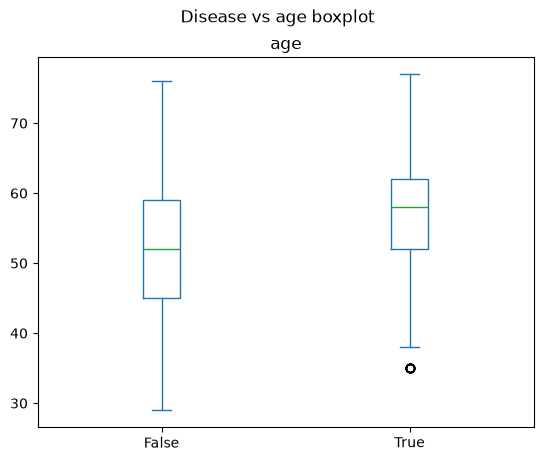

In [843]:
variable = "age"
corazon_df.plot(
    kind="box",
    column=variable,
    by="disease",
    grid=False,
    title=f"Disease vs {variable} boxplot",
)

<Axes: title={'center': 'Disease vs age density plot'}, ylabel='Density'>

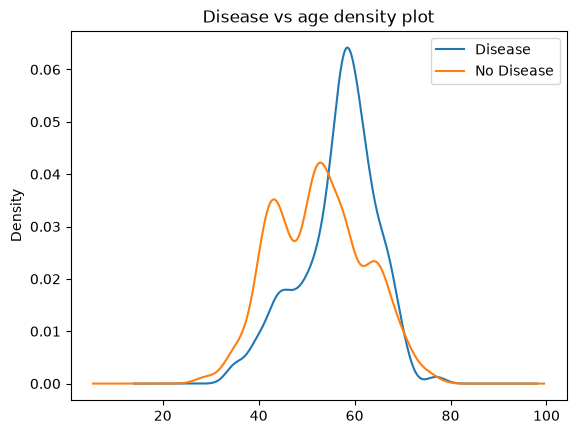

In [844]:
corazon_df[corazon_df["disease"].eq(True)][variable].plot(
    kind="kde",
    label="Disease",
    legend=True,
    title=f"Disease vs {variable} density plot",
)
corazon_df[corazon_df["disease"].eq(False)][variable].plot(
    kind="kde", label="No Disease", legend=True, xlabel=variable, ylabel="Density"
)

#### disease vs rest_bp

rest_bp    Axes(0.125,0.11;0.775x0.77)
dtype: object

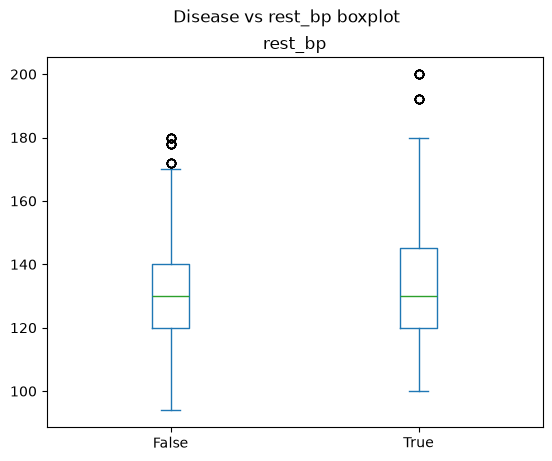

In [845]:
variable = "rest_bp"
corazon_df.plot(
    kind="box",
    column=variable,
    by="disease",
    grid=False,
    title=f"Disease vs {variable} boxplot",
)

<Axes: title={'center': 'Disease vs rest_bp density plot'}, ylabel='Density'>

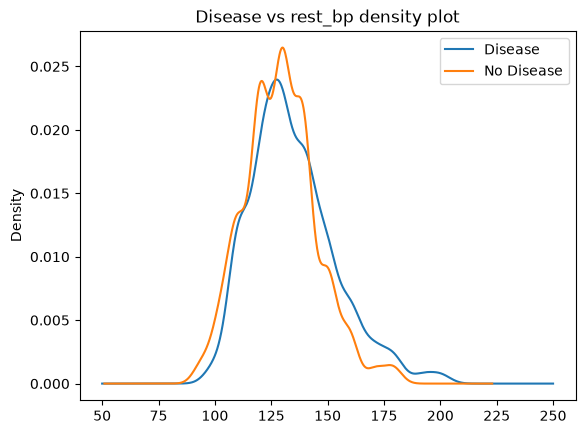

In [846]:
corazon_df[corazon_df["disease"].eq(True)][variable].plot(
    kind="kde",
    label="Disease",
    legend=True,
    title=f"Disease vs {variable} density plot",
)
corazon_df[corazon_df["disease"].eq(False)][variable].plot(
    kind="kde", label="No Disease", legend=True, xlabel=variable, ylabel="Density"
)

#### disease vs chol

chol    Axes(0.125,0.11;0.775x0.77)
dtype: object

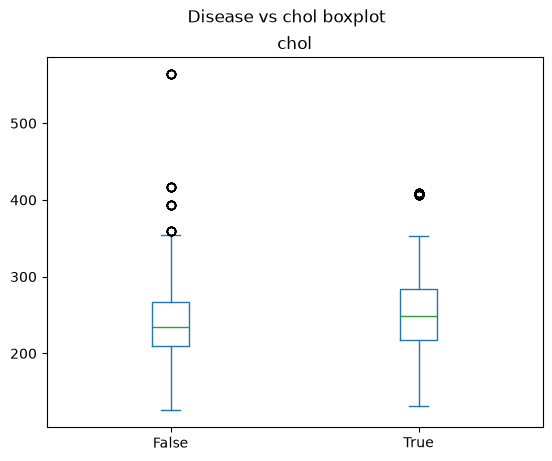

In [847]:
variable = "chol"
corazon_df.plot(
    kind="box",
    column=variable,
    by="disease",
    grid=False,
    title=f"Disease vs {variable} boxplot",
)

<Axes: title={'center': 'Disease vs chol density plot'}, ylabel='Density'>

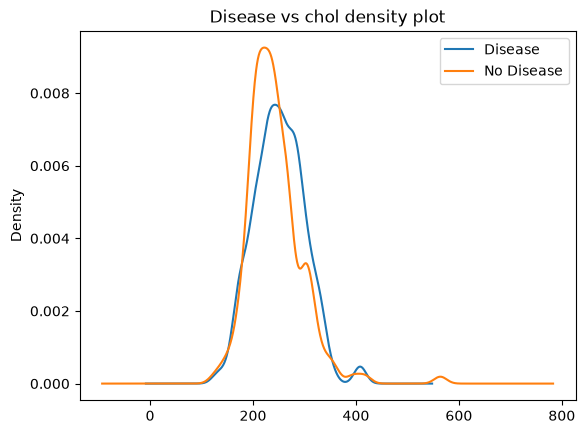

In [848]:
corazon_df[corazon_df["disease"].eq(True)][variable].plot(
    kind="kde",
    label="Disease",
    legend=True,
    title=f"Disease vs {variable} density plot",
)
corazon_df[corazon_df["disease"].eq(False)][variable].plot(
    kind="kde", label="No Disease", legend=True, xlabel=variable, ylabel="Density"
)

#### disease vs old_peak

old_peak    Axes(0.125,0.11;0.775x0.77)
dtype: object

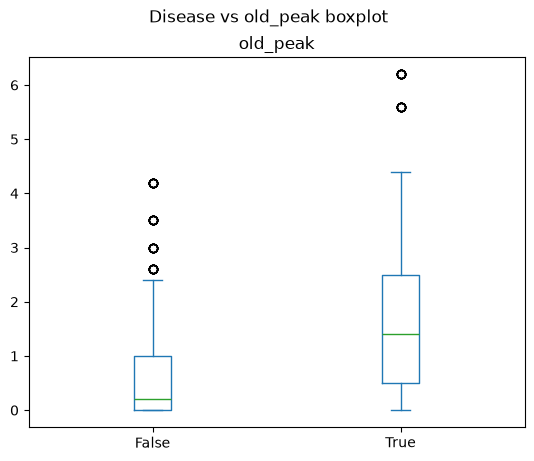

In [849]:
variable = "old_peak"
corazon_df.plot(
    kind="box",
    column=variable,
    by="disease",
    grid=False,
    title=f"Disease vs {variable} boxplot",
)

<Axes: title={'center': 'Disease vs old_peak density plot'}, ylabel='Density'>

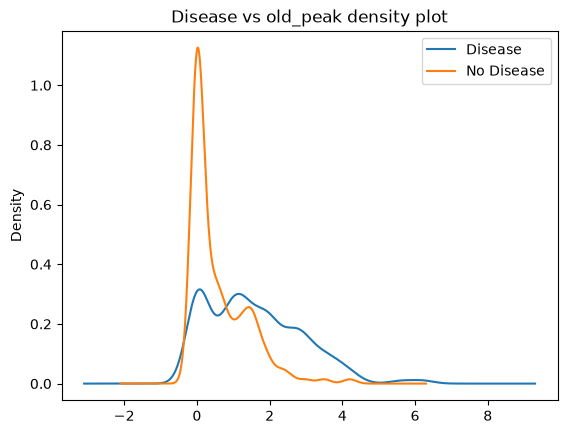

In [850]:
corazon_df[corazon_df["disease"].eq(True)][variable].plot(
    kind="kde",
    label="Disease",
    legend=True,
    title=f"Disease vs {variable} density plot",
)
corazon_df[corazon_df["disease"].eq(False)][variable].plot(
    kind="kde", label="No Disease", legend=True, xlabel=variable, ylabel="Density"
)

#### disease vs max_hr

max_hr    Axes(0.125,0.11;0.775x0.77)
dtype: object

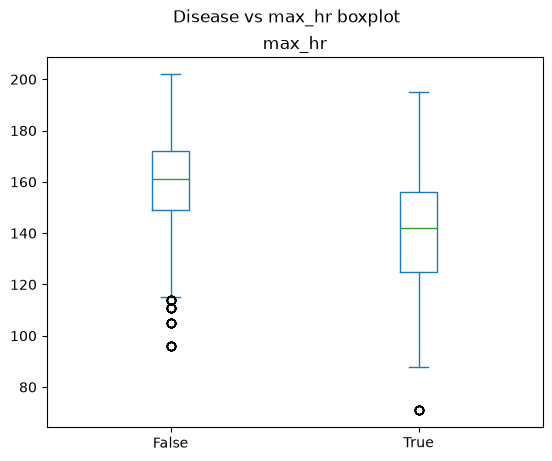

In [851]:
variable = "max_hr"
corazon_df.plot(
    kind="box",
    column=variable,
    by="disease",
    grid=False,
    title=f"Disease vs {variable} boxplot",
)

<Axes: title={'center': 'Disease vs max_hr density plot'}, ylabel='Density'>

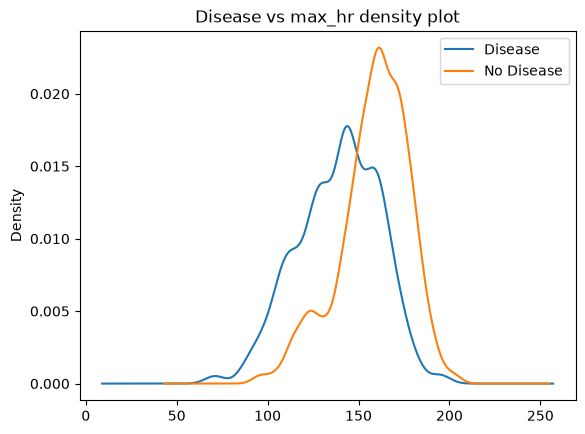

In [852]:
corazon_df[corazon_df["disease"].eq(True)][variable].plot(
    kind="kde",
    label="Disease",
    legend=True,
    title=f"Disease vs {variable} density plot",
)
corazon_df[corazon_df["disease"].eq(False)][variable].plot(
    kind="kde", label="No Disease", legend=True, xlabel=variable, ylabel="Density"
)

#### disease vs ca

ca    Axes(0.125,0.11;0.775x0.77)
dtype: object

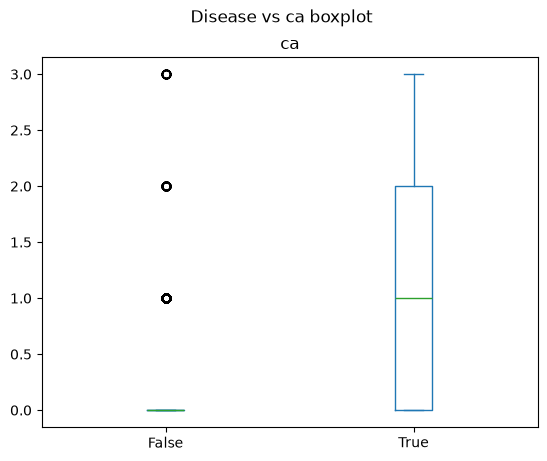

In [853]:
variable = "ca"
corazon_df.plot(
    kind="box",
    column=variable,
    by="disease",
    grid=False,
    title=f"Disease vs {variable} boxplot",
)

<Axes: title={'center': 'Disease vs ca histogram'}, xlabel='ca', ylabel='Frequency'>

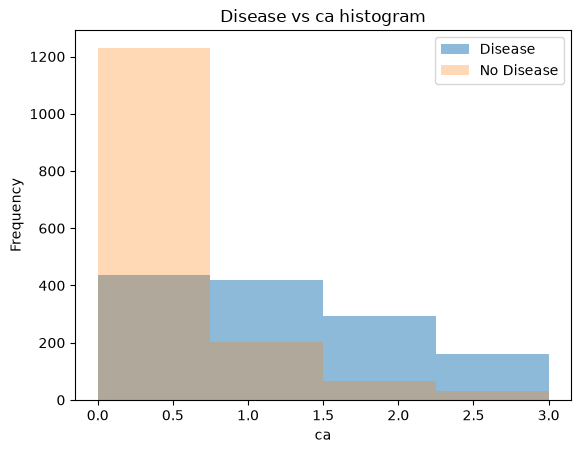

In [854]:
corazon_df[corazon_df["disease"].eq(True)][variable].plot(
    kind="hist",
    label="Disease",
    legend=True,
    bins=4,
    alpha=0.5,
    title=f"Disease vs {variable} histogram",
)
corazon_df[corazon_df["disease"].eq(False)][variable].plot(
    kind="hist",
    label="No Disease",
    legend=True,
    bins=4,
    alpha=0.3,
    xlabel=variable,
    ylabel="Frequency",
)

### Target vs Categorical Variables

#### disease vs sex

In [855]:
column = "sex"
(
    pd.crosstab(corazon_df[column], corazon_df["disease"], margins=True)
    .style.background_gradient(cmap="coolwarm")
    .set_caption(f"Disease vs {column} Heatmap")
)

disease,False,True,All
sex,,,
Female,683,243,926
Male,866,1078,1944
All,1549,1321,2870


In [856]:
corazon_df.groupby(column, observed=True).agg({"disease": "mean"}) * 100

,disease
sex,
Female,26.24
Male,55.45


<Axes: title={'center': 'Disease vs sex stacked barplot'}, xlabel='sex'>

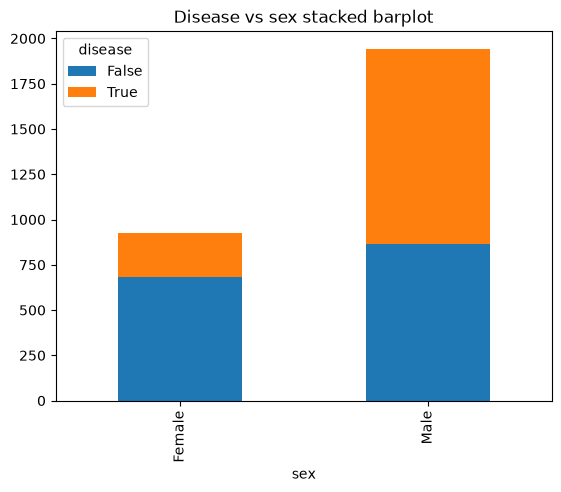

In [857]:
(
    pd.crosstab(corazon_df[column], corazon_df["disease"]).plot(
        kind="bar", stacked=True, title=f"Disease vs {column} stacked barplot"
    )
)

<Axes: title={'center': 'Disease vs sex barplot'}, xlabel='sex'>

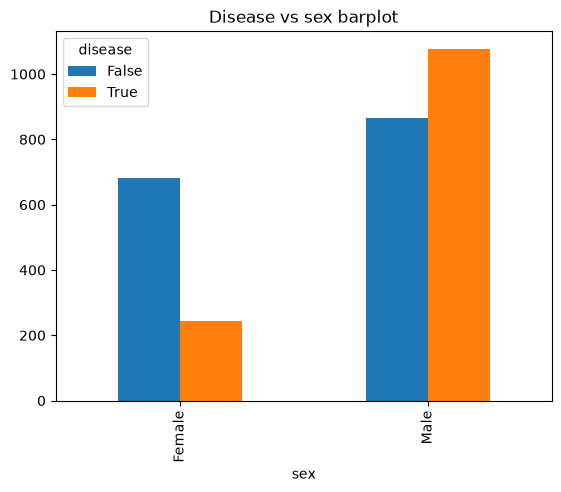

In [858]:
(
    pd.crosstab(corazon_df[column], corazon_df["disease"]).plot(
        kind="bar", title=f"Disease vs {column} barplot"
    )
)

#### disease vs chest_pain

In [859]:
column = "chest_pain"
(
    pd.crosstab(corazon_df[column], corazon_df["disease"], margins=True)
    .style.background_gradient(cmap="coolwarm")
    .set_caption(f"Disease vs {column} Heatmap")
)

disease,False,True,All
chest_pain,,,
asymptomatic,366,992,1358
nonanginal,644,169,813
nontypical,383,81,464
typical,149,64,213
All,1542,1306,2848


In [860]:
corazon_df.groupby(column, observed=True).agg({"disease": "mean"}) * 100

,disease
chest_pain,
asymptomatic,73.05
nonanginal,20.79
nontypical,17.46
typical,30.05


<Axes: title={'center': 'Disease vs chest_pain stacked barplot'}, xlabel='chest_pain'>

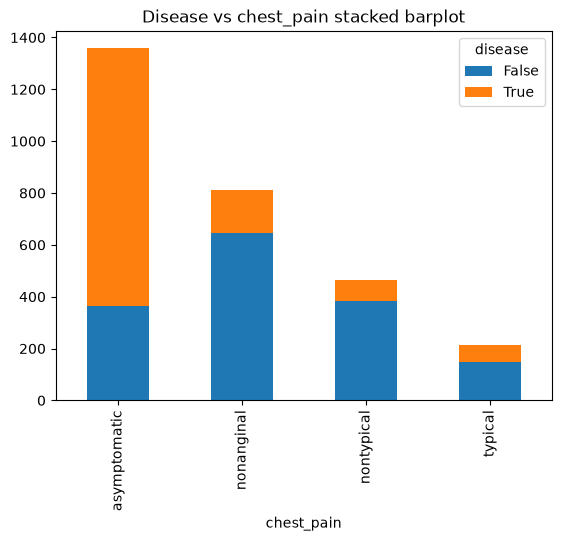

In [861]:
(
    pd.crosstab(corazon_df[column], corazon_df["disease"]).plot(
        kind="bar", stacked=True, title=f"Disease vs {column} stacked barplot"
    )
)

<Axes: title={'center': 'Disease vs chest_pain barplot'}, xlabel='chest_pain'>

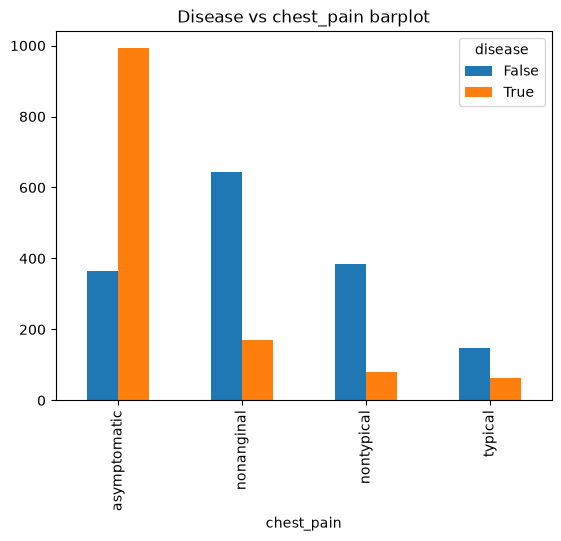

In [862]:
(
    pd.crosstab(corazon_df[column], corazon_df["disease"]).plot(
        kind="bar", title=f"Disease vs {column} barplot"
    )
)

#### disease vs rest_ecg

In [863]:
column = "rest_ecg"
(
    pd.crosstab(corazon_df[column], corazon_df["disease"], margins=True)
    .style.background_gradient(cmap="coolwarm")
    .set_caption(f"Disease vs {column} Heatmap")
)

disease,False,True,All
rest_ecg,,,
ST-T wave abnormality,8,27,35
left ventricular hypertrophy,632,745,1377
normal,879,512,1391
All,1519,1284,2803


In [864]:
corazon_df.groupby(column, observed=True).agg({"disease": "mean"}) * 100

,disease
rest_ecg,
ST-T wave abnormality,77.14
left ventricular hypertrophy,54.10
normal,36.81


<Axes: title={'center': 'Disease vs rest_ecg stacked barplot'}, xlabel='rest_ecg'>

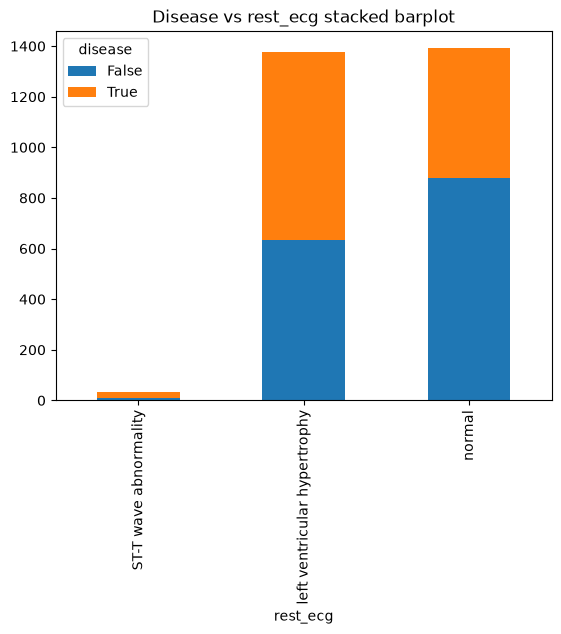

In [865]:
(
    pd.crosstab(corazon_df[column], corazon_df["disease"]).plot(
        kind="bar", stacked=True, title=f"Disease vs {column} stacked barplot"
    )
)

<Axes: title={'center': 'Disease vs rest_ecg barplot'}, xlabel='rest_ecg'>

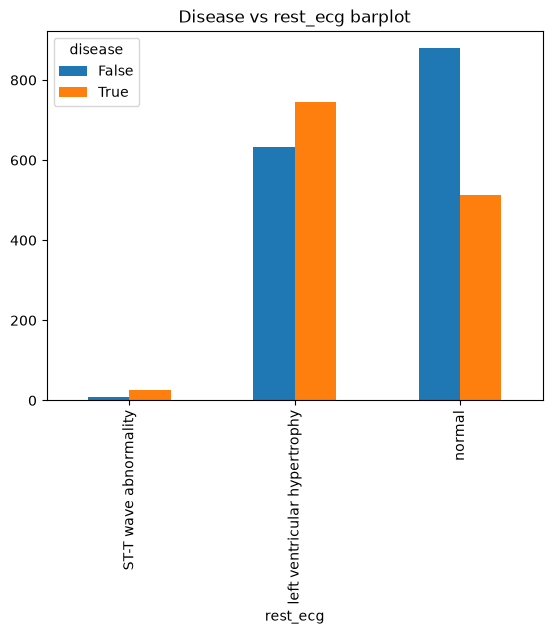

In [866]:
(
    pd.crosstab(corazon_df[column], corazon_df["disease"]).plot(
        kind="bar", title=f"Disease vs {column} barplot"
    )
)

#### disease vs slope

In [867]:
column = "slope"
(
    pd.crosstab(corazon_df[column], corazon_df["disease"], margins=True)
    .style.background_gradient(cmap="coolwarm")
    .set_caption(f"Disease vs {column} Heatmap")
)

disease,False,True,All
slope,,,
1,1004,331,1335
2,453,859,1312
3,89,113,202
All,1546,1303,2849


In [868]:
corazon_df.groupby(column, observed=True).agg({"disease": "mean"}) * 100

,disease
slope,
1,24.79
2,65.47
3,55.94


<Axes: title={'center': 'Disease vs slope stacked barplot'}, xlabel='slope'>

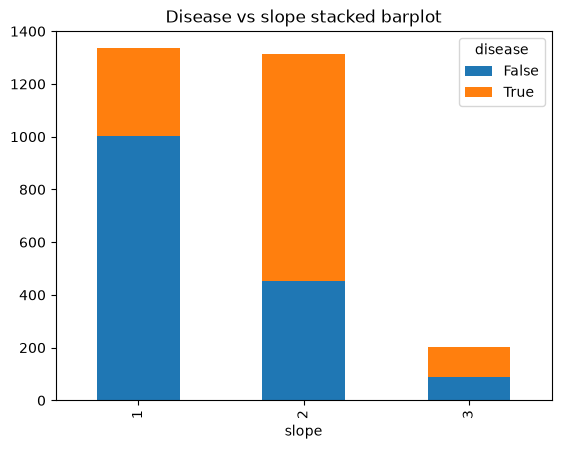

In [869]:
(
    pd.crosstab(corazon_df[column], corazon_df["disease"]).plot(
        kind="bar", stacked=True, title=f"Disease vs {column} stacked barplot"
    )
)

<Axes: title={'center': 'Disease vs slope barplot'}, xlabel='slope'>

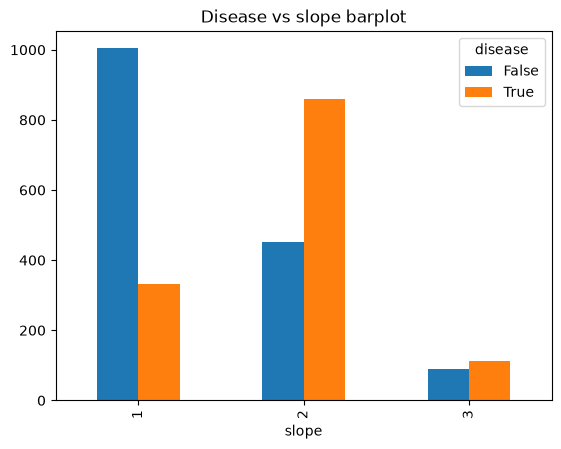

In [870]:
(
    pd.crosstab(corazon_df[column], corazon_df["disease"]).plot(
        kind="bar", title=f"Disease vs {column} barplot"
    )
)

#### disease vs thal

In [871]:
column = "thal"
(
    pd.crosstab(corazon_df[column], corazon_df["disease"], margins=True)
    .style.background_gradient(cmap="coolwarm")
    .set_caption(f"Disease vs {column} Heatmap")
)

disease,False,True,All
thal,,,
fixed,54,115,169
normal,1229,352,1581
reversable,268,854,1122
All,1551,1321,2872


In [872]:
corazon_df.groupby(column, observed=True).agg({"disease": "mean"}) * 100

,disease
thal,
fixed,68.05
normal,22.26
reversable,76.11


<Axes: title={'center': 'Disease vs thal stacked barplot'}, xlabel='thal'>

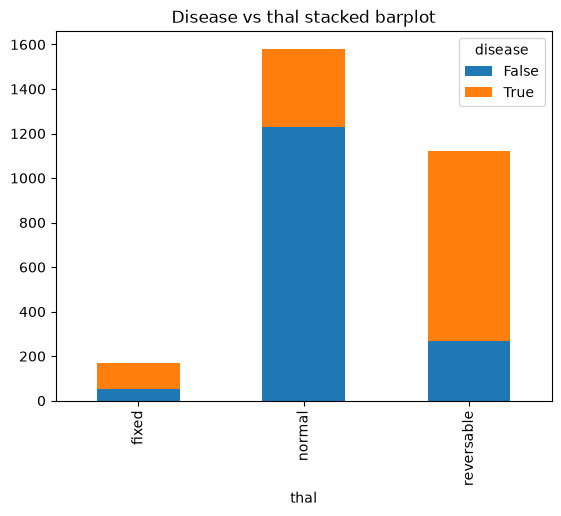

In [873]:
(
    pd.crosstab(corazon_df[column], corazon_df["disease"]).plot(
        kind="bar", stacked=True, title=f"Disease vs {column} stacked barplot"
    )
)

<Axes: title={'center': 'Disease vs thal barplot'}, xlabel='thal'>

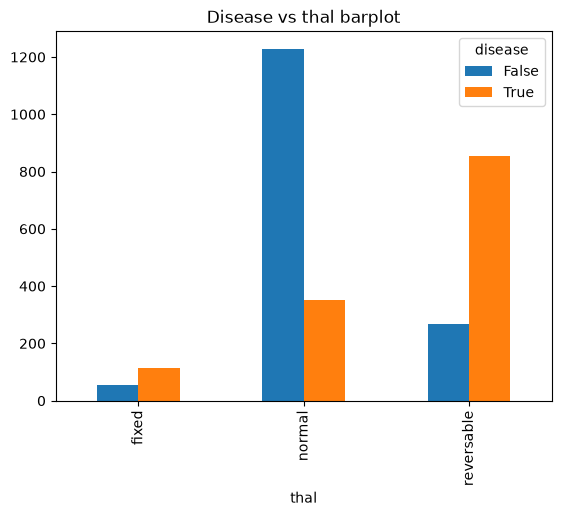

In [874]:
(
    pd.crosstab(corazon_df[column], corazon_df["disease"]).plot(
        kind="bar", title=f"Disease vs {column} barplot"
    )
)

#### disease vs fbs

In [875]:
column = "fbs"
(
    pd.crosstab(corazon_df[column], corazon_df["disease"], margins=True)
    .style.background_gradient(cmap="coolwarm")
    .set_caption(f"Disease vs {column} Heatmap")
)

disease,False,True,All
fbs,,,
False,1318,1100,2418
True,217,202,419
All,1535,1302,2837


In [876]:
corazon_df.groupby(column, observed=True).agg({"disease": "mean"}) * 100

,disease
fbs,
False,45.49
True,48.21


<Axes: title={'center': 'Disease vs fbs stacked barplot'}, xlabel='fbs'>

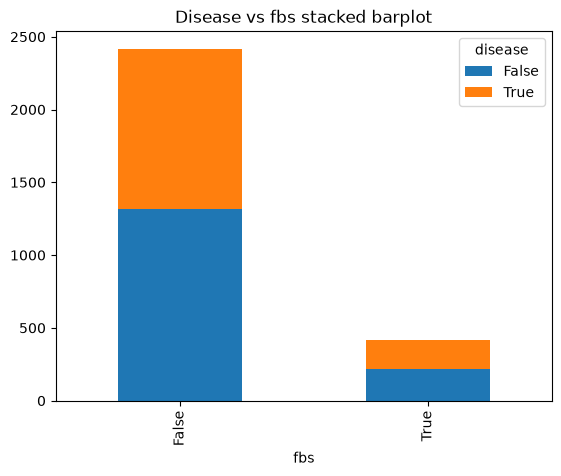

In [877]:
(
    pd.crosstab(corazon_df[column], corazon_df["disease"]).plot(
        kind="bar", stacked=True, title=f"Disease vs {column} stacked barplot"
    )
)

<Axes: title={'center': 'Disease vs fbs barplot'}, xlabel='fbs'>

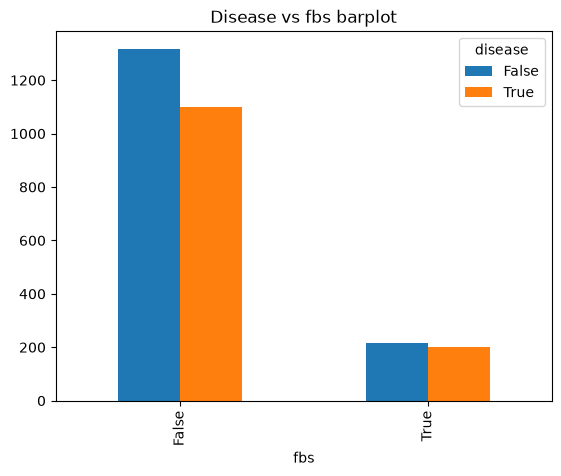

In [878]:
(
    pd.crosstab(corazon_df[column], corazon_df["disease"]).plot(
        kind="bar", title=f"Disease vs {column} barplot"
    )
)

#### disease vs exang

In [879]:
column = "exang"
(
    pd.crosstab(corazon_df[column], corazon_df["disease"], margins=True)
    .style.background_gradient(cmap="coolwarm")
    .set_caption(f"Disease vs {column} Heatmap")
)

disease,False,True,All
exang,,,
False,1323,584,1907
True,222,719,941
All,1545,1303,2848


In [880]:
corazon_df.groupby(column, observed=True).agg({"disease": "mean"}) * 100

,disease
exang,
False,30.62
True,76.41


<Axes: title={'center': 'Disease vs exang stacked barplot'}, xlabel='exang'>

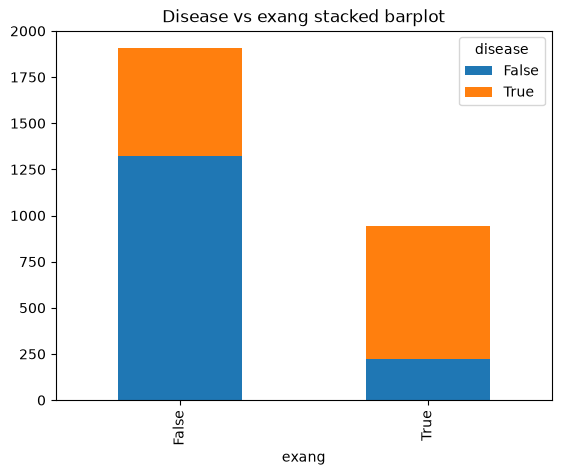

In [881]:
(
    pd.crosstab(corazon_df[column], corazon_df["disease"]).plot(
        kind="bar", stacked=True, title=f"Disease vs {column} stacked barplot"
    )
)

<Axes: title={'center': 'Disease vs exang barplot'}, xlabel='exang'>

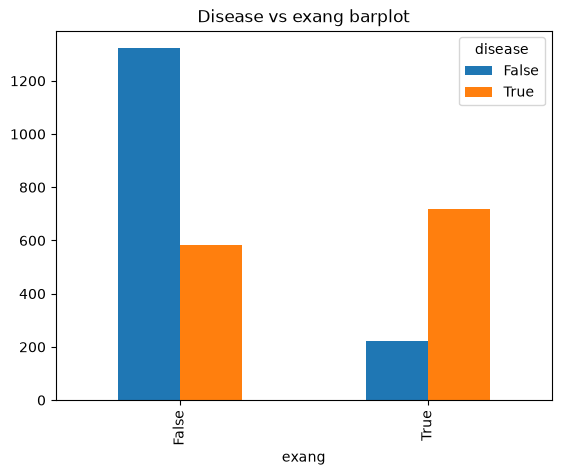

In [882]:
(
    pd.crosstab(corazon_df[column], corazon_df["disease"]).plot(
        kind="bar", title=f"Disease vs {column} barplot"
    )
)

### Numerical vs Numerical Variables

#### age vs rest_bp

<Axes: title={'center': 'age vs rest_bp scatter plot'}, xlabel='age', ylabel='rest_bp'>

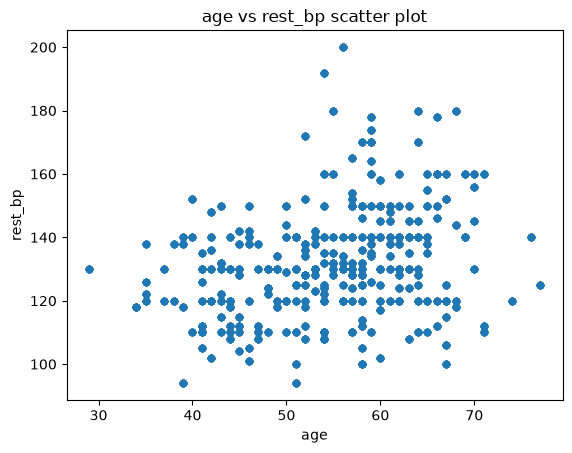

In [ ]:
corazon_df.plot(kind="scatter", x="age", y="rest_bp", title="age vs rest_bp scatter plot")

#### age vs chol

<Axes: title={'center': 'age vs chol scatter plot'}, xlabel='age', ylabel='chol'>

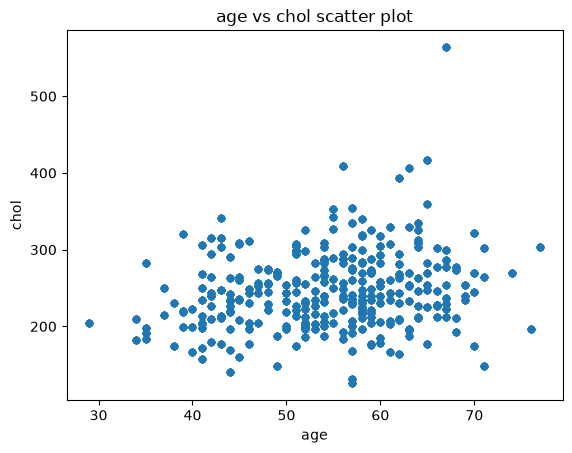

In [884]:
corazon_df.plot(kind="scatter", x="age", y="chol", title="age vs chol scatter plot")

#### age vs old_peak

<Axes: title={'center': 'age vs old_peak scatter plot'}, xlabel='age', ylabel='old_peak'>

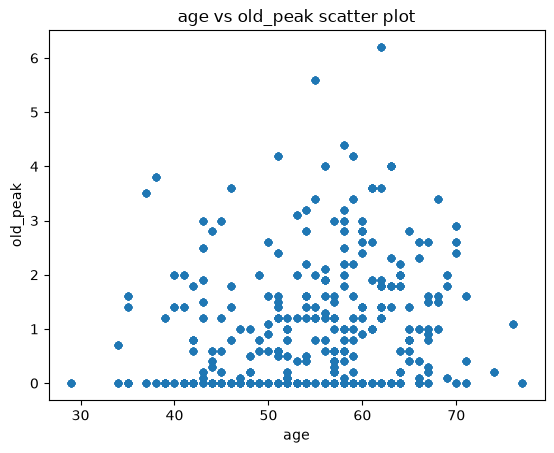

In [ ]:
corazon_df.plot(kind="scatter", x="age", y="old_peak", title="age vs old_peak scatter plot")

#### age vs max_hr

<Axes: title={'center': 'age vs max_hr scatter plot'}, xlabel='age', ylabel='max_hr'>

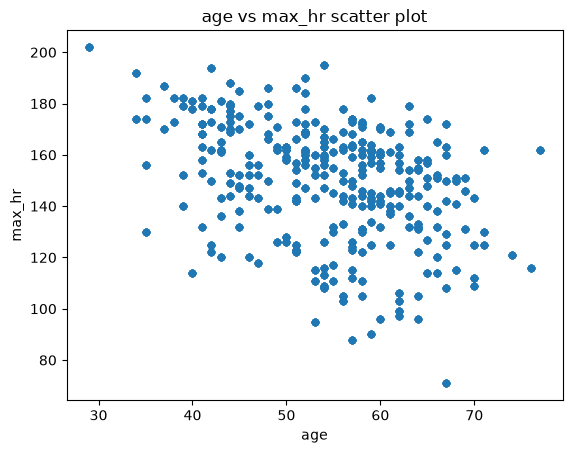

In [886]:
corazon_df.plot(kind="scatter", x="age", y="max_hr", title="age vs max_hr scatter plot")

#### age vs ca

<Axes: title={'center': 'age vs ca scatter plot'}, xlabel='age', ylabel='ca'>

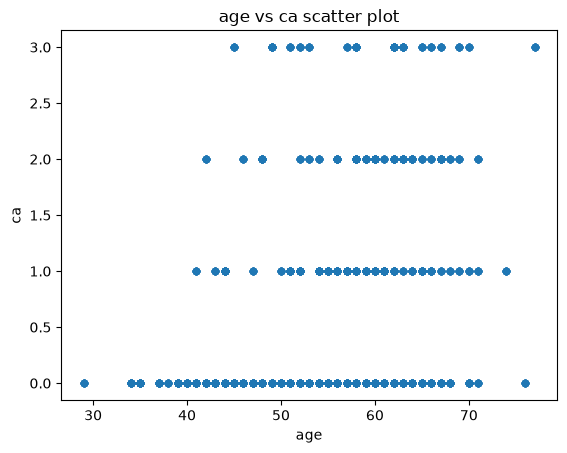

In [887]:
corazon_df.plot(kind="scatter", x="age", y="ca", title="age vs ca scatter plot")

#### rest_bp vs chol

<Axes: title={'center': 'rest_bp vs chol scatter plot'}, xlabel='rest_bp', ylabel='chol'>

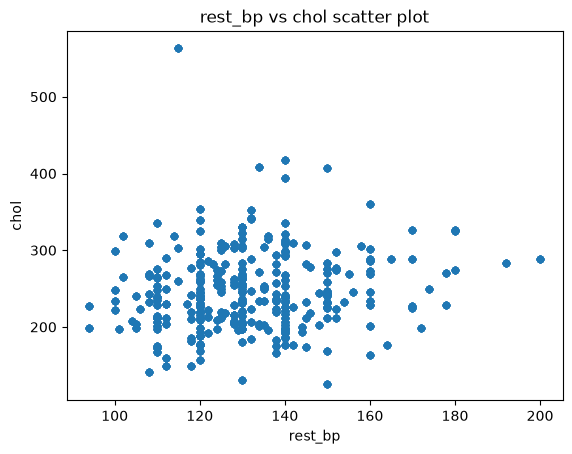

In [ ]:
corazon_df.plot(kind="scatter", x="rest_bp", y="chol", title="rest_bp vs chol scatter plot")

#### rest_bp vs old_peak

<Axes: title={'center': 'rest_bp vs old_peak scatter plot'}, xlabel='rest_bp', ylabel='old_peak'>

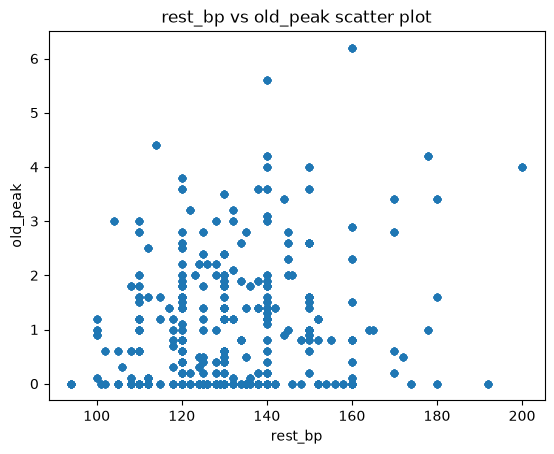

In [ ]:
corazon_df.plot(kind="scatter", x="rest_bp", y="old_peak", title="rest_bp vs old_peak scatter plot")

#### rest_bp vs max_hr

<Axes: title={'center': 'rest_bp vs max_hr scatter plot'}, xlabel='rest_bp', ylabel='max_hr'>

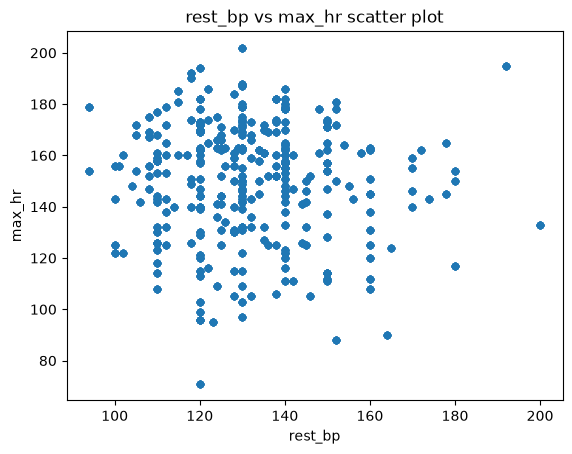

In [ ]:
corazon_df.plot(kind="scatter", x="rest_bp", y="max_hr", title="rest_bp vs max_hr scatter plot")

#### rest_bp vs ca

<Axes: title={'center': 'rest_bp vs ca scatter plot'}, xlabel='rest_bp', ylabel='ca'>

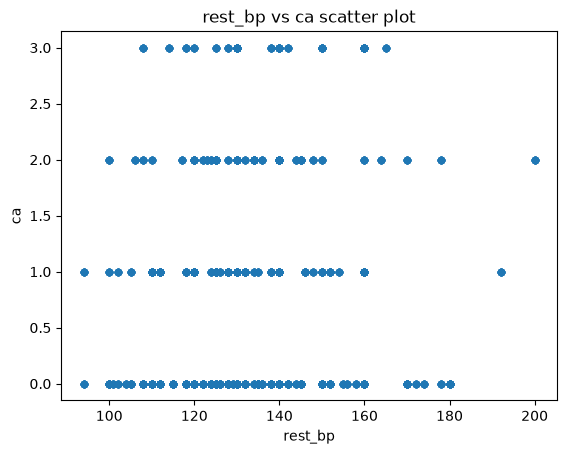

In [891]:
corazon_df.plot(kind="scatter", x="rest_bp", y="ca", title="rest_bp vs ca scatter plot")

#### chol vs old_peak

<Axes: title={'center': 'chol vs old_peak scatter plot'}, xlabel='chol', ylabel='old_peak'>

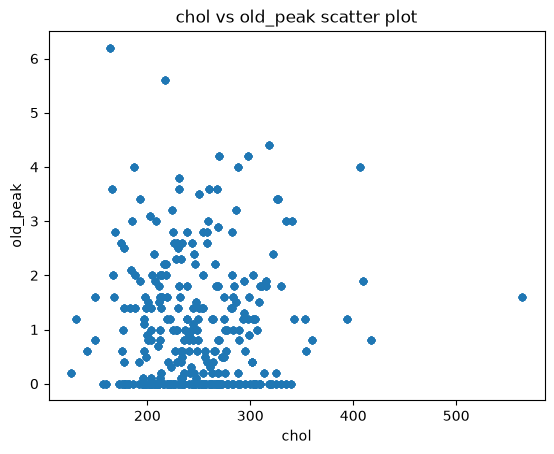

In [ ]:
corazon_df.plot(kind="scatter", x="chol", y="old_peak", title="chol vs old_peak scatter plot")

#### chol vs max_hr

<Axes: title={'center': 'chol vs max_hr scatter plot'}, xlabel='chol', ylabel='max_hr'>

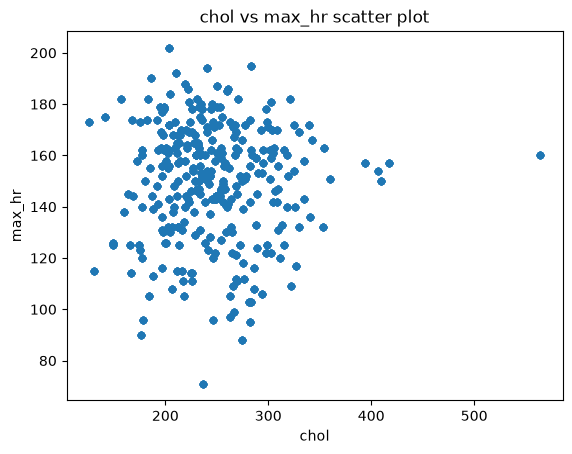

In [ ]:
corazon_df.plot(kind="scatter", x="chol", y="max_hr", title="chol vs max_hr scatter plot")

#### chol vs ca

<Axes: title={'center': 'chol vs ca scatter plot'}, xlabel='chol', ylabel='ca'>

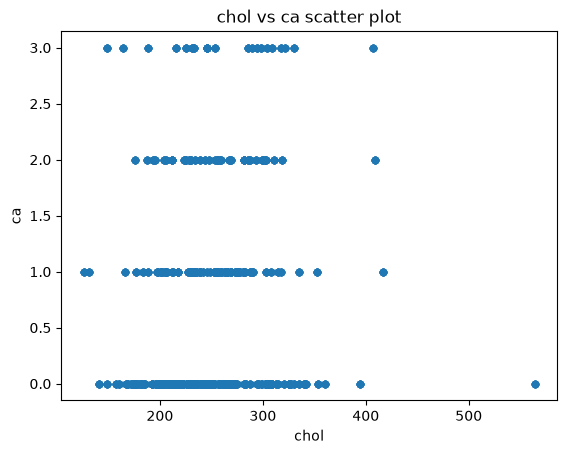

In [894]:
corazon_df.plot(kind="scatter", x="chol", y="ca", title="chol vs ca scatter plot")

#### old_peak vs max_hr

<Axes: title={'center': 'old_peak vs max_hr scatter plot'}, xlabel='old_peak', ylabel='max_hr'>

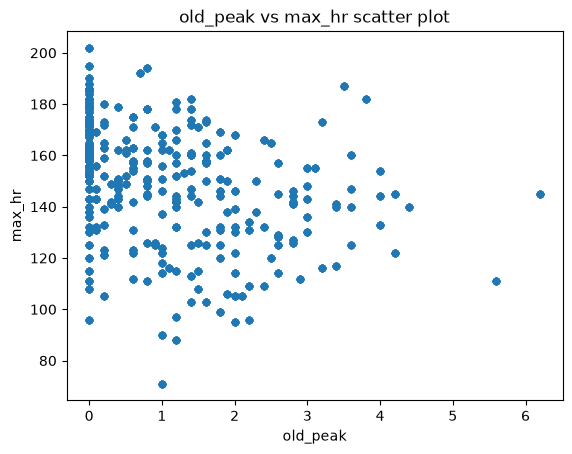

In [ ]:
corazon_df.plot(kind="scatter", x="old_peak", y="max_hr", title="old_peak vs max_hr scatter plot")

#### old_peak vs ca

<Axes: title={'center': 'old_peak vs ca scatter plot'}, xlabel='old_peak', ylabel='ca'>

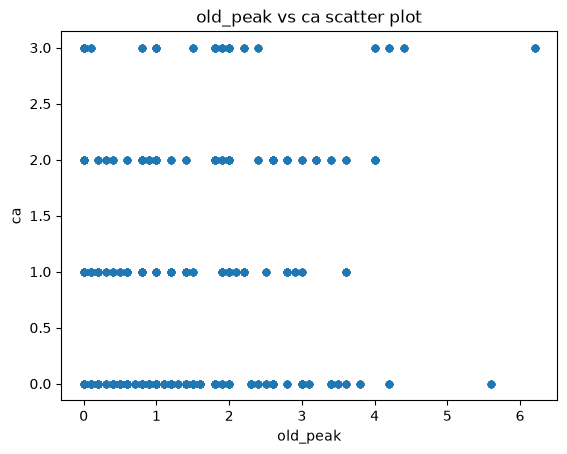

In [ ]:
corazon_df.plot(kind="scatter", x="old_peak", y="ca", title="old_peak vs ca scatter plot")

#### max_hr vs ca

<Axes: title={'center': 'max_hr vs ca scatter plot'}, xlabel='max_hr', ylabel='ca'>

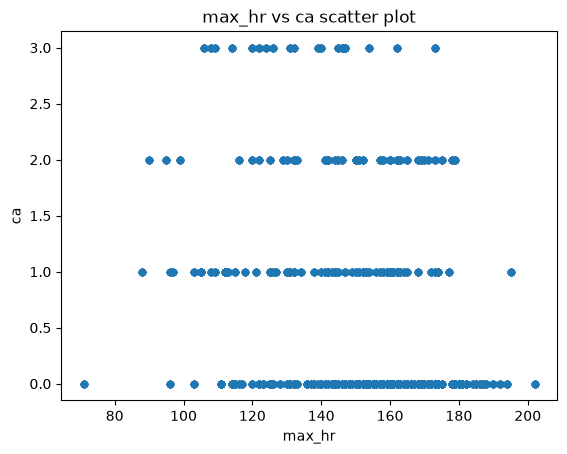

In [897]:
corazon_df.plot(kind="scatter", x="max_hr", y="ca", title="max_hr vs ca scatter plot")

### Categorical vs Categorical Variables

#### sex vs chest_pain

In [898]:
column_1 = "sex"
column_2 = "chest_pain"
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2], margins=True)
    .style.background_gradient(cmap="coolwarm")
    .set_caption(f"{column_1} vs {column_2} Heatmap")
)

chest_pain,asymptomatic,nonanginal,nontypical,typical,All
sex,,,,,
Female,384,341,176,40,941
Male,1008,495,309,184,1996
All,1392,836,485,224,2937


<Axes: title={'center': 'sex vs chest_pain stacked barplot'}, xlabel='sex'>

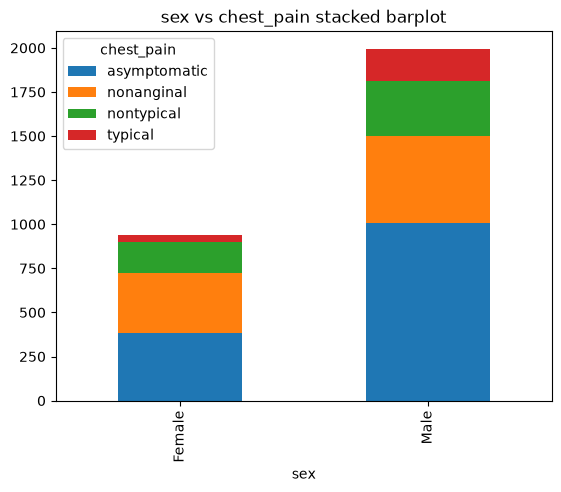

In [899]:
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2]).plot(
        kind="bar", stacked=True, title=f"{column_1} vs {column_2} stacked barplot"
    )
)

<Axes: title={'center': 'sex vs chest_pain barplot'}, xlabel='sex'>

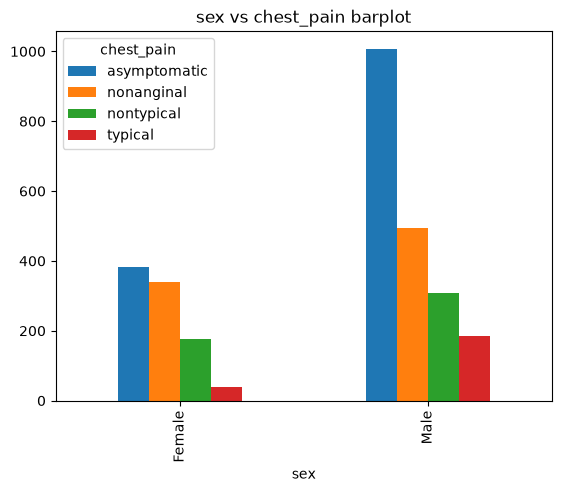

In [900]:
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2]).plot(
        kind="bar", title=f"{column_1} vs {column_2} barplot"
    )
)

#### sex vs rest_ecg

In [901]:
column_1 = "sex"
column_2 = "rest_ecg"
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2], margins=True)
    .style.background_gradient(cmap="coolwarm")
    .set_caption(f"{column_1} vs {column_2} Heatmap")
)

rest_ecg,ST-T wave abnormality,left ventricular hypertrophy,normal,All
sex,,,,
Female,27,425,461,913
Male,9,956,947,1912
All,36,1381,1408,2825


<Axes: title={'center': 'sex vs rest_ecg stacked barplot'}, xlabel='sex'>

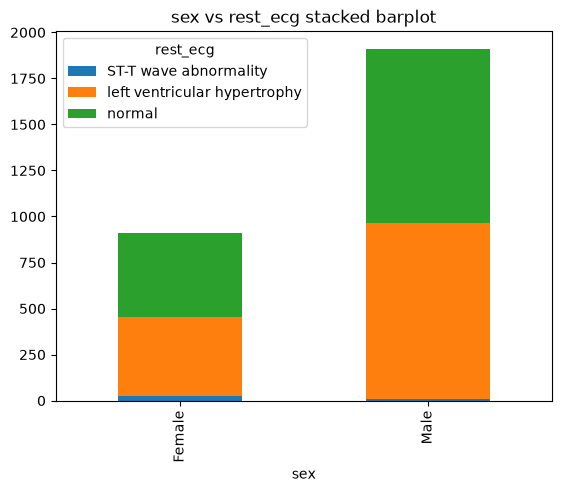

In [902]:
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2]).plot(
        kind="bar", stacked=True, title=f"{column_1} vs {column_2} stacked barplot"
    )
)

<Axes: title={'center': 'sex vs rest_ecg barplot'}, xlabel='sex'>

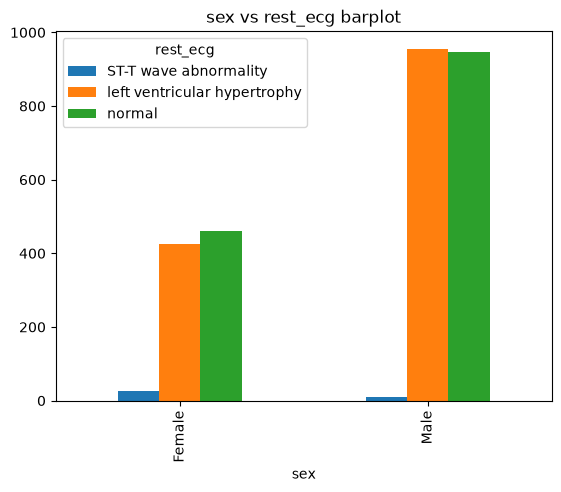

In [903]:
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2]).plot(
        kind="bar", title=f"{column_1} vs {column_2} barplot"
    )
)

#### sex vs slope

In [904]:
column_1 = "sex"
column_2 = "slope"
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2], margins=True)
    .style.background_gradient(cmap="coolwarm")
    .set_caption(f"{column_1} vs {column_2} Heatmap")
)

slope,1,2,3,All
sex,,,,
Female,447,421,50,918
Male,883,878,150,1911
All,1330,1299,200,2829


<Axes: title={'center': 'sex vs slope stacked barplot'}, xlabel='sex'>

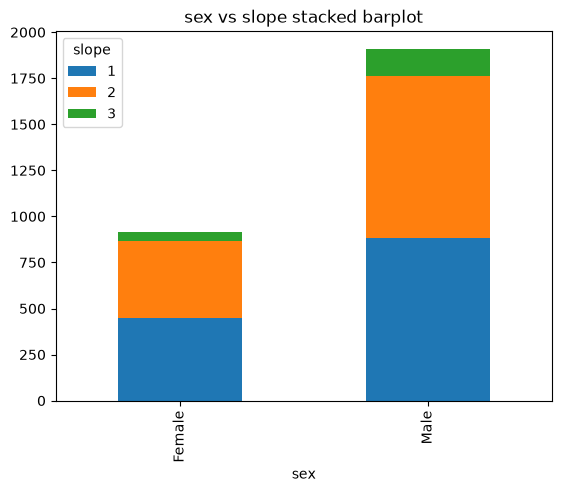

In [905]:
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2]).plot(
        kind="bar", stacked=True, title=f"{column_1} vs {column_2} stacked barplot"
    )
)

<Axes: title={'center': 'sex vs slope barplot'}, xlabel='sex'>

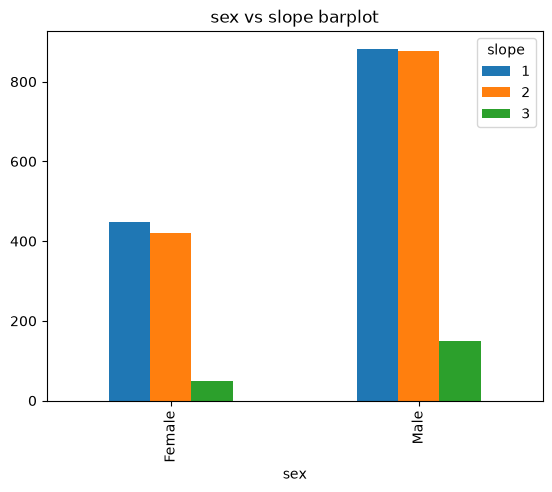

In [906]:
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2]).plot(
        kind="bar", title=f"{column_1} vs {column_2} barplot"
    )
)

#### sex vs thal

In [907]:
column_1 = "sex"
column_2 = "thal"
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2], margins=True)
    .style.background_gradient(cmap="coolwarm")
    .set_caption(f"{column_1} vs {column_2} Heatmap")
)

thal,fixed,normal,reversable,All
sex,,,,
Female,10,764,142,916
Male,161,807,968,1936
All,171,1571,1110,2852


<Axes: title={'center': 'sex vs thal stacked barplot'}, xlabel='sex'>

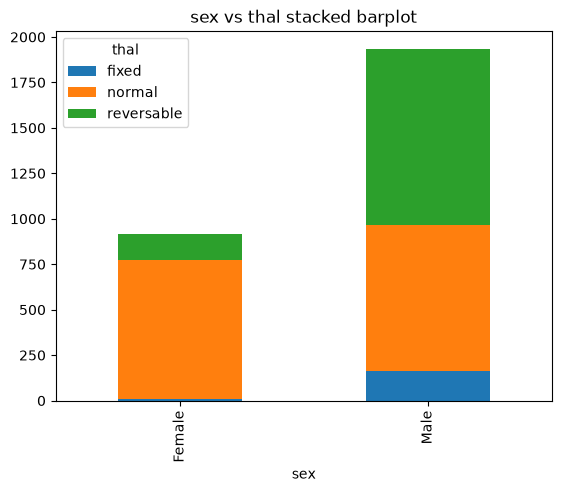

In [908]:
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2]).plot(
        kind="bar", stacked=True, title=f"{column_1} vs {column_2} stacked barplot"
    )
)

<Axes: title={'center': 'sex vs thal barplot'}, xlabel='sex'>

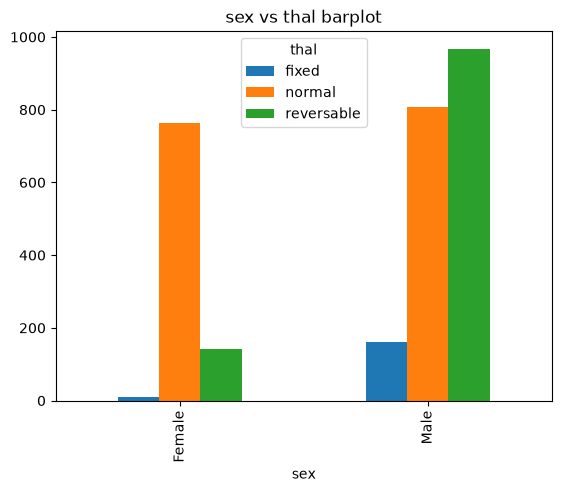

In [909]:
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2]).plot(
        kind="bar", title=f"{column_1} vs {column_2} barplot"
    )
)

#### sex vs fbs

In [910]:
column_1 = "sex"
column_2 = "fbs"
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2], margins=True)
    .style.background_gradient(cmap="coolwarm")
    .set_caption(f"{column_1} vs {column_2} Heatmap")
)

fbs,False,True,All
sex,,,
Female,822,117,939
Male,1670,317,1987
All,2492,434,2926


<Axes: title={'center': 'sex vs fbs stacked barplot'}, xlabel='sex'>

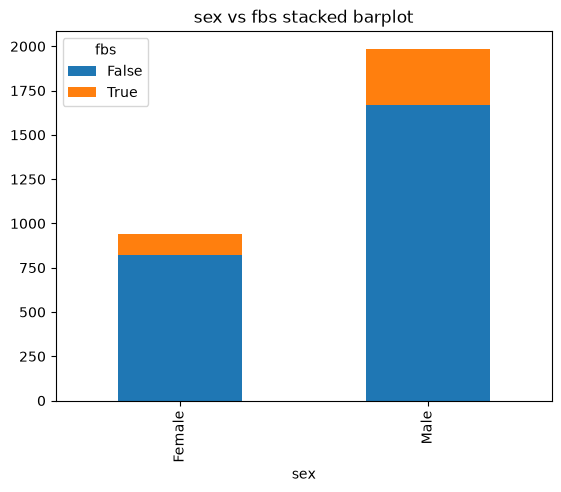

In [911]:
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2]).plot(
        kind="bar", stacked=True, title=f"{column_1} vs {column_2} stacked barplot"
    )
)

<Axes: title={'center': 'sex vs fbs barplot'}, xlabel='sex'>

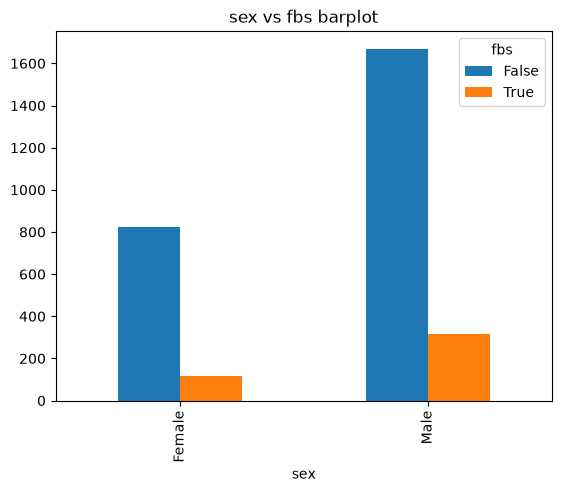

In [912]:
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2]).plot(
        kind="bar", title=f"{column_1} vs {column_2} barplot"
    )
)

#### sex vs exang

In [913]:
column_1 = "sex"
column_2 = "exang"
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2], margins=True)
    .style.background_gradient(cmap="coolwarm")
    .set_caption(f"{column_1} vs {column_2} Heatmap")
)

exang,False,True,All
sex,,,
Female,707,210,917
Male,1189,722,1911
All,1896,932,2828


<Axes: title={'center': 'sex vs exang stacked barplot'}, xlabel='sex'>

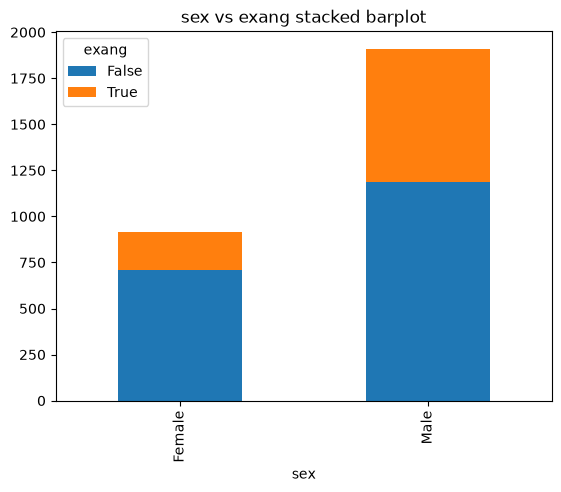

In [914]:
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2]).plot(
        kind="bar", stacked=True, title=f"{column_1} vs {column_2} stacked barplot"
    )
)

<Axes: title={'center': 'sex vs exang barplot'}, xlabel='sex'>

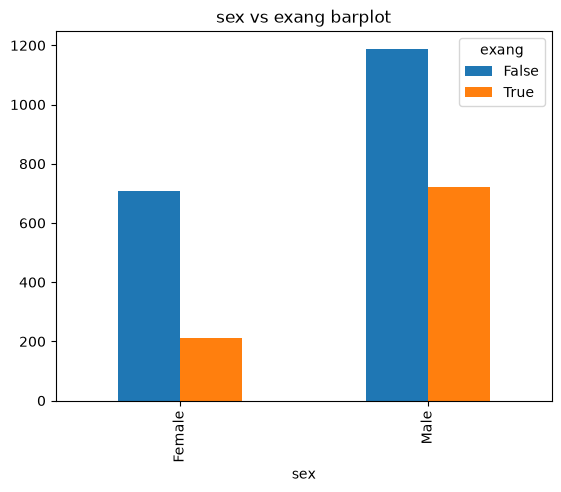

In [915]:
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2]).plot(
        kind="bar", title=f"{column_1} vs {column_2} barplot"
    )
)

#### chest_pain vs rest_ecg

In [916]:
column_1 = "chest_pain"
column_2 = "rest_ecg"
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2], margins=True)
    .style.background_gradient(cmap="coolwarm")
    .set_caption(f"{column_1} vs {column_2} Heatmap")
)

rest_ecg,ST-T wave abnormality,left ventricular hypertrophy,normal,All
chest_pain,,,,
asymptomatic,27,738,580,1345
nonanginal,9,337,456,802
nontypical,0,177,287,464
typical,0,130,84,214
All,36,1382,1407,2825


<Axes: title={'center': 'chest_pain vs rest_ecg stacked barplot'}, xlabel='chest_pain'>

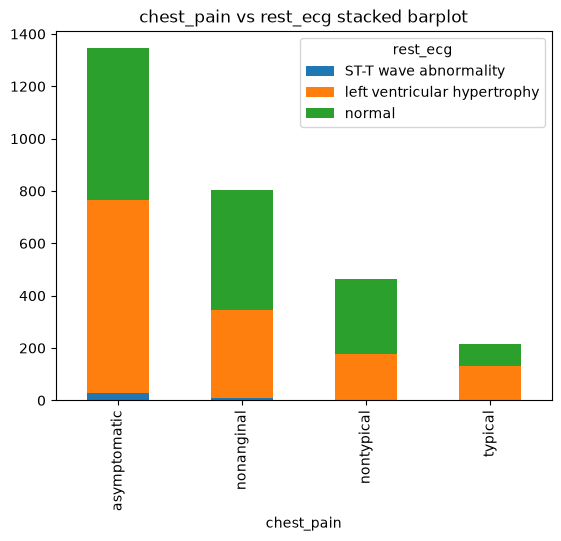

In [917]:
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2]).plot(
        kind="bar", stacked=True, title=f"{column_1} vs {column_2} stacked barplot"
    )
)

<Axes: title={'center': 'chest_pain vs rest_ecg barplot'}, xlabel='chest_pain'>

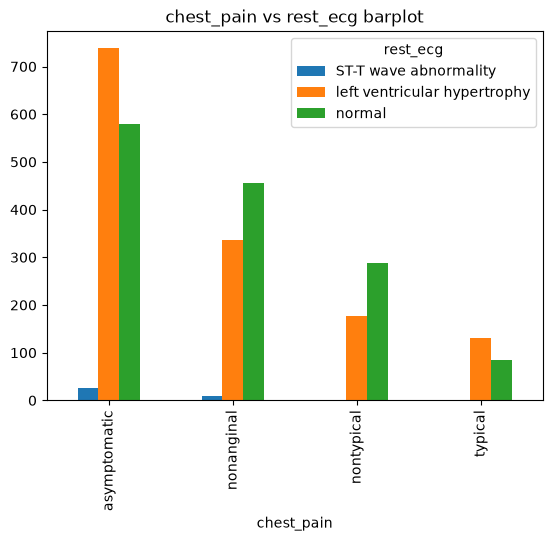

In [918]:
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2]).plot(
        kind="bar", title=f"{column_1} vs {column_2} barplot"
    )
)

#### chest_pain vs slope

In [919]:
column_1 = "chest_pain"
column_2 = "slope"
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2], margins=True)
    .style.background_gradient(cmap="coolwarm")
    .set_caption(f"{column_1} vs {column_2} Heatmap")
)

slope,1,2,3,All
chest_pain,,,,
asymptomatic,458,784,104,1346
nonanginal,447,308,50,805
nontypical,336,111,16,463
typical,87,97,30,214
All,1328,1300,200,2828


<Axes: title={'center': 'chest_pain vs slope stacked barplot'}, xlabel='chest_pain'>

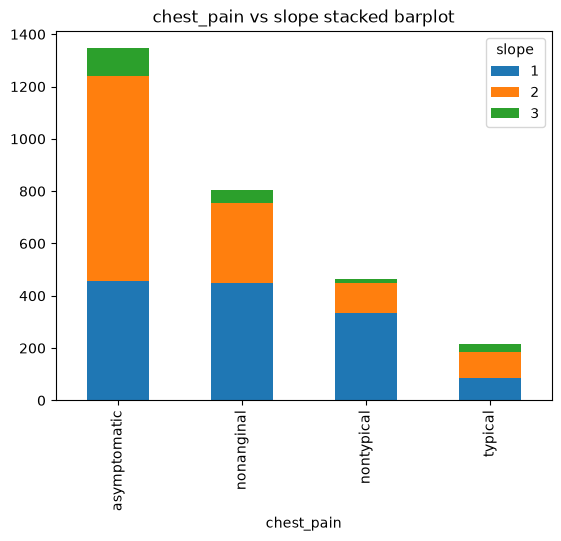

In [920]:
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2]).plot(
        kind="bar", stacked=True, title=f"{column_1} vs {column_2} stacked barplot"
    )
)

<Axes: title={'center': 'chest_pain vs slope barplot'}, xlabel='chest_pain'>

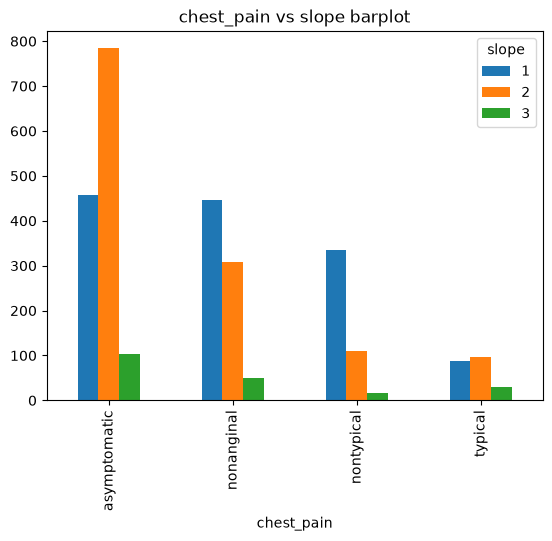

In [921]:
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2]).plot(
        kind="bar", title=f"{column_1} vs {column_2} barplot"
    )
)

#### chest_pain vs thal

In [922]:
column_1 = "chest_pain"
column_2 = "thal"
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2], margins=True)
    .style.background_gradient(cmap="coolwarm")
    .set_caption(f"{column_1} vs {column_2} Heatmap")
)

thal,fixed,normal,reversable,All
chest_pain,,,,
asymptomatic,111,499,736,1346
nonanginal,18,578,207,803
nontypical,19,365,81,465
typical,18,123,74,215
All,166,1565,1098,2829


<Axes: title={'center': 'chest_pain vs thal stacked barplot'}, xlabel='chest_pain'>

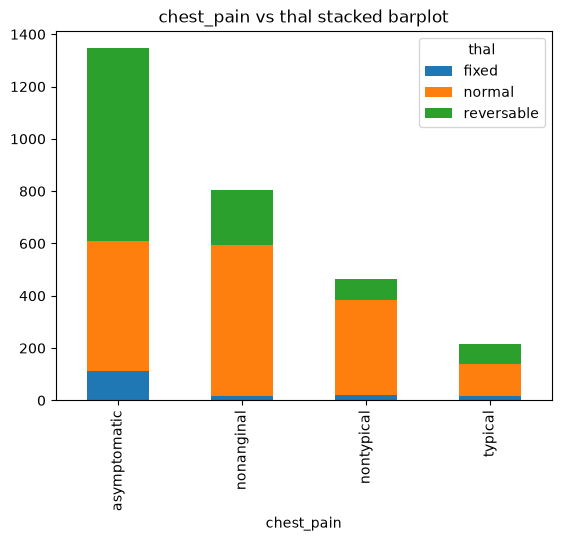

In [923]:
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2]).plot(
        kind="bar", stacked=True, title=f"{column_1} vs {column_2} stacked barplot"
    )
)

<Axes: title={'center': 'chest_pain vs thal barplot'}, xlabel='chest_pain'>

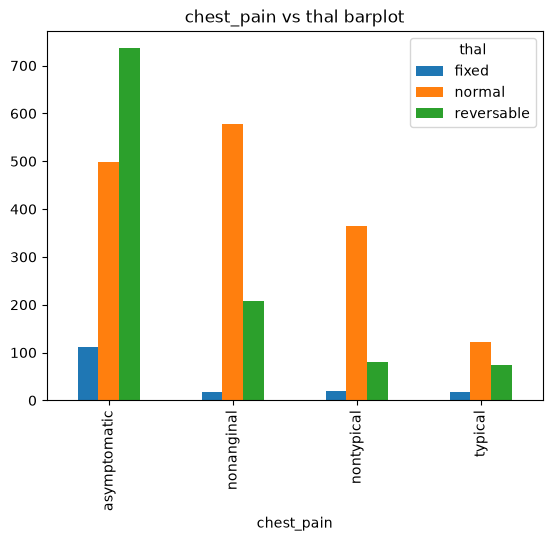

In [924]:
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2]).plot(
        kind="bar", title=f"{column_1} vs {column_2} barplot"
    )
)

#### chest_pain vs fbs

In [925]:
column_1 = "chest_pain"
column_2 = "fbs"
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2], margins=True)
    .style.background_gradient(cmap="coolwarm")
    .set_caption(f"{column_1} vs {column_2} Heatmap")
)

fbs,False,True,All
chest_pain,,,
asymptomatic,1218,168,1386
nonanginal,664,167,831
nontypical,435,50,485
typical,175,48,223
All,2492,433,2925


<Axes: title={'center': 'chest_pain vs fbs stacked barplot'}, xlabel='chest_pain'>

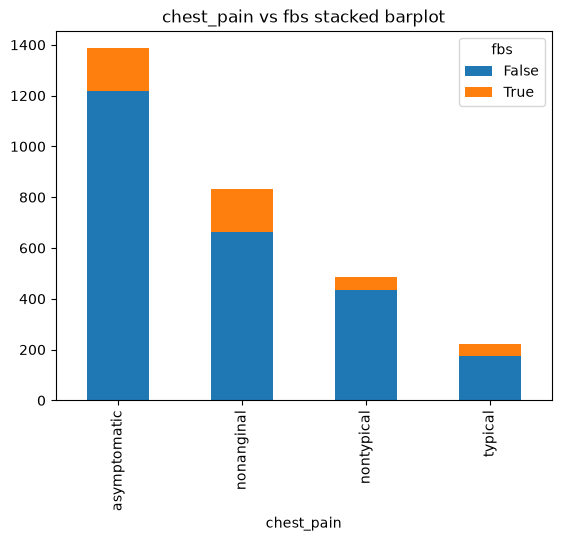

In [926]:
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2]).plot(
        kind="bar", stacked=True, title=f"{column_1} vs {column_2} stacked barplot"
    )
)

<Axes: title={'center': 'chest_pain vs fbs barplot'}, xlabel='chest_pain'>

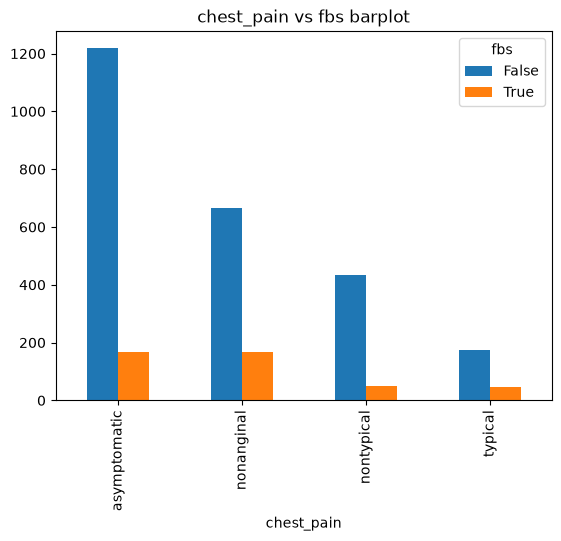

In [927]:
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2]).plot(
        kind="bar", title=f"{column_1} vs {column_2} barplot"
    )
)

#### chest_pain vs exang

In [928]:
column_1 = "chest_pain"
column_2 = "exang"
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2], margins=True)
    .style.background_gradient(cmap="coolwarm")
    .set_caption(f"{column_1} vs {column_2} Heatmap")
)

exang,False,True,All
chest_pain,,,
asymptomatic,597,751,1348
nonanginal,700,102,802
nontypical,424,40,464
typical,177,37,214
All,1898,930,2828


<Axes: title={'center': 'chest_pain vs exang stacked barplot'}, xlabel='chest_pain'>

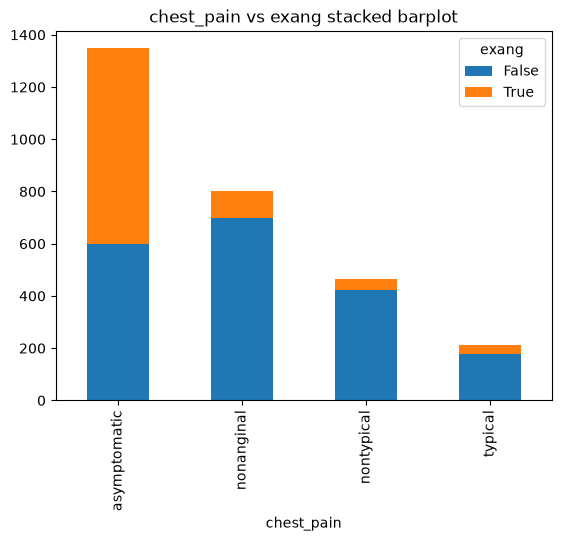

In [929]:
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2]).plot(
        kind="bar", stacked=True, title=f"{column_1} vs {column_2} stacked barplot"
    )
)

<Axes: title={'center': 'chest_pain vs exang barplot'}, xlabel='chest_pain'>

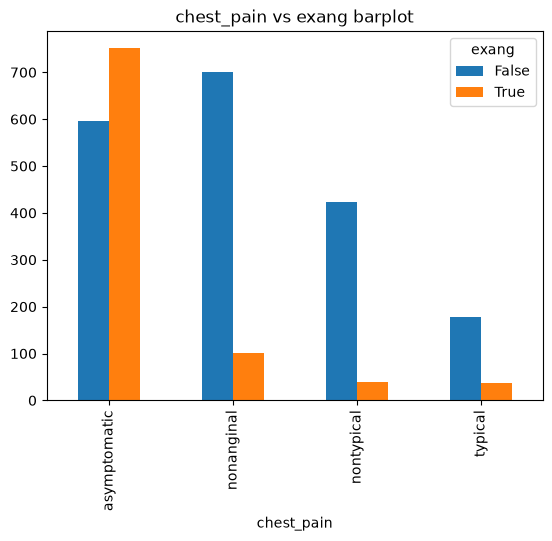

In [930]:
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2]).plot(
        kind="bar", title=f"{column_1} vs {column_2} barplot"
    )
)

#### rest_ecg vs slope

In [931]:
column_1 = "rest_ecg"
column_2 = "slope"
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2], margins=True)
    .style.background_gradient(cmap="coolwarm")
    .set_caption(f"{column_1} vs {column_2} Heatmap")
)

slope,1,2,3,All
rest_ecg,,,,
ST-T wave abnormality,0,27,9,36
left ventricular hypertrophy,566,702,116,1384
normal,764,569,74,1407
All,1330,1298,199,2827


<Axes: title={'center': 'rest_ecg vs slope stacked barplot'}, xlabel='rest_ecg'>

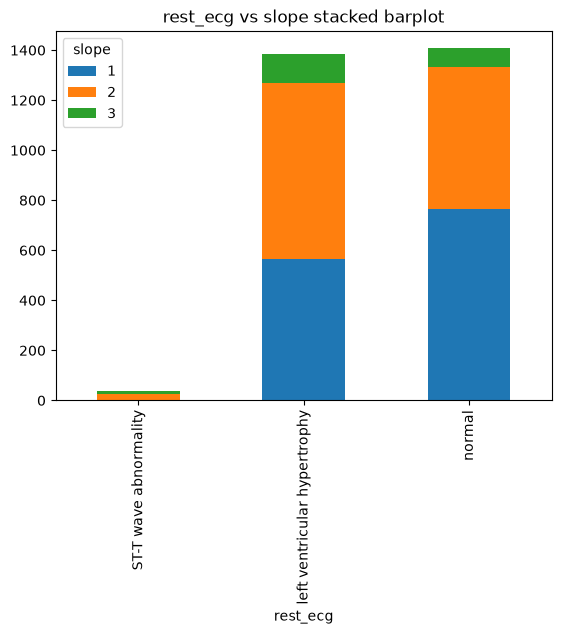

In [932]:
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2]).plot(
        kind="bar", stacked=True, title=f"{column_1} vs {column_2} stacked barplot"
    )
)

<Axes: title={'center': 'rest_ecg vs slope barplot'}, xlabel='rest_ecg'>

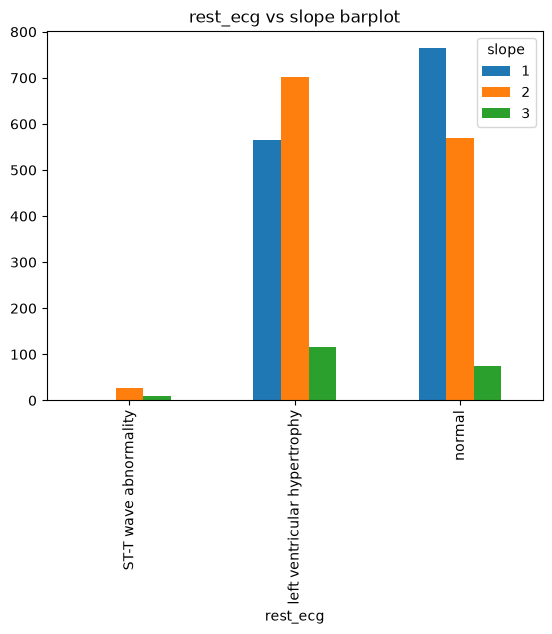

In [933]:
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2]).plot(
        kind="bar", title=f"{column_1} vs {column_2} barplot"
    )
)

#### rest_ecg vs thal

In [934]:
column_1 = "rest_ecg"
column_2 = "thal"
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2], margins=True)
    .style.background_gradient(cmap="coolwarm")
    .set_caption(f"{column_1} vs {column_2} Heatmap")
)

thal,fixed,normal,reversable,All
rest_ecg,,,,
ST-T wave abnormality,9,19,8,36
left ventricular hypertrophy,94,738,540,1372
normal,64,794,540,1398
All,167,1551,1088,2806


<Axes: title={'center': 'rest_ecg vs thal stacked barplot'}, xlabel='rest_ecg'>

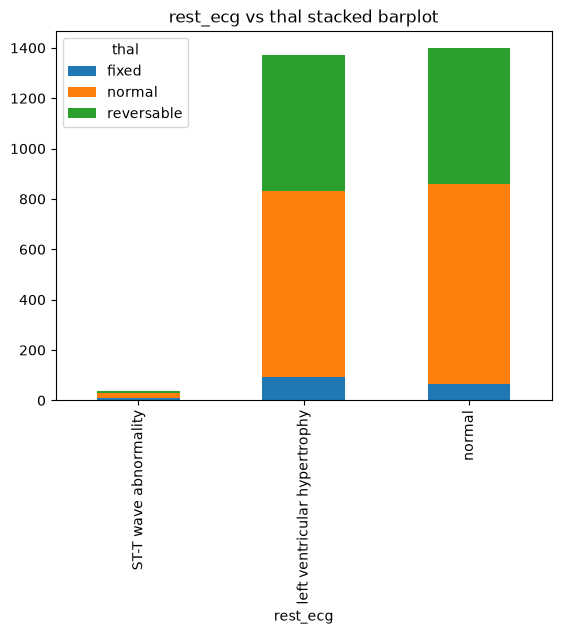

In [935]:
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2]).plot(
        kind="bar", stacked=True, title=f"{column_1} vs {column_2} stacked barplot"
    )
)

<Axes: title={'center': 'rest_ecg vs thal barplot'}, xlabel='rest_ecg'>

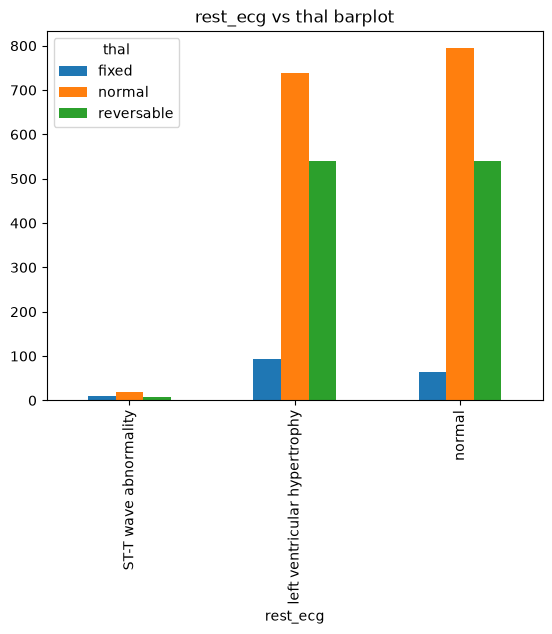

In [936]:
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2]).plot(
        kind="bar", title=f"{column_1} vs {column_2} barplot"
    )
)

#### rest_ecg vs fbs

In [937]:
column_1 = "rest_ecg"
column_2 = "fbs"
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2], margins=True)
    .style.background_gradient(cmap="coolwarm")
    .set_caption(f"{column_1} vs {column_2} Heatmap")
)

fbs,False,True,All
rest_ecg,,,
ST-T wave abnormality,36,0,36
left ventricular hypertrophy,1144,243,1387
normal,1228,178,1406
All,2408,421,2829


<Axes: title={'center': 'rest_ecg vs fbs stacked barplot'}, xlabel='rest_ecg'>

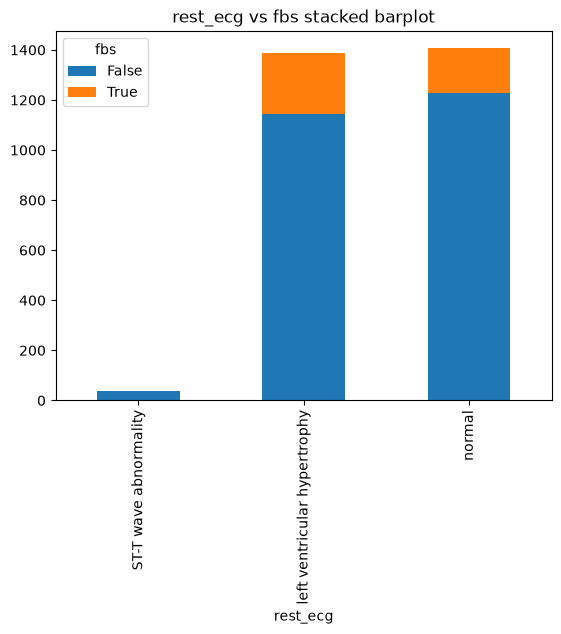

In [938]:
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2]).plot(
        kind="bar", stacked=True, title=f"{column_1} vs {column_2} stacked barplot"
    )
)

<Axes: title={'center': 'rest_ecg vs fbs barplot'}, xlabel='rest_ecg'>

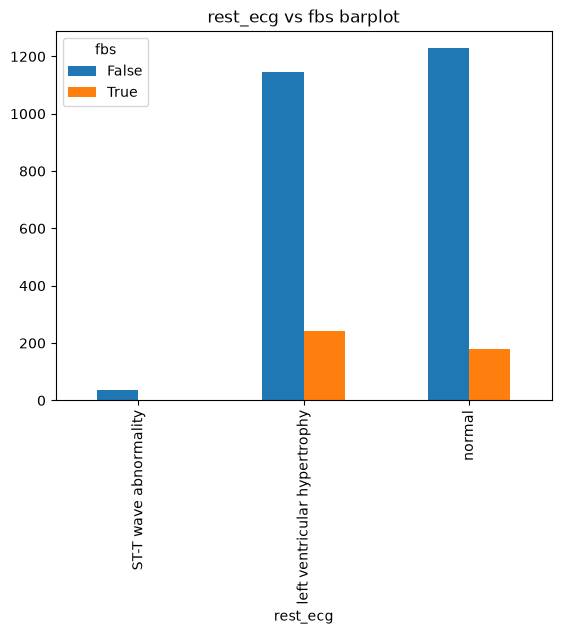

In [939]:
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2]).plot(
        kind="bar", title=f"{column_1} vs {column_2} barplot"
    )
)

#### rest_ecg vs exang

In [940]:
column_1 = "rest_ecg"
column_2 = "exang"
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2], margins=True)
    .style.background_gradient(cmap="coolwarm")
    .set_caption(f"{column_1} vs {column_2} Heatmap")
)

exang,False,True,All
rest_ecg,,,
ST-T wave abnormality,18,18,36
left ventricular hypertrophy,877,505,1382
normal,1001,407,1408
All,1896,930,2826


<Axes: title={'center': 'rest_ecg vs exang stacked barplot'}, xlabel='rest_ecg'>

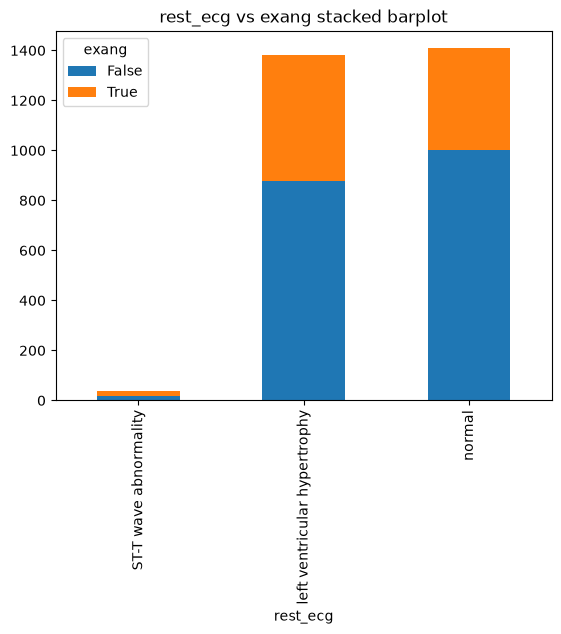

In [941]:
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2]).plot(
        kind="bar", stacked=True, title=f"{column_1} vs {column_2} stacked barplot"
    )
)

<Axes: title={'center': 'rest_ecg vs exang barplot'}, xlabel='rest_ecg'>

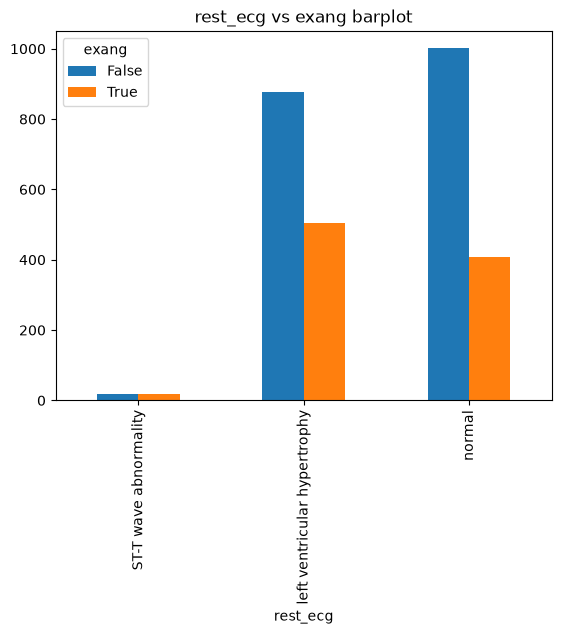

In [942]:
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2]).plot(
        kind="bar", title=f"{column_1} vs {column_2} barplot"
    )
)

#### slope vs thal

In [943]:
column_1 = "slope"
column_2 = "thal"
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2], margins=True)
    .style.background_gradient(cmap="coolwarm")
    .set_caption(f"{column_1} vs {column_2} Heatmap")
)

thal,fixed,normal,reversable,All
slope,,,,
1,19,974,346,1339
2,121,529,661,1311
3,28,77,97,202
All,168,1580,1104,2852


<Axes: title={'center': 'slope vs thal stacked barplot'}, xlabel='slope'>

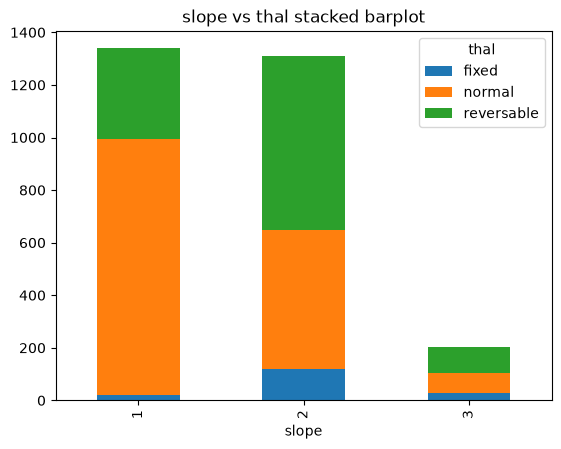

In [944]:
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2]).plot(
        kind="bar", stacked=True, title=f"{column_1} vs {column_2} stacked barplot"
    )
)

<Axes: title={'center': 'slope vs thal barplot'}, xlabel='slope'>

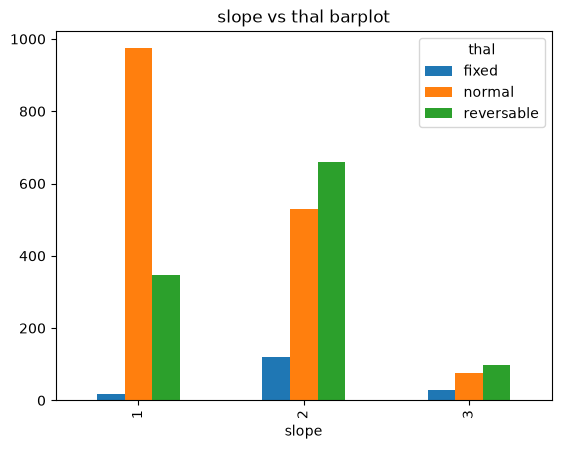

In [945]:
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2]).plot(
        kind="bar", title=f"{column_1} vs {column_2} barplot"
    )
)

#### slope vs fbs

In [946]:
column_1 = "slope"
column_2 = "fbs"
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2], margins=True)
    .style.background_gradient(cmap="coolwarm")
    .set_caption(f"{column_1} vs {column_2} Heatmap")
)

fbs,False,True,All
slope,,,
1,1142,189,1331
2,1127,173,1300
3,141,60,201
All,2410,422,2832


<Axes: title={'center': 'slope vs fbs stacked barplot'}, xlabel='slope'>

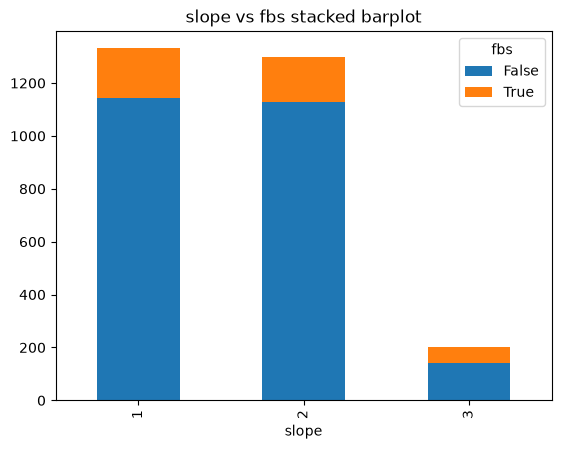

In [947]:
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2]).plot(
        kind="bar", stacked=True, title=f"{column_1} vs {column_2} stacked barplot"
    )
)

<Axes: title={'center': 'slope vs fbs barplot'}, xlabel='slope'>

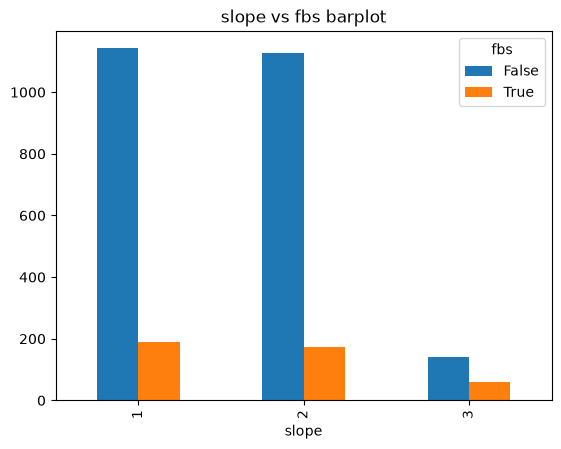

In [948]:
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2]).plot(
        kind="bar", title=f"{column_1} vs {column_2} barplot"
    )
)

#### slope vs exang

In [949]:
column_1 = "slope"
column_2 = "exang"
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2], margins=True)
    .style.background_gradient(cmap="coolwarm")
    .set_caption(f"{column_1} vs {column_2} Heatmap")
)

exang,False,True,All
slope,,,
1,1099,252,1351
2,713,608,1321
3,115,86,201
All,1927,946,2873


<Axes: title={'center': 'slope vs exang stacked barplot'}, xlabel='slope'>

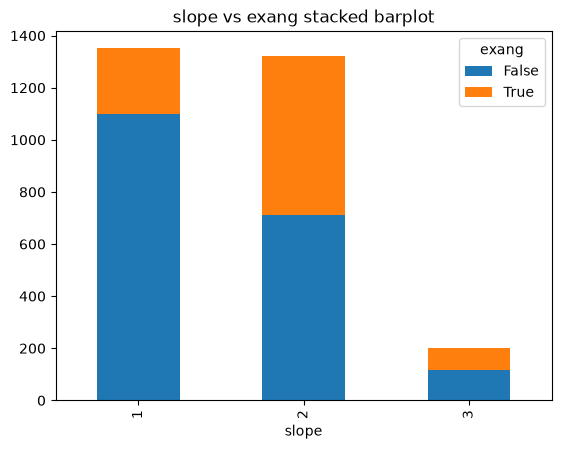

In [950]:
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2]).plot(
        kind="bar", stacked=True, title=f"{column_1} vs {column_2} stacked barplot"
    )
)

<Axes: title={'center': 'slope vs exang barplot'}, xlabel='slope'>

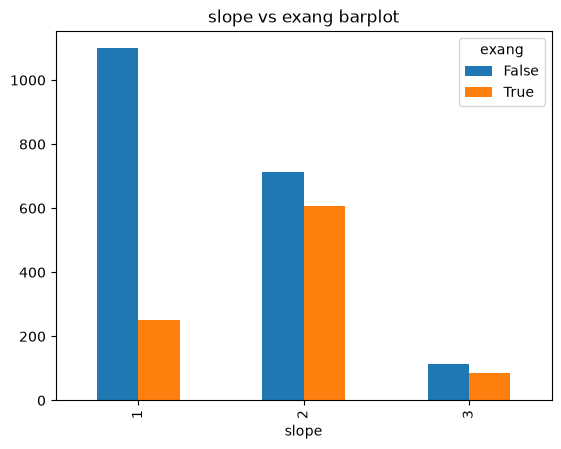

In [951]:
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2]).plot(
        kind="bar", title=f"{column_1} vs {column_2} barplot"
    )
)

#### thal vs fbs

In [952]:
column_1 = "thal"
column_2 = "fbs"
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2], margins=True)
    .style.background_gradient(cmap="coolwarm")
    .set_caption(f"{column_1} vs {column_2} Heatmap")
)

fbs,False,True,All
thal,,,
fixed,121,46,167
normal,1368,191,1559
reversable,916,176,1092
All,2405,413,2818


<Axes: title={'center': 'thal vs fbs stacked barplot'}, xlabel='thal'>

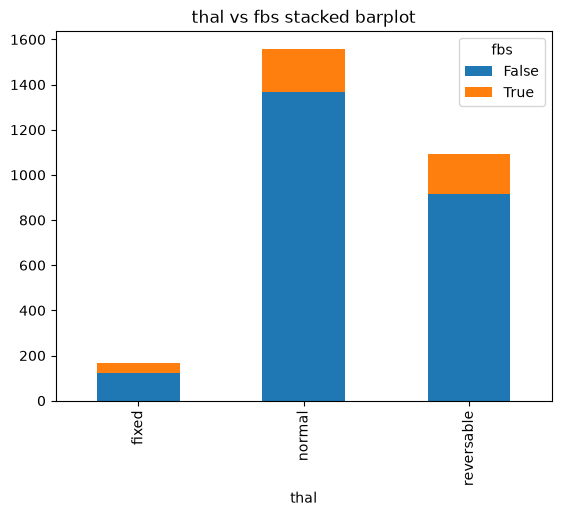

In [953]:
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2]).plot(
        kind="bar", stacked=True, title=f"{column_1} vs {column_2} stacked barplot"
    )
)

<Axes: title={'center': 'thal vs fbs barplot'}, xlabel='thal'>

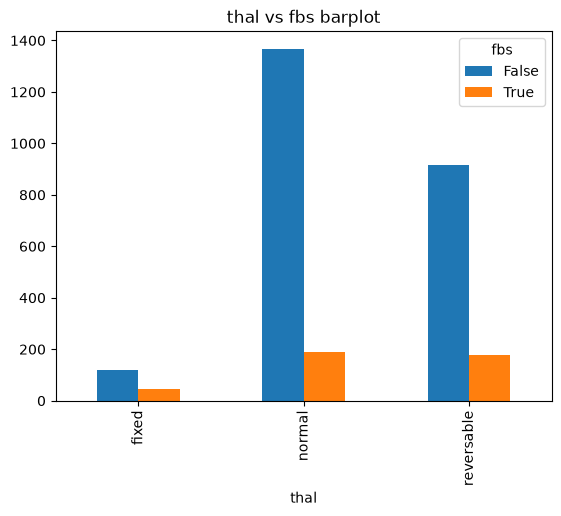

In [954]:
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2]).plot(
        kind="bar", title=f"{column_1} vs {column_2} barplot"
    )
)

#### thal vs exang

In [955]:
column_1 = "thal"
column_2 = "exang"
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2], margins=True)
    .style.background_gradient(cmap="coolwarm")
    .set_caption(f"{column_1} vs {column_2} Heatmap")
)

exang,False,True,All
thal,,,
fixed,93,75,168
normal,1279,299,1578
reversable,541,564,1105
All,1913,938,2851


<Axes: title={'center': 'thal vs exang stacked barplot'}, xlabel='thal'>

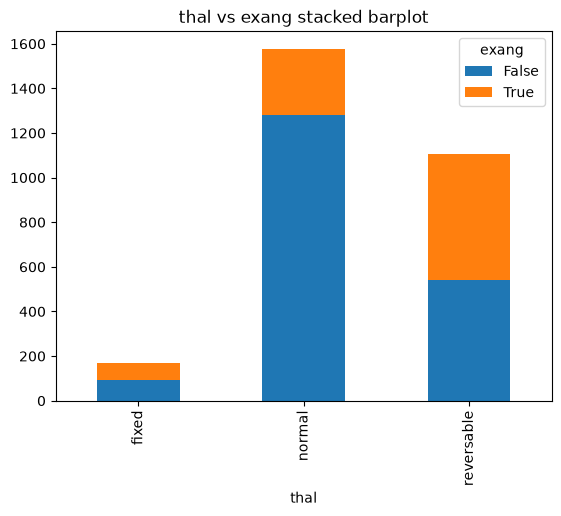

In [956]:
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2]).plot(
        kind="bar", stacked=True, title=f"{column_1} vs {column_2} stacked barplot"
    )
)

<Axes: title={'center': 'thal vs exang barplot'}, xlabel='thal'>

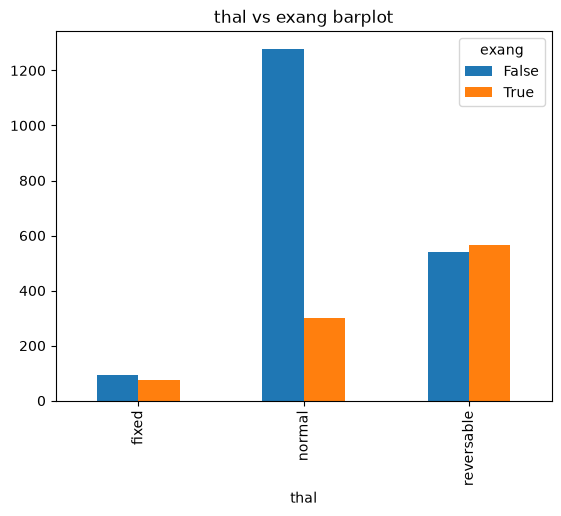

In [957]:
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2]).plot(
        kind="bar", title=f"{column_1} vs {column_2} barplot"
    )
)

#### fbs vs exang

In [958]:
column_1 = "fbs"
column_2 = "exang"
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2], margins=True)
    .style.background_gradient(cmap="coolwarm")
    .set_caption(f"{column_1} vs {column_2} Heatmap")
)

exang,False,True,All
fbs,,,
False,1627,782,2409
True,272,150,422
All,1899,932,2831


<Axes: title={'center': 'fbs vs exang stacked barplot'}, xlabel='fbs'>

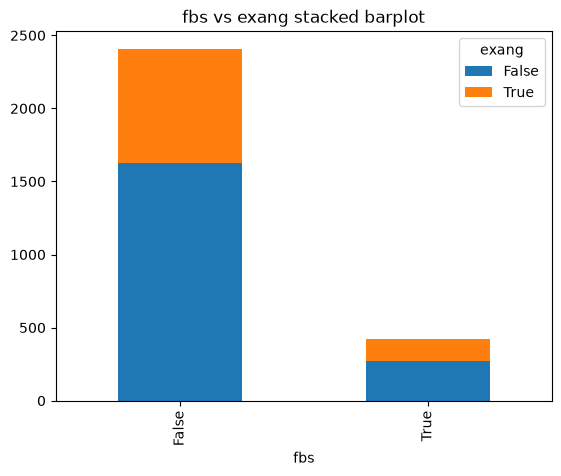

In [959]:
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2]).plot(
        kind="bar", stacked=True, title=f"{column_1} vs {column_2} stacked barplot"
    )
)

<Axes: title={'center': 'fbs vs exang barplot'}, xlabel='fbs'>

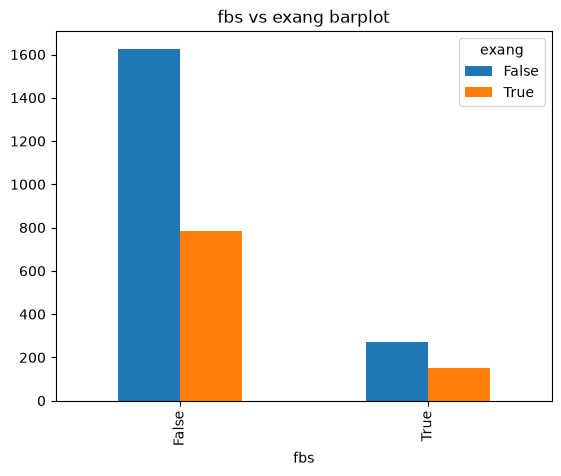

In [960]:
(
    pd.crosstab(corazon_df[column_1], corazon_df[column_2]).plot(
        kind="bar", title=f"{column_1} vs {column_2} barplot"
    )
)

### Categorical vs Numerical Variables

#### sex vs age

age    Axes(0.125,0.11;0.775x0.77)
dtype: object

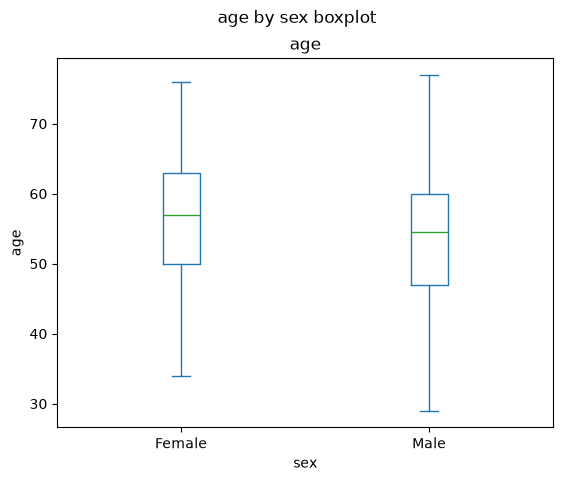

In [961]:
column_cat = "sex"
column_num = "age"
corazon_df.plot(
    kind="box",
    column=column_num,
    by=column_cat,
    xlabel=column_cat,
    ylabel=column_num,
    title=f"{column_num} by {column_cat} boxplot",
    grid=False,
)

Text(0.5, 1.0, 'age by sex barplot')

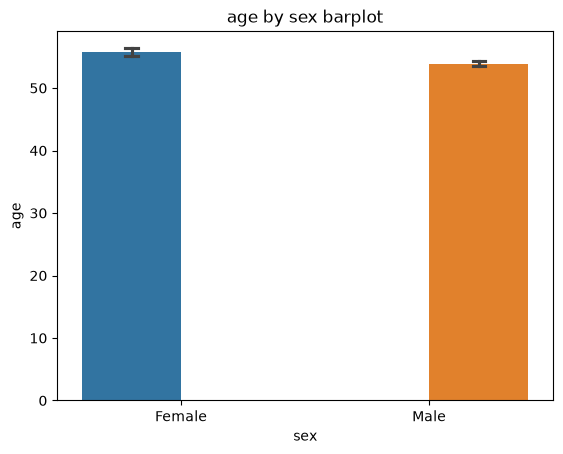

In [962]:
sns.barplot(
    data=corazon_df.dropna(subset=[column_cat, column_num]),
    x=column_cat,
    y=column_num,
    errorbar="ci",
    capsize=0.1,
    hue=column_cat,
).set_title(f"{column_num} by {column_cat} barplot")

#### sex vs rest_bp

rest_bp    Axes(0.125,0.11;0.775x0.77)
dtype: object

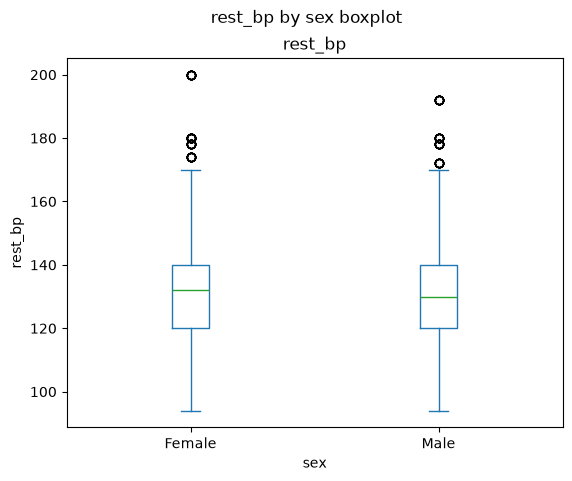

In [963]:
column_cat = "sex"
column_num = "rest_bp"
corazon_df.plot(
    kind="box",
    column=column_num,
    by=column_cat,
    xlabel=column_cat,
    ylabel=column_num,
    title=f"{column_num} by {column_cat} boxplot",
    grid=False,
)

Text(0.5, 1.0, 'rest_bp by sex barplot')

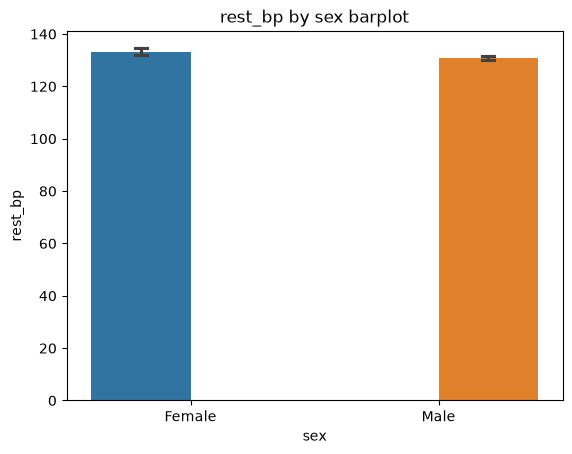

In [964]:
sns.barplot(
    data=corazon_df.dropna(subset=[column_cat, column_num]),
    x=column_cat,
    y=column_num,
    errorbar="ci",
    capsize=0.1,
    hue=column_cat,
).set_title(f"{column_num} by {column_cat} barplot")

#### sex vs chol

chol    Axes(0.125,0.11;0.775x0.77)
dtype: object

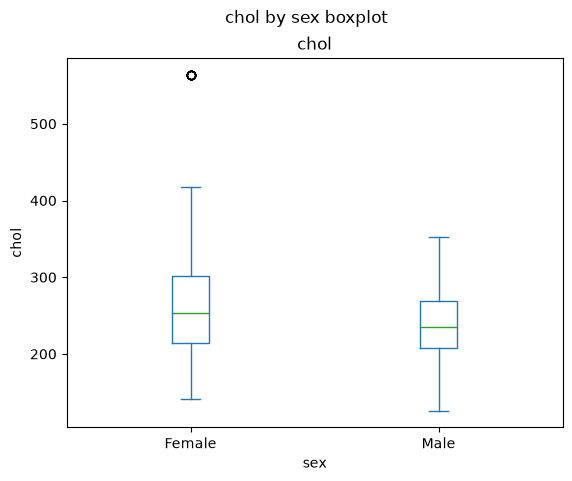

In [965]:
column_cat = "sex"
column_num = "chol"
corazon_df.plot(
    kind="box",
    column=column_num,
    by=column_cat,
    xlabel=column_cat,
    ylabel=column_num,
    title=f"{column_num} by {column_cat} boxplot",
    grid=False,
)

Text(0.5, 1.0, 'chol by sex barplot')

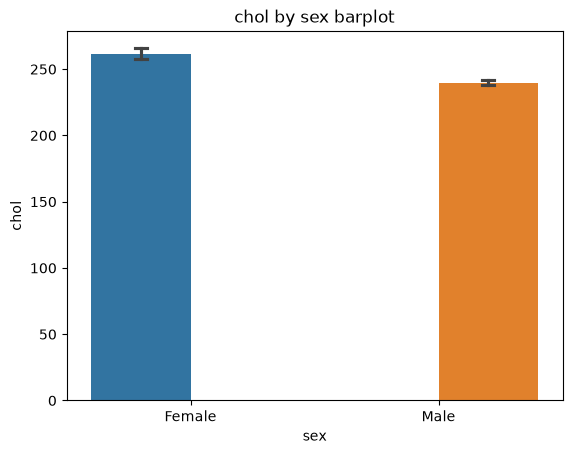

In [966]:
sns.barplot(
    data=corazon_df.dropna(subset=[column_cat, column_num]),
    x=column_cat,
    y=column_num,
    errorbar="ci",
    capsize=0.1,
    hue=column_cat,
).set_title(f"{column_num} by {column_cat} barplot")

#### sex vs old_peak

old_peak    Axes(0.125,0.11;0.775x0.77)
dtype: object

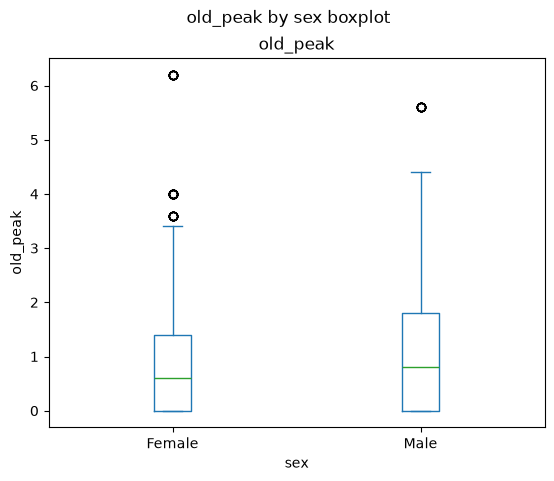

In [967]:
column_cat = "sex"
column_num = "old_peak"
corazon_df.plot(
    kind="box",
    column=column_num,
    by=column_cat,
    xlabel=column_cat,
    ylabel=column_num,
    title=f"{column_num} by {column_cat} boxplot",
    grid=False,
)

Text(0.5, 1.0, 'old_peak by sex barplot')

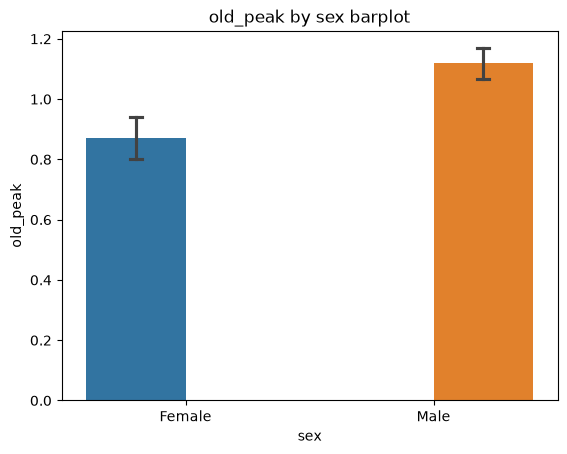

In [968]:
sns.barplot(
    data=corazon_df.dropna(subset=[column_cat, column_num]),
    x=column_cat,
    y=column_num,
    errorbar="ci",
    capsize=0.1,
    hue=column_cat,
).set_title(f"{column_num} by {column_cat} barplot")

#### sex vs max_hr

max_hr    Axes(0.125,0.11;0.775x0.77)
dtype: object

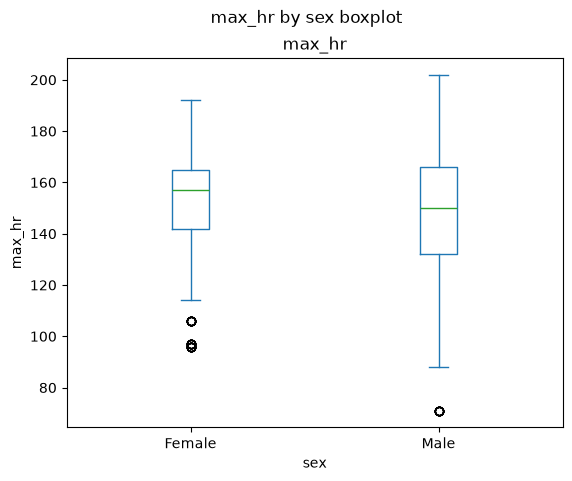

In [969]:
column_cat = "sex"
column_num = "max_hr"
corazon_df.plot(
    kind="box",
    column=column_num,
    by=column_cat,
    xlabel=column_cat,
    ylabel=column_num,
    title=f"{column_num} by {column_cat} boxplot",
    grid=False,
)

Text(0.5, 1.0, 'max_hr by sex barplot')

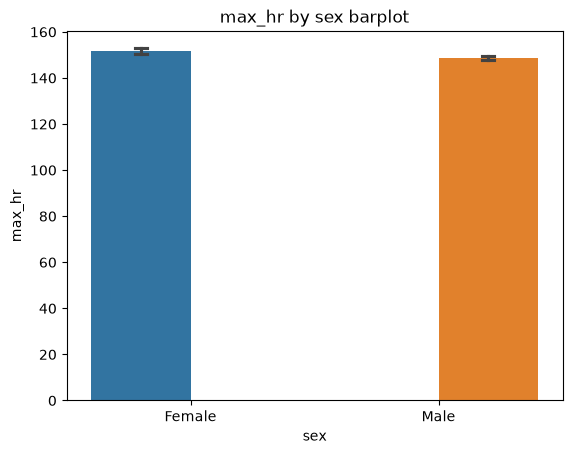

In [970]:
sns.barplot(
    data=corazon_df.dropna(subset=[column_cat, column_num]),
    x=column_cat,
    y=column_num,
    errorbar="ci",
    capsize=0.1,
    hue=column_cat,
).set_title(f"{column_num} by {column_cat} barplot")

#### sex vs ca

ca    Axes(0.125,0.11;0.775x0.77)
dtype: object

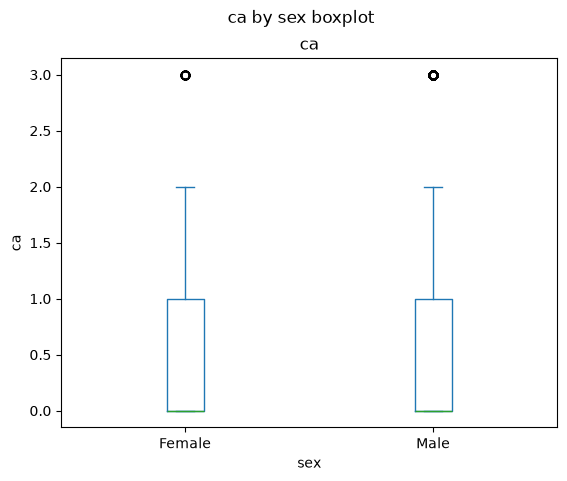

In [971]:
column_cat = "sex"
column_num = "ca"
corazon_df.plot(
    kind="box",
    column=column_num,
    by=column_cat,
    xlabel=column_cat,
    ylabel=column_num,
    title=f"{column_num} by {column_cat} boxplot",
    grid=False,
)

Text(0.5, 1.0, 'ca by sex barplot')

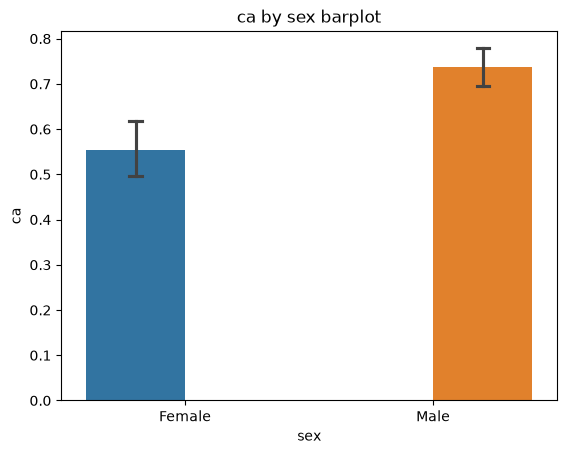

In [972]:
sns.barplot(
    data=corazon_df.dropna(subset=[column_cat, column_num]),
    x=column_cat,
    y=column_num,
    errorbar="ci",
    capsize=0.1,
    hue=column_cat,
).set_title(f"{column_num} by {column_cat} barplot")

#### chest_pain vs age

age    Axes(0.125,0.11;0.775x0.77)
dtype: object

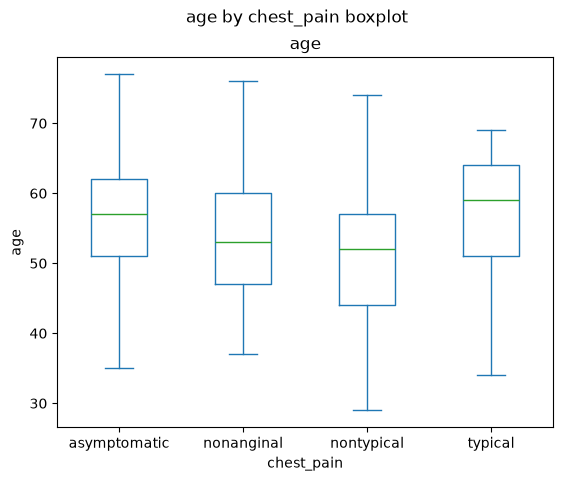

In [973]:
column_cat = "chest_pain"
column_num = "age"
corazon_df.plot(
    kind="box",
    column=column_num,
    by=column_cat,
    xlabel=column_cat,
    ylabel=column_num,
    title=f"{column_num} by {column_cat} boxplot",
    grid=False,
)

Text(0.5, 1.0, 'age by chest_pain barplot')

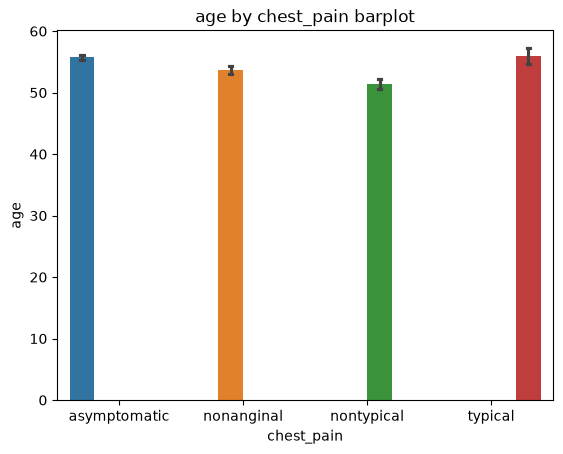

In [974]:
sns.barplot(
    data=corazon_df.dropna(subset=[column_cat, column_num]),
    x=column_cat,
    y=column_num,
    errorbar="ci",
    capsize=0.1,
    hue=column_cat,
).set_title(f"{column_num} by {column_cat} barplot")

#### chest_pain vs rest_bp

rest_bp    Axes(0.125,0.11;0.775x0.77)
dtype: object

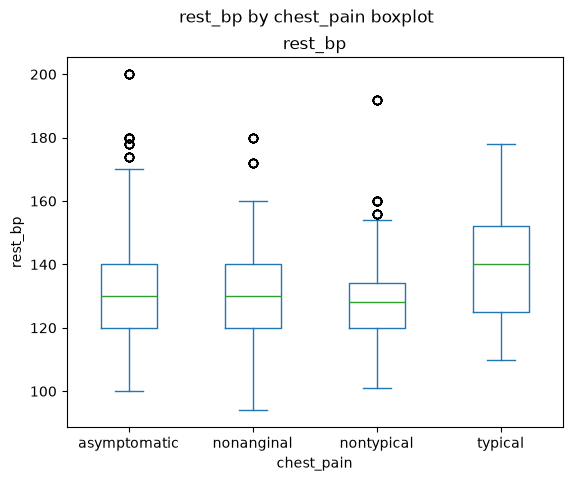

In [975]:
column_cat = "chest_pain"
column_num = "rest_bp"
corazon_df.plot(
    kind="box",
    column=column_num,
    by=column_cat,
    xlabel=column_cat,
    ylabel=column_num,
    title=f"{column_num} by {column_cat} boxplot",
    grid=False,
)

Text(0.5, 1.0, 'rest_bp by chest_pain barplot')

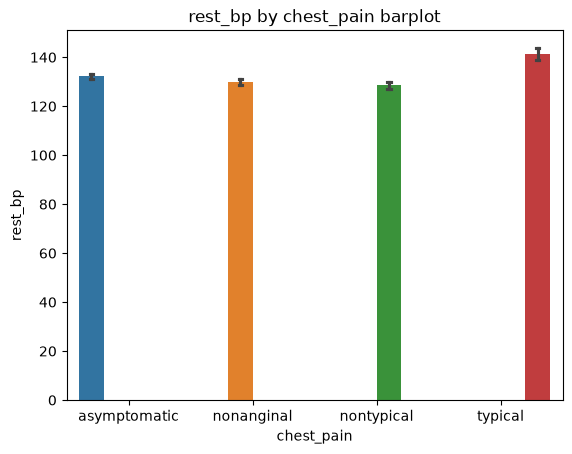

In [976]:
sns.barplot(
    data=corazon_df.dropna(subset=[column_cat, column_num]),
    x=column_cat,
    y=column_num,
    errorbar="ci",
    capsize=0.1,
    hue=column_cat,
).set_title(f"{column_num} by {column_cat} barplot")

#### chest_pain vs chol

chol    Axes(0.125,0.11;0.775x0.77)
dtype: object

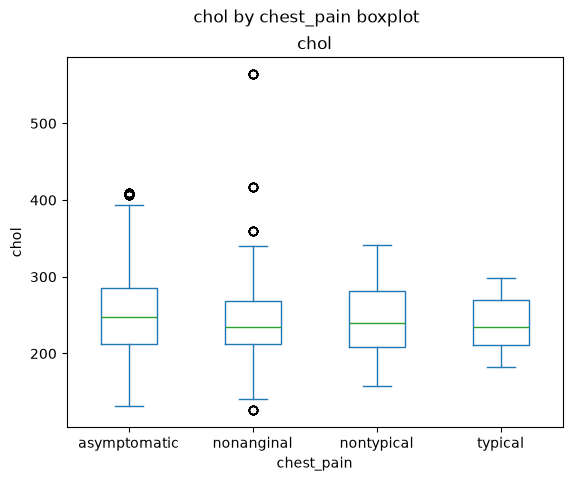

In [977]:
column_cat = "chest_pain"
column_num = "chol"
corazon_df.plot(
    kind="box",
    column=column_num,
    by=column_cat,
    xlabel=column_cat,
    ylabel=column_num,
    title=f"{column_num} by {column_cat} boxplot",
    grid=False,
)

Text(0.5, 1.0, 'chol by chest_pain barplot')

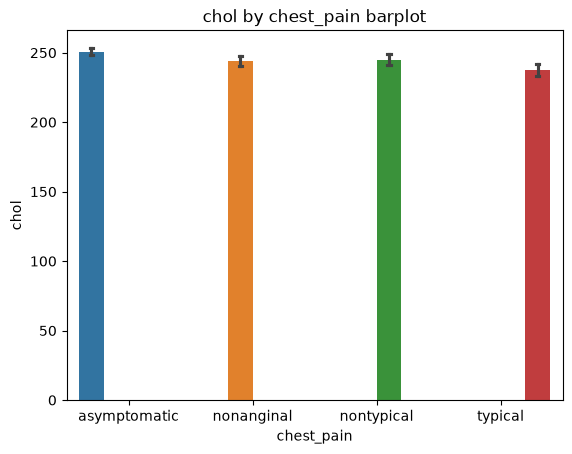

In [978]:
sns.barplot(
    data=corazon_df.dropna(subset=[column_cat, column_num]),
    x=column_cat,
    y=column_num,
    errorbar="ci",
    capsize=0.1,
    hue=column_cat,
).set_title(f"{column_num} by {column_cat} barplot")

#### chest_pain vs old_peak

old_peak    Axes(0.125,0.11;0.775x0.77)
dtype: object

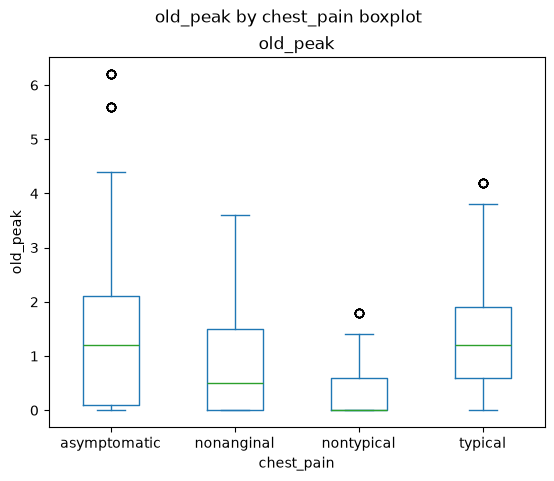

In [979]:
column_cat = "chest_pain"
column_num = "old_peak"
corazon_df.plot(
    kind="box",
    column=column_num,
    by=column_cat,
    xlabel=column_cat,
    ylabel=column_num,
    title=f"{column_num} by {column_cat} boxplot",
    grid=False,
)

Text(0.5, 1.0, 'old_peak by chest_pain barplot')

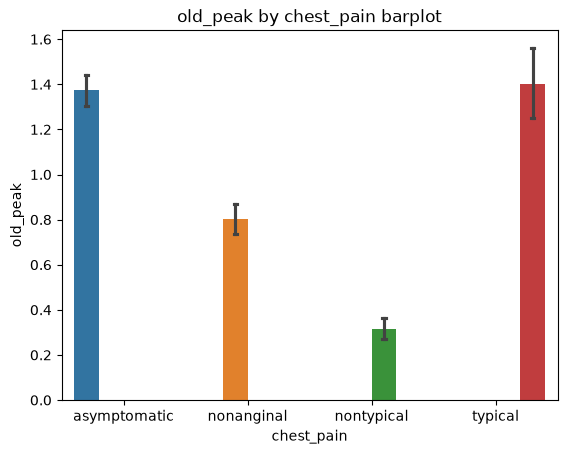

In [980]:
sns.barplot(
    data=corazon_df.dropna(subset=[column_cat, column_num]),
    x=column_cat,
    y=column_num,
    errorbar="ci",
    capsize=0.1,
    hue=column_cat,
).set_title(f"{column_num} by {column_cat} barplot")

#### chest_pain vs max_hr

max_hr    Axes(0.125,0.11;0.775x0.77)
dtype: object

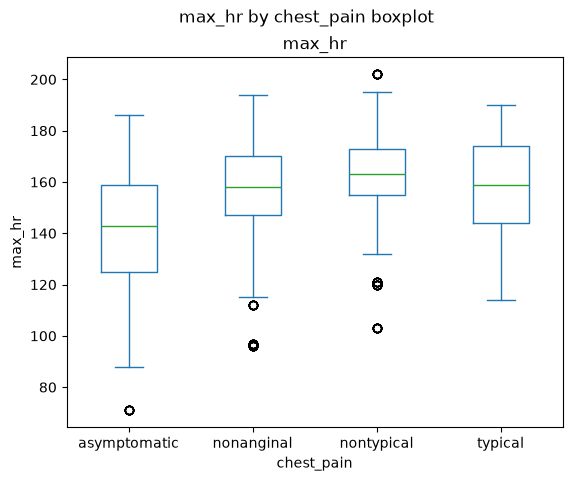

In [981]:
column_cat = "chest_pain"
column_num = "max_hr"
corazon_df.plot(
    kind="box",
    column=column_num,
    by=column_cat,
    xlabel=column_cat,
    ylabel=column_num,
    title=f"{column_num} by {column_cat} boxplot",
    grid=False,
)

Text(0.5, 1.0, 'max_hr by chest_pain barplot')

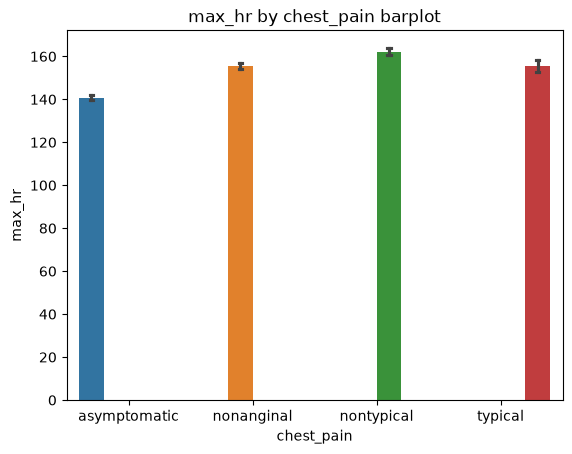

In [982]:
sns.barplot(
    data=corazon_df.dropna(subset=[column_cat, column_num]),
    x=column_cat,
    y=column_num,
    errorbar="ci",
    capsize=0.1,
    hue=column_cat,
).set_title(f"{column_num} by {column_cat} barplot")

#### chest_pain vs ca

ca    Axes(0.125,0.11;0.775x0.77)
dtype: object

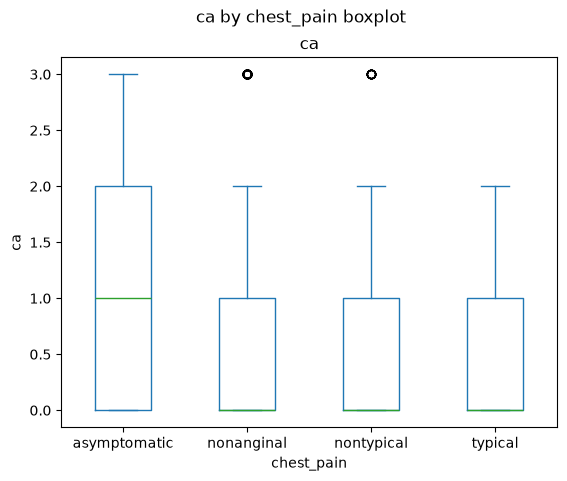

In [983]:
column_cat = "chest_pain"
column_num = "ca"
corazon_df.plot(
    kind="box",
    column=column_num,
    by=column_cat,
    xlabel=column_cat,
    ylabel=column_num,
    title=f"{column_num} by {column_cat} boxplot",
    grid=False,
)

Text(0.5, 1.0, 'ca by chest_pain barplot')

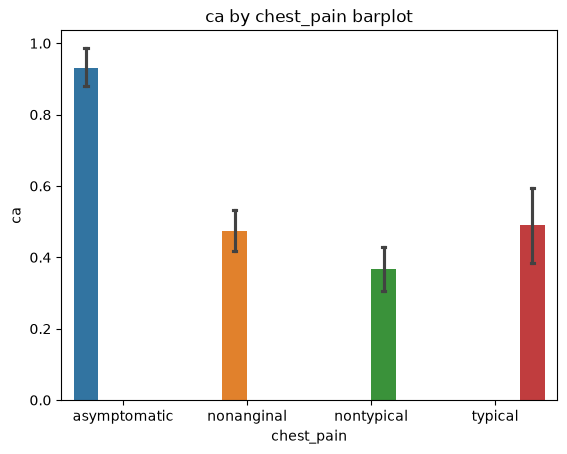

In [984]:
sns.barplot(
    data=corazon_df.dropna(subset=[column_cat, column_num]),
    x=column_cat,
    y=column_num,
    errorbar="ci",
    capsize=0.1,
    hue=column_cat,
).set_title(f"{column_num} by {column_cat} barplot")

#### rest_ecg vs age

age    Axes(0.125,0.11;0.775x0.77)
dtype: object

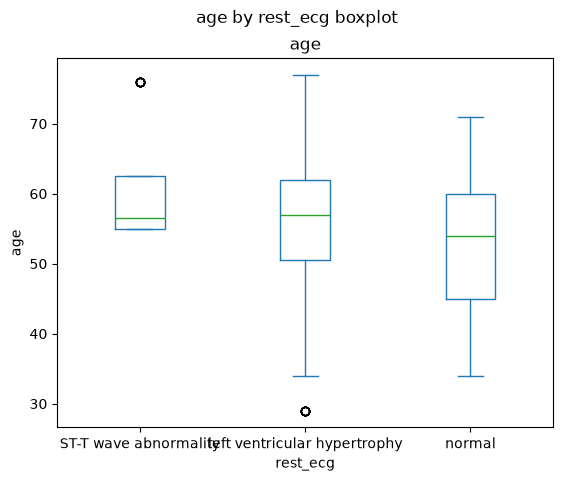

In [985]:
column_cat = "rest_ecg"
column_num = "age"
corazon_df.plot(
    kind="box",
    column=column_num,
    by=column_cat,
    xlabel=column_cat,
    ylabel=column_num,
    title=f"{column_num} by {column_cat} boxplot",
    grid=False,
)

Text(0.5, 1.0, 'age by rest_ecg barplot')

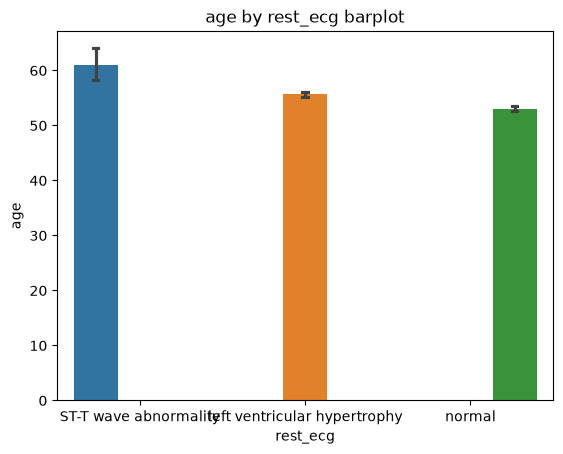

In [986]:
sns.barplot(
    data=corazon_df.dropna(subset=[column_cat, column_num]),
    x=column_cat,
    y=column_num,
    errorbar="ci",
    capsize=0.1,
    hue=column_cat,
).set_title(f"{column_num} by {column_cat} barplot")

#### rest_ecg vs rest_bp

rest_bp    Axes(0.125,0.11;0.775x0.77)
dtype: object

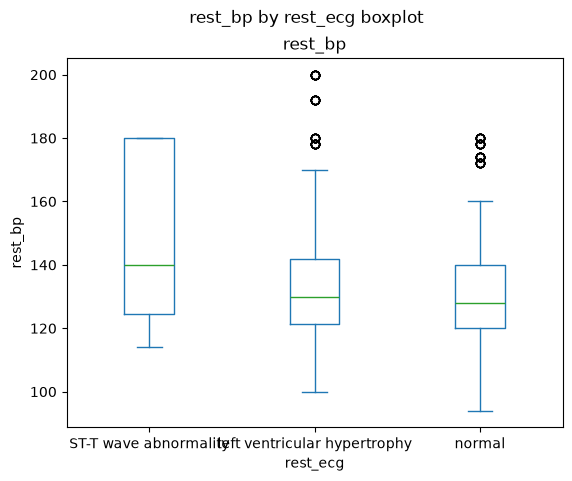

In [987]:
column_cat = "rest_ecg"
column_num = "rest_bp"
corazon_df.plot(
    kind="box",
    column=column_num,
    by=column_cat,
    xlabel=column_cat,
    ylabel=column_num,
    title=f"{column_num} by {column_cat} boxplot",
    grid=False,
)

Text(0.5, 1.0, 'rest_bp by rest_ecg barplot')

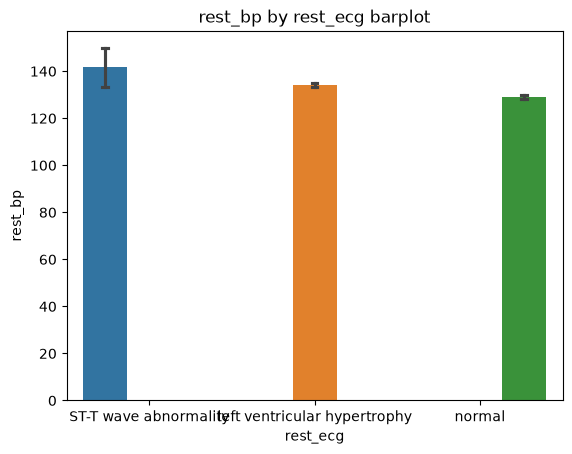

In [988]:
sns.barplot(
    data=corazon_df.dropna(subset=[column_cat, column_num]),
    x=column_cat,
    y=column_num,
    errorbar="ci",
    capsize=0.1,
    hue=column_cat,
).set_title(f"{column_num} by {column_cat} barplot")

#### rest_ecg vs chol

chol    Axes(0.125,0.11;0.775x0.77)
dtype: object

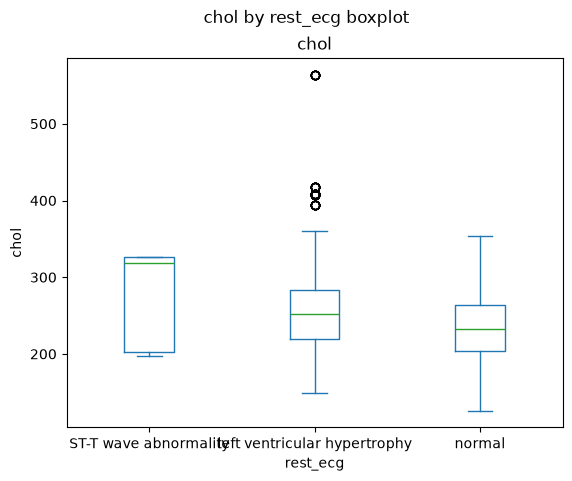

In [989]:
column_cat = "rest_ecg"
column_num = "chol"
corazon_df.plot(
    kind="box",
    column=column_num,
    by=column_cat,
    xlabel=column_cat,
    ylabel=column_num,
    title=f"{column_num} by {column_cat} boxplot",
    grid=False,
)

Text(0.5, 1.0, 'chol by rest_ecg barplot')

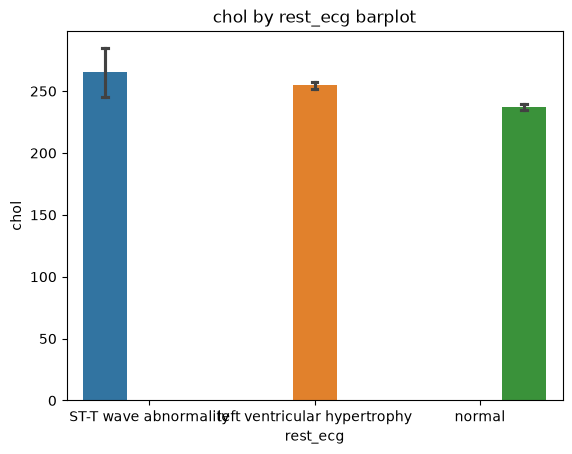

In [990]:
sns.barplot(
    data=corazon_df.dropna(subset=[column_cat, column_num]),
    x=column_cat,
    y=column_num,
    errorbar="ci",
    capsize=0.1,
    hue=column_cat,
).set_title(f"{column_num} by {column_cat} barplot")

#### rest_ecg vs old_peak

old_peak    Axes(0.125,0.11;0.775x0.77)
dtype: object

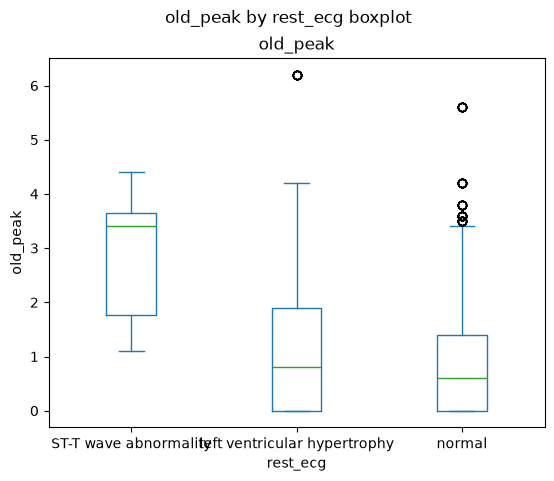

In [991]:
column_cat = "rest_ecg"
column_num = "old_peak"
corazon_df.plot(
    kind="box",
    column=column_num,
    by=column_cat,
    xlabel=column_cat,
    ylabel=column_num,
    title=f"{column_num} by {column_cat} boxplot",
    grid=False,
)

Text(0.5, 1.0, 'old_peak by rest_ecg barplot')

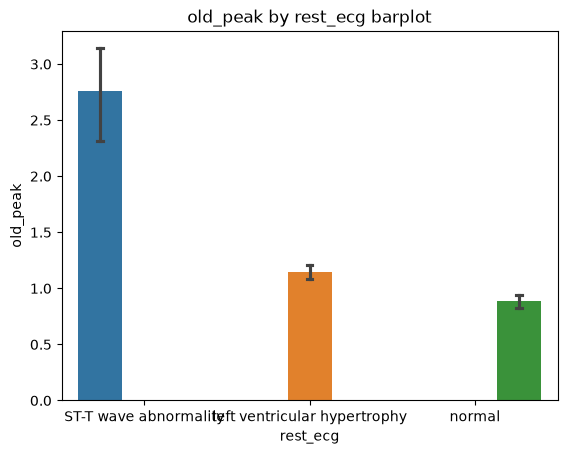

In [992]:
sns.barplot(
    data=corazon_df.dropna(subset=[column_cat, column_num]),
    x=column_cat,
    y=column_num,
    errorbar="ci",
    capsize=0.1,
    hue=column_cat,
).set_title(f"{column_num} by {column_cat} barplot")

#### rest_ecg vs max_hr

max_hr    Axes(0.125,0.11;0.775x0.77)
dtype: object

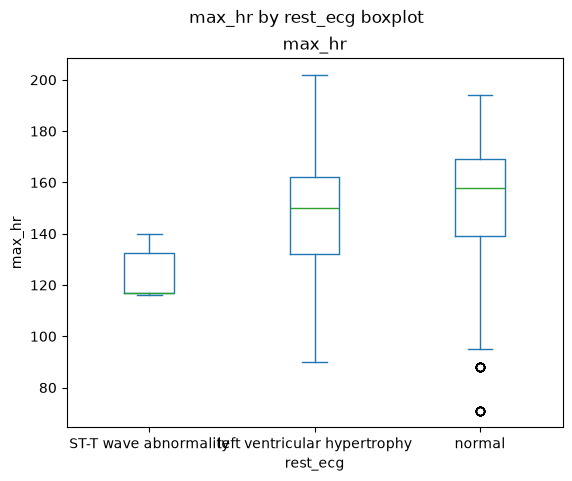

In [993]:
column_cat = "rest_ecg"
column_num = "max_hr"
corazon_df.plot(
    kind="box",
    column=column_num,
    by=column_cat,
    xlabel=column_cat,
    ylabel=column_num,
    title=f"{column_num} by {column_cat} boxplot",
    grid=False,
)

Text(0.5, 1.0, 'max_hr by rest_ecg barplot')

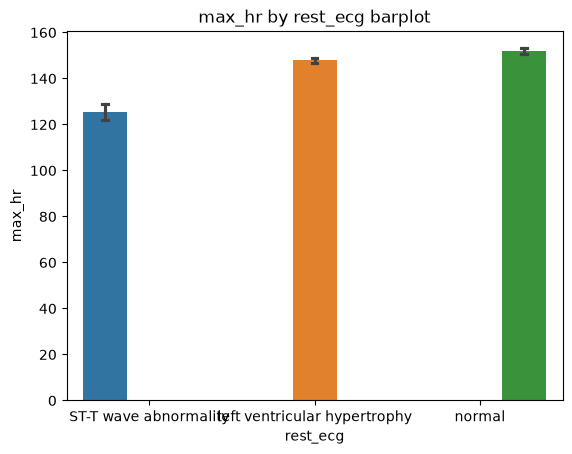

In [994]:
sns.barplot(
    data=corazon_df.dropna(subset=[column_cat, column_num]),
    x=column_cat,
    y=column_num,
    errorbar="ci",
    capsize=0.1,
    hue=column_cat,
).set_title(f"{column_num} by {column_cat} barplot")

#### rest_ecg vs ca

ca    Axes(0.125,0.11;0.775x0.77)
dtype: object

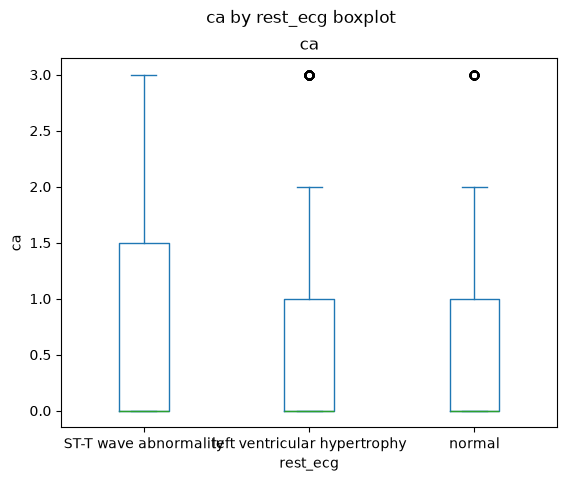

In [995]:
column_cat = "rest_ecg"
column_num = "ca"
corazon_df.plot(
    kind="box",
    column=column_num,
    by=column_cat,
    xlabel=column_cat,
    ylabel=column_num,
    title=f"{column_num} by {column_cat} boxplot",
    grid=False,
)

Text(0.5, 1.0, 'ca by rest_ecg barplot')

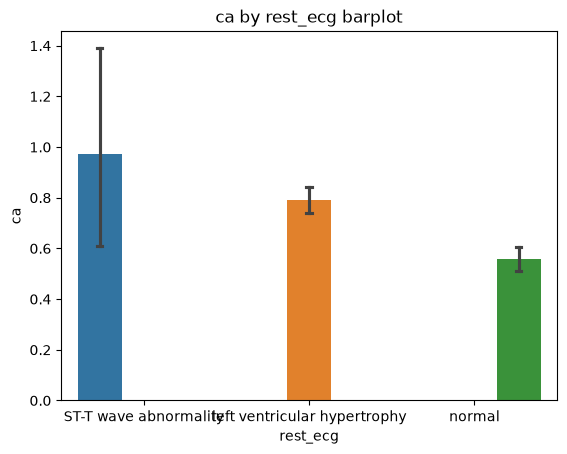

In [996]:
sns.barplot(
    data=corazon_df.dropna(subset=[column_cat, column_num]),
    x=column_cat,
    y=column_num,
    errorbar="ci",
    capsize=0.1,
    hue=column_cat,
).set_title(f"{column_num} by {column_cat} barplot")

#### slope vs age

age    Axes(0.125,0.11;0.775x0.77)
dtype: object

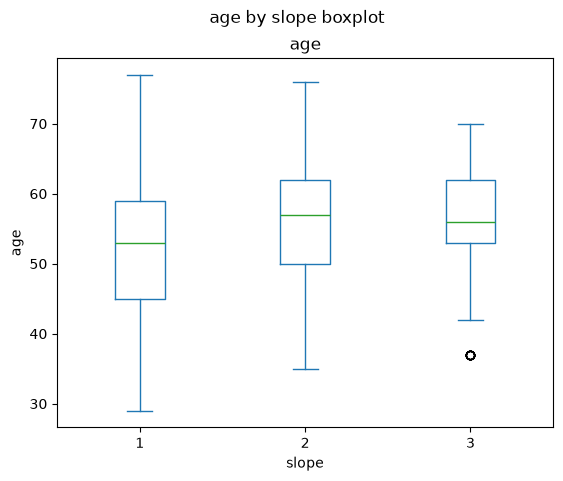

In [997]:
column_cat = "slope"
column_num = "age"
corazon_df.plot(
    kind="box",
    column=column_num,
    by=column_cat,
    xlabel=column_cat,
    ylabel=column_num,
    title=f"{column_num} by {column_cat} boxplot",
    grid=False,
)

Text(0.5, 1.0, 'age by slope barplot')

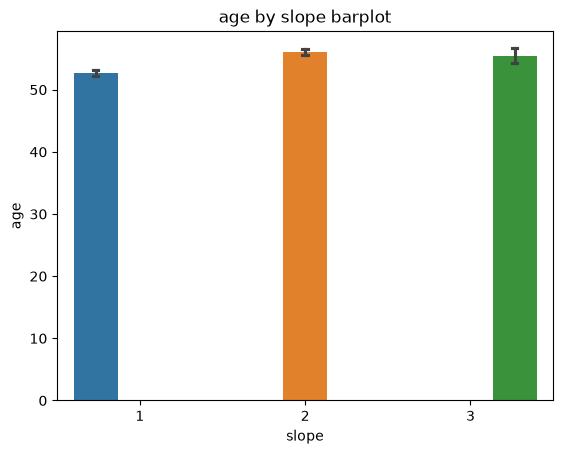

In [998]:
sns.barplot(
    data=corazon_df.dropna(subset=[column_cat, column_num]),
    x=column_cat,
    y=column_num,
    errorbar="ci",
    capsize=0.1,
    hue=column_cat,
).set_title(f"{column_num} by {column_cat} barplot")

#### slope vs rest_bp

rest_bp    Axes(0.125,0.11;0.775x0.77)
dtype: object

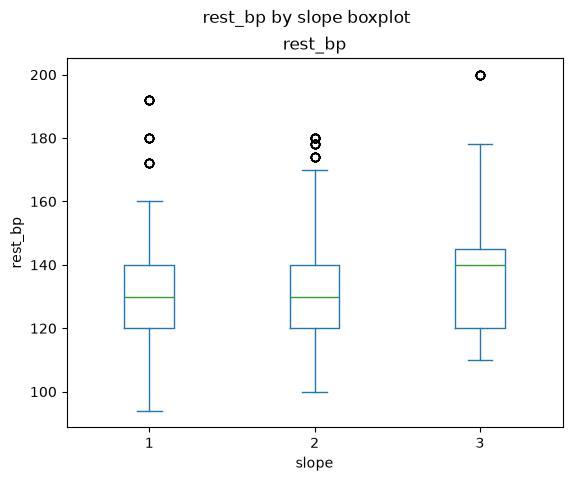

In [999]:
column_cat = "slope"
column_num = "rest_bp"
corazon_df.plot(
    kind="box",
    column=column_num,
    by=column_cat,
    xlabel=column_cat,
    ylabel=column_num,
    title=f"{column_num} by {column_cat} boxplot",
    grid=False,
)

Text(0.5, 1.0, 'rest_bp by slope barplot')

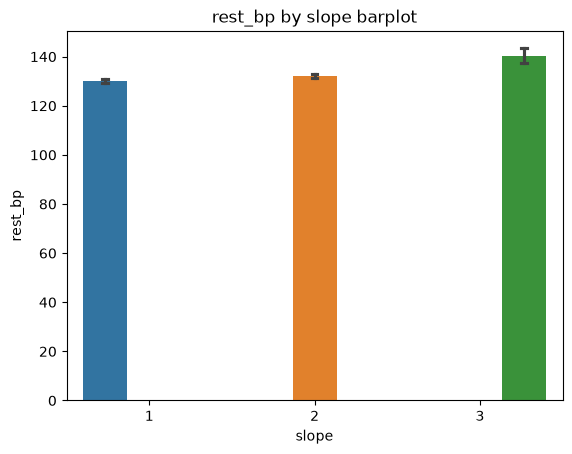

In [1000]:
sns.barplot(
    data=corazon_df.dropna(subset=[column_cat, column_num]),
    x=column_cat,
    y=column_num,
    errorbar="ci",
    capsize=0.1,
    hue=column_cat,
).set_title(f"{column_num} by {column_cat} barplot")

#### slope vs chol

chol    Axes(0.125,0.11;0.775x0.77)
dtype: object

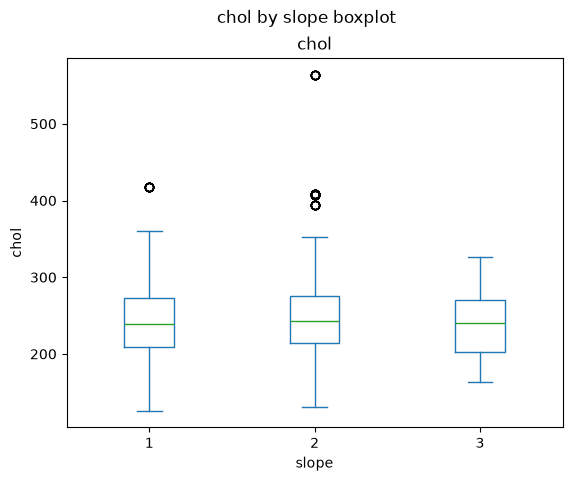

In [1001]:
column_cat = "slope"
column_num = "chol"
corazon_df.plot(
    kind="box",
    column=column_num,
    by=column_cat,
    xlabel=column_cat,
    ylabel=column_num,
    title=f"{column_num} by {column_cat} boxplot",
    grid=False,
)

Text(0.5, 1.0, 'chol by slope barplot')

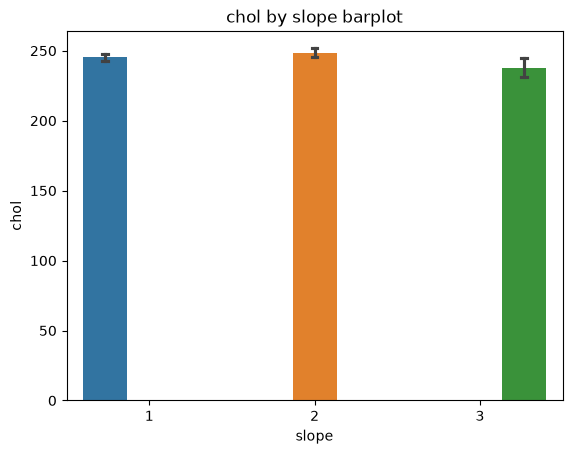

In [1002]:
sns.barplot(
    data=corazon_df.dropna(subset=[column_cat, column_num]),
    x=column_cat,
    y=column_num,
    errorbar="ci",
    capsize=0.1,
    hue=column_cat,
).set_title(f"{column_num} by {column_cat} barplot")

#### slope vs old_peak

old_peak    Axes(0.125,0.11;0.775x0.77)
dtype: object

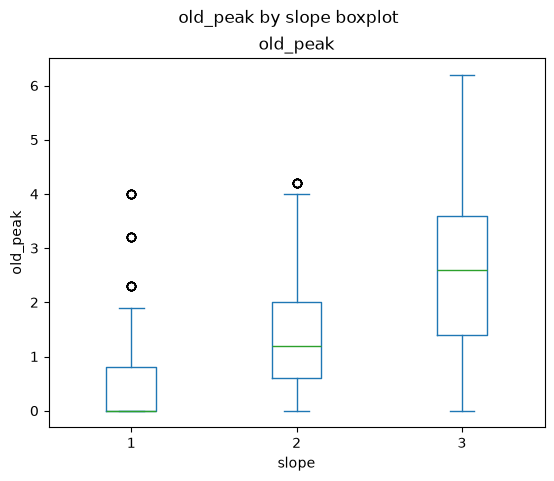

In [1003]:
column_cat = "slope"
column_num = "old_peak"
corazon_df.plot(
    kind="box",
    column=column_num,
    by=column_cat,
    xlabel=column_cat,
    ylabel=column_num,
    title=f"{column_num} by {column_cat} boxplot",
    grid=False,
)

Text(0.5, 1.0, 'old_peak by slope barplot')

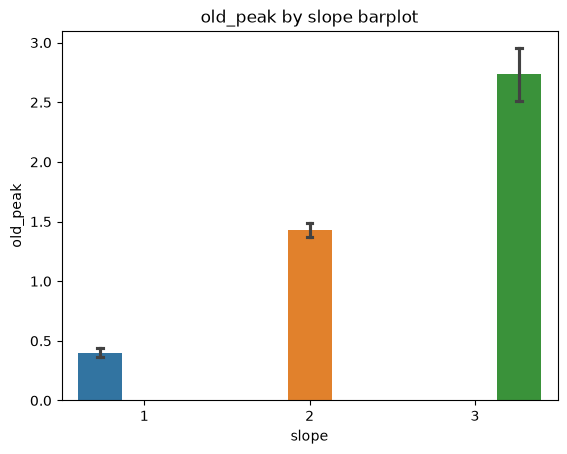

In [1004]:
sns.barplot(
    data=corazon_df.dropna(subset=[column_cat, column_num]),
    x=column_cat,
    y=column_num,
    errorbar="ci",
    capsize=0.1,
    hue=column_cat,
).set_title(f"{column_num} by {column_cat} barplot")

#### slope vs max_hr

max_hr    Axes(0.125,0.11;0.775x0.77)
dtype: object

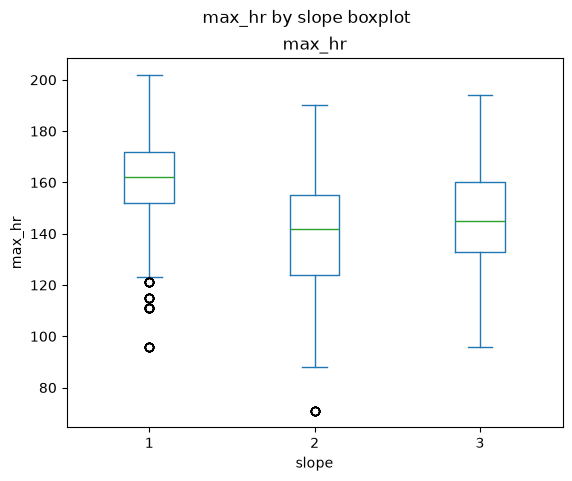

In [1005]:
column_cat = "slope"
column_num = "max_hr"
corazon_df.plot(
    kind="box",
    column=column_num,
    by=column_cat,
    xlabel=column_cat,
    ylabel=column_num,
    title=f"{column_num} by {column_cat} boxplot",
    grid=False,
)

Text(0.5, 1.0, 'max_hr by slope barplot')

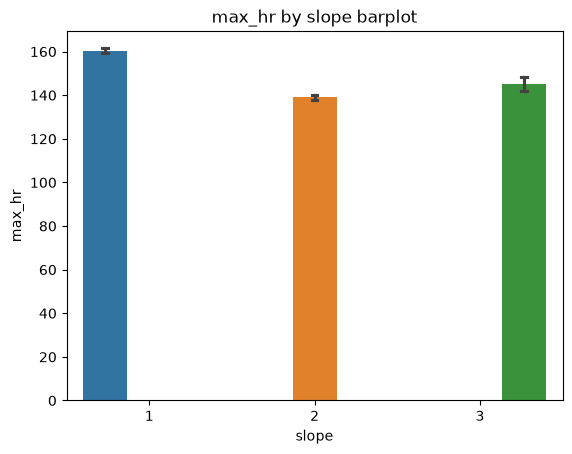

In [1006]:
sns.barplot(
    data=corazon_df.dropna(subset=[column_cat, column_num]),
    x=column_cat,
    y=column_num,
    errorbar="ci",
    capsize=0.1,
    hue=column_cat,
).set_title(f"{column_num} by {column_cat} barplot")

#### slope vs ca

ca    Axes(0.125,0.11;0.775x0.77)
dtype: object

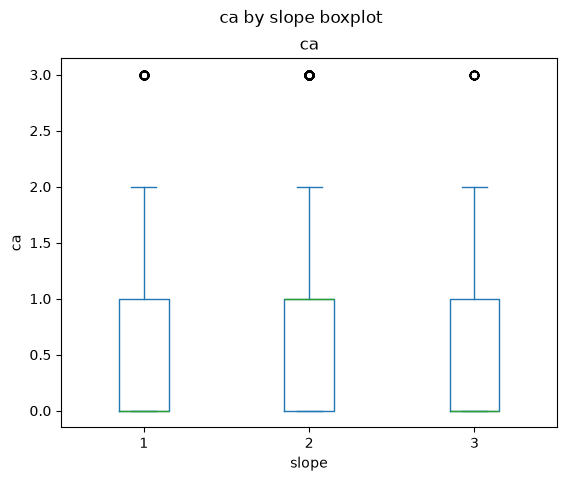

In [1007]:
column_cat = "slope"
column_num = "ca"
corazon_df.plot(
    kind="box",
    column=column_num,
    by=column_cat,
    xlabel=column_cat,
    ylabel=column_num,
    title=f"{column_num} by {column_cat} boxplot",
    grid=False,
)

Text(0.5, 1.0, 'ca by slope barplot')

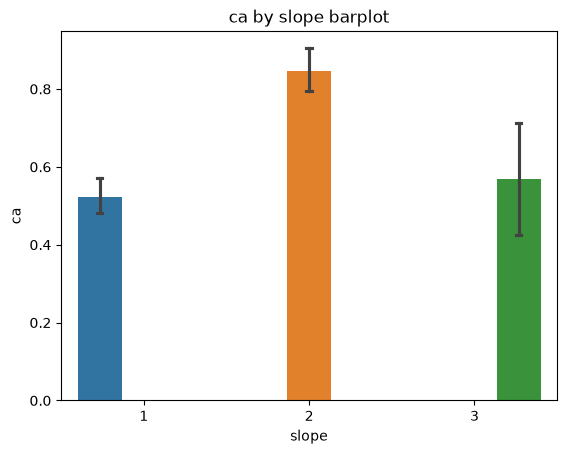

In [1008]:
sns.barplot(
    data=corazon_df.dropna(subset=[column_cat, column_num]),
    x=column_cat,
    y=column_num,
    errorbar="ci",
    capsize=0.1,
    hue=column_cat,
).set_title(f"{column_num} by {column_cat} barplot")

#### thal vs age

age    Axes(0.125,0.11;0.775x0.77)
dtype: object

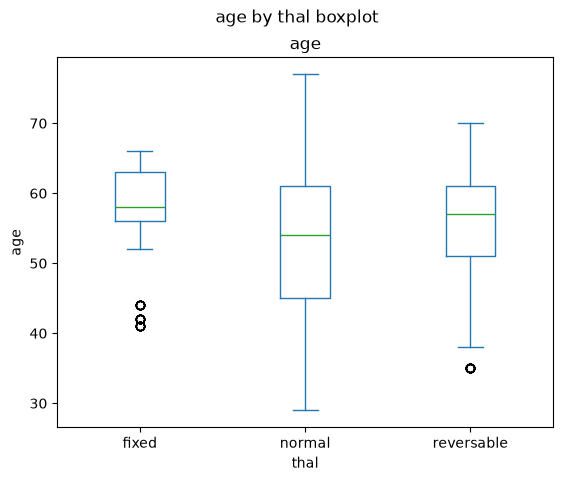

In [1009]:
column_cat = "thal"
column_num = "age"
corazon_df.plot(
    kind="box",
    column=column_num,
    by=column_cat,
    xlabel=column_cat,
    ylabel=column_num,
    title=f"{column_num} by {column_cat} boxplot",
    grid=False,
)

Text(0.5, 1.0, 'age by thal barplot')

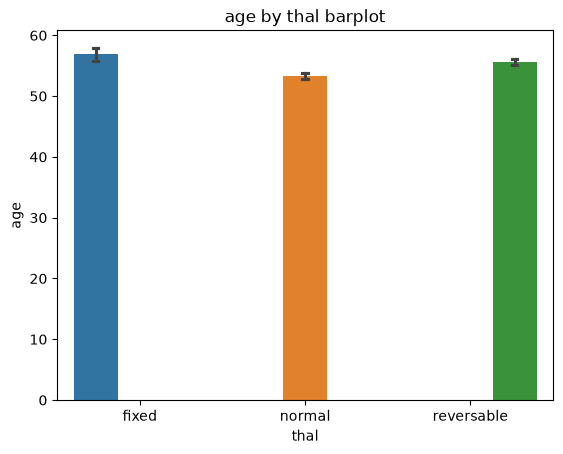

In [1010]:
sns.barplot(
    data=corazon_df.dropna(subset=[column_cat, column_num]),
    x=column_cat,
    y=column_num,
    errorbar="ci",
    capsize=0.1,
    hue=column_cat,
).set_title(f"{column_num} by {column_cat} barplot")

#### thal vs rest_bp

rest_bp    Axes(0.125,0.11;0.775x0.77)
dtype: object

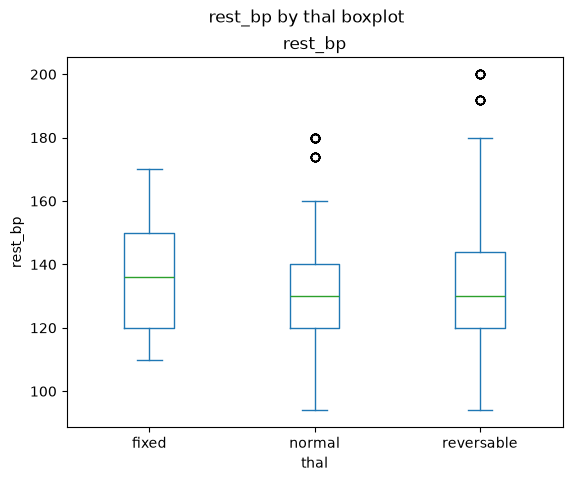

In [1011]:
column_cat = "thal"
column_num = "rest_bp"
corazon_df.plot(
    kind="box",
    column=column_num,
    by=column_cat,
    xlabel=column_cat,
    ylabel=column_num,
    title=f"{column_num} by {column_cat} boxplot",
    grid=False,
)

Text(0.5, 1.0, 'rest_bp by thal barplot')

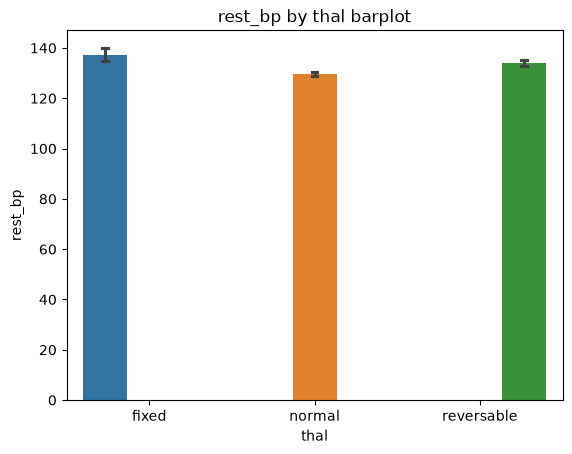

In [1012]:
sns.barplot(
    data=corazon_df.dropna(subset=[column_cat, column_num]),
    x=column_cat,
    y=column_num,
    errorbar="ci",
    capsize=0.1,
    hue=column_cat,
).set_title(f"{column_num} by {column_cat} barplot")

#### thal vs chol

chol    Axes(0.125,0.11;0.775x0.77)
dtype: object

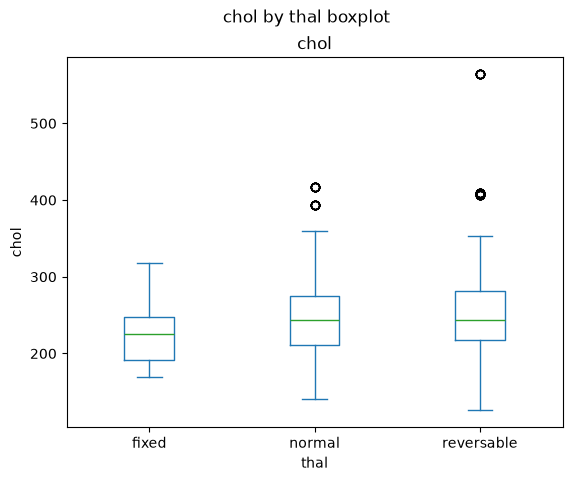

In [1013]:
column_cat = "thal"
column_num = "chol"
corazon_df.plot(
    kind="box",
    column=column_num,
    by=column_cat,
    xlabel=column_cat,
    ylabel=column_num,
    title=f"{column_num} by {column_cat} boxplot",
    grid=False,
)

Text(0.5, 1.0, 'chol by thal barplot')

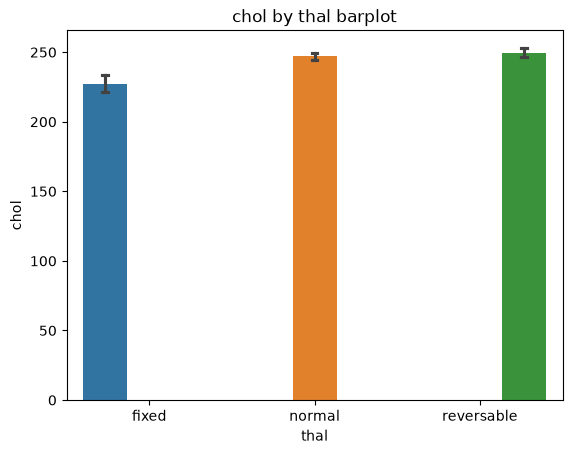

In [1014]:
sns.barplot(
    data=corazon_df.dropna(subset=[column_cat, column_num]),
    x=column_cat,
    y=column_num,
    errorbar="ci",
    capsize=0.1,
    hue=column_cat,
).set_title(f"{column_num} by {column_cat} barplot")

#### thal vs old_peak

old_peak    Axes(0.125,0.11;0.775x0.77)
dtype: object

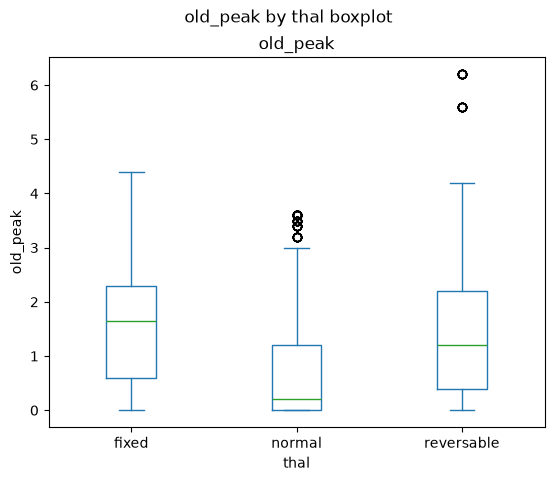

In [1015]:
column_cat = "thal"
column_num = "old_peak"
corazon_df.plot(
    kind="box",
    column=column_num,
    by=column_cat,
    xlabel=column_cat,
    ylabel=column_num,
    title=f"{column_num} by {column_cat} boxplot",
    grid=False,
)

Text(0.5, 1.0, 'old_peak by thal barplot')

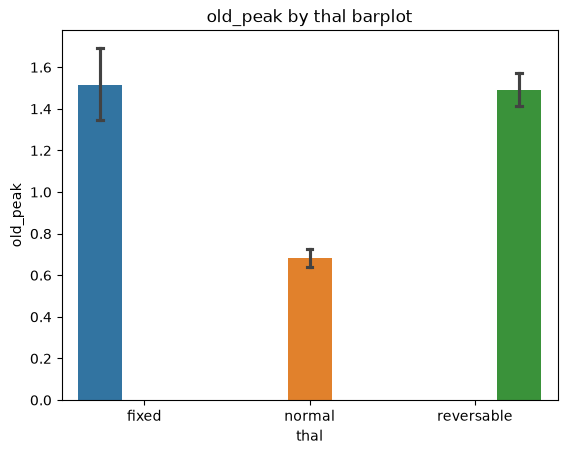

In [1016]:
sns.barplot(
    data=corazon_df.dropna(subset=[column_cat, column_num]),
    x=column_cat,
    y=column_num,
    errorbar="ci",
    capsize=0.1,
    hue=column_cat,
).set_title(f"{column_num} by {column_cat} barplot")

#### thal vs max_hr

max_hr    Axes(0.125,0.11;0.775x0.77)
dtype: object

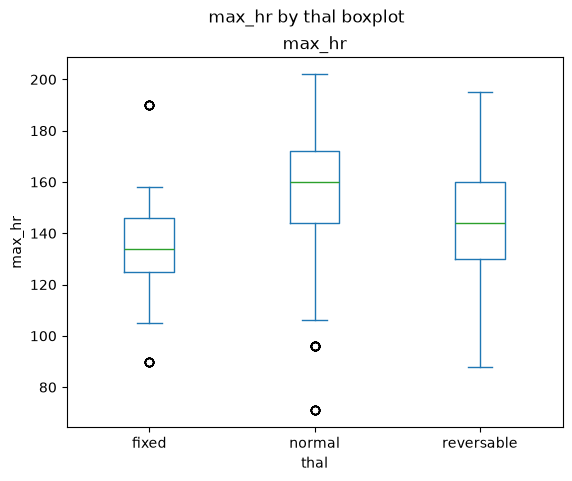

In [1017]:
column_cat = "thal"
column_num = "max_hr"
corazon_df.plot(
    kind="box",
    column=column_num,
    by=column_cat,
    xlabel=column_cat,
    ylabel=column_num,
    title=f"{column_num} by {column_cat} boxplot",
    grid=False,
)

Text(0.5, 1.0, 'max_hr by thal barplot')

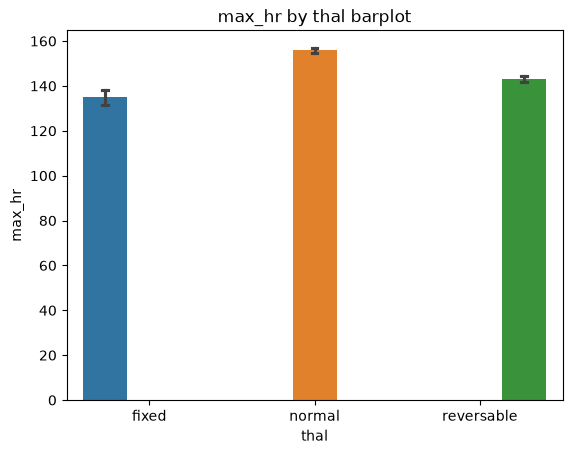

In [1018]:
sns.barplot(
    data=corazon_df.dropna(subset=[column_cat, column_num]),
    x=column_cat,
    y=column_num,
    errorbar="ci",
    capsize=0.1,
    hue=column_cat,
).set_title(f"{column_num} by {column_cat} barplot")

#### thal vs ca

ca    Axes(0.125,0.11;0.775x0.77)
dtype: object

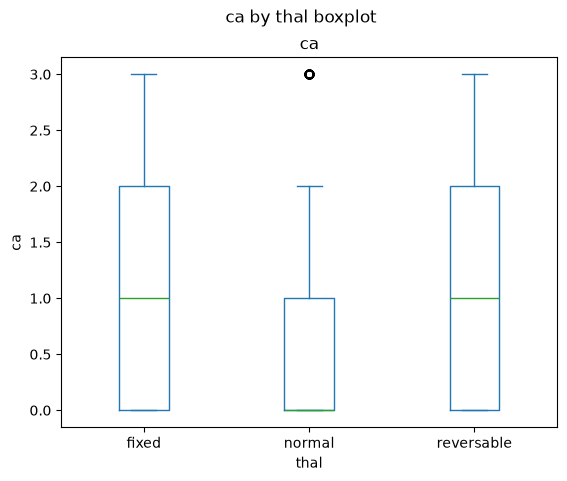

In [1019]:
column_cat = "thal"
column_num = "ca"
corazon_df.plot(
    kind="box",
    column=column_num,
    by=column_cat,
    xlabel=column_cat,
    ylabel=column_num,
    title=f"{column_num} by {column_cat} boxplot",
    grid=False,
)

Text(0.5, 1.0, 'ca by thal barplot')

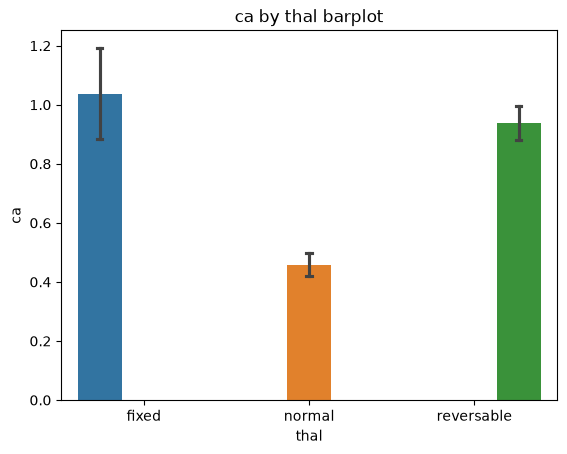

In [1020]:
sns.barplot(
    data=corazon_df.dropna(subset=[column_cat, column_num]),
    x=column_cat,
    y=column_num,
    errorbar="ci",
    capsize=0.1,
    hue=column_cat,
).set_title(f"{column_num} by {column_cat} barplot")

#### fbs vs age

age    Axes(0.125,0.11;0.775x0.77)
dtype: object

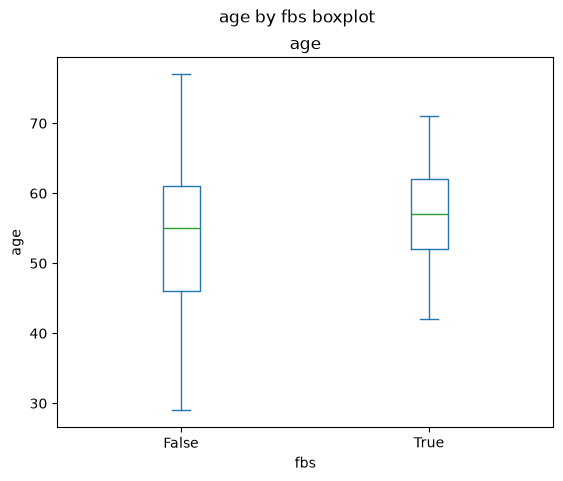

In [1021]:
column_cat = "fbs"
column_num = "age"
corazon_df.plot(
    kind="box",
    column=column_num,
    by=column_cat,
    xlabel=column_cat,
    ylabel=column_num,
    title=f"{column_num} by {column_cat} boxplot",
    grid=False,
)

Text(0.5, 1.0, 'age by fbs barplot')

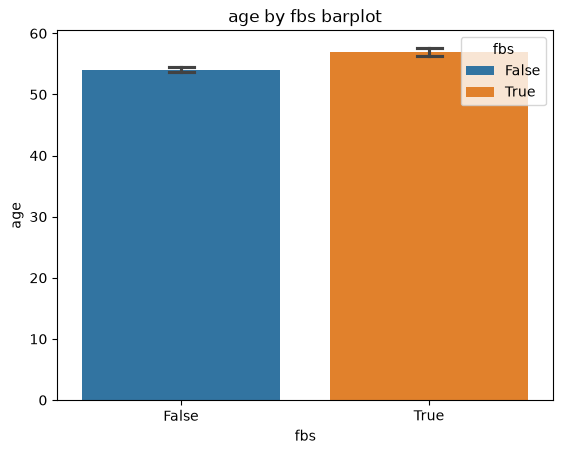

In [1022]:
sns.barplot(
    data=corazon_df.dropna(subset=[column_cat, column_num]),
    x=column_cat,
    y=column_num,
    errorbar="ci",
    capsize=0.1,
    hue=column_cat,
).set_title(f"{column_num} by {column_cat} barplot")

#### fbs vs rest_bp

rest_bp    Axes(0.125,0.11;0.775x0.77)
dtype: object

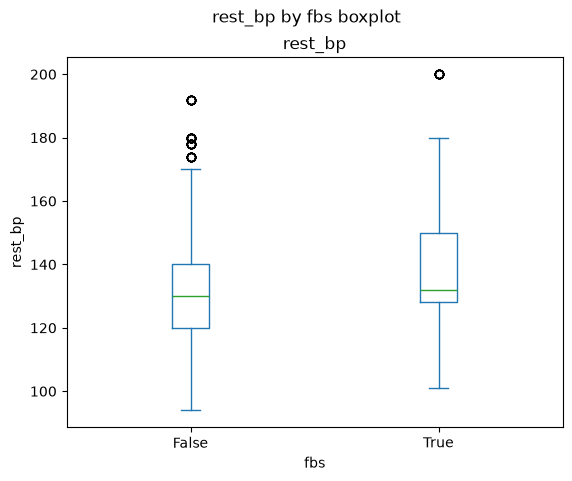

In [1023]:
column_cat = "fbs"
column_num = "rest_bp"
corazon_df.plot(
    kind="box",
    column=column_num,
    by=column_cat,
    xlabel=column_cat,
    ylabel=column_num,
    title=f"{column_num} by {column_cat} boxplot",
    grid=False,
)

Text(0.5, 1.0, 'rest_bp by fbs barplot')

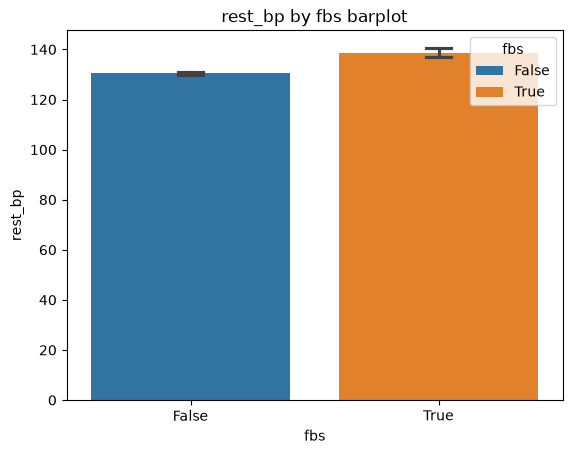

In [1024]:
sns.barplot(
    data=corazon_df.dropna(subset=[column_cat, column_num]),
    x=column_cat,
    y=column_num,
    errorbar="ci",
    capsize=0.1,
    hue=column_cat,
).set_title(f"{column_num} by {column_cat} barplot")

#### fbs vs chol

chol    Axes(0.125,0.11;0.775x0.77)
dtype: object

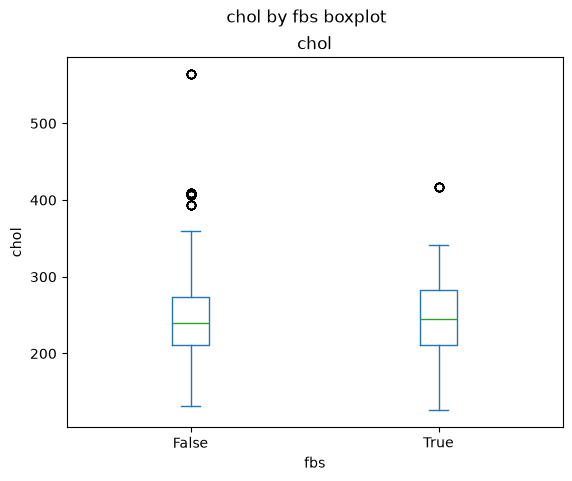

In [1025]:
column_cat = "fbs"
column_num = "chol"
corazon_df.plot(
    kind="box",
    column=column_num,
    by=column_cat,
    xlabel=column_cat,
    ylabel=column_num,
    title=f"{column_num} by {column_cat} boxplot",
    grid=False,
)

Text(0.5, 1.0, 'chol by fbs barplot')

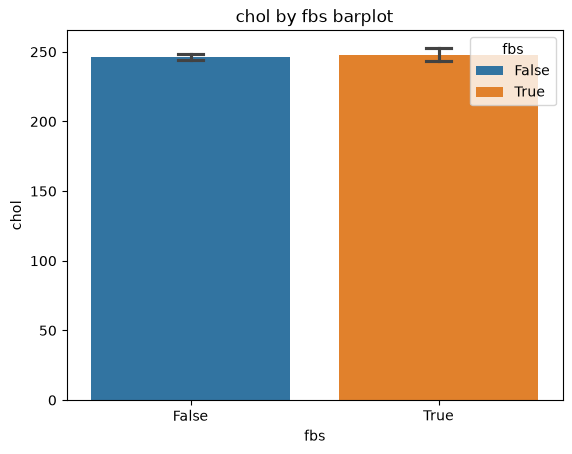

In [1026]:
sns.barplot(
    data=corazon_df.dropna(subset=[column_cat, column_num]),
    x=column_cat,
    y=column_num,
    errorbar="ci",
    capsize=0.1,
    hue=column_cat,
).set_title(f"{column_num} by {column_cat} barplot")

#### fbs vs old_peak

old_peak    Axes(0.125,0.11;0.775x0.77)
dtype: object

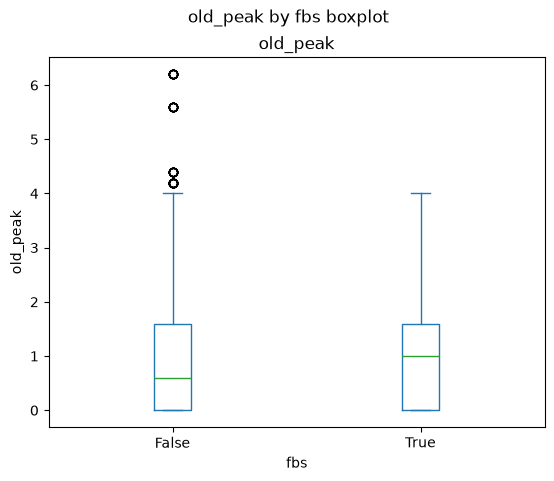

In [1027]:
column_cat = "fbs"
column_num = "old_peak"
corazon_df.plot(
    kind="box",
    column=column_num,
    by=column_cat,
    xlabel=column_cat,
    ylabel=column_num,
    title=f"{column_num} by {column_cat} boxplot",
    grid=False,
)

Text(0.5, 1.0, 'old_peak by fbs barplot')

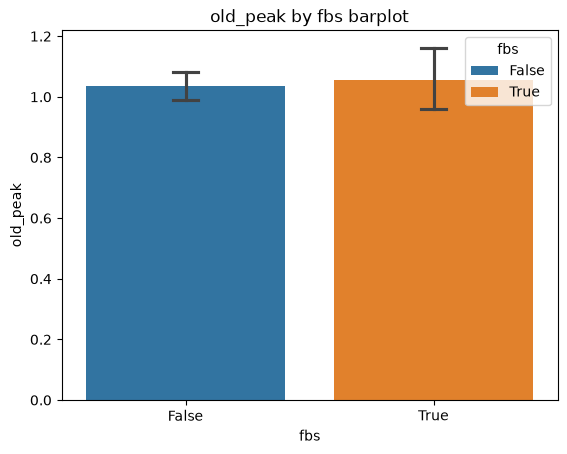

In [1028]:
sns.barplot(
    data=corazon_df.dropna(subset=[column_cat, column_num]),
    x=column_cat,
    y=column_num,
    errorbar="ci",
    capsize=0.1,
    hue=column_cat,
).set_title(f"{column_num} by {column_cat} barplot")

#### fbs vs max_hr

max_hr    Axes(0.125,0.11;0.775x0.77)
dtype: object

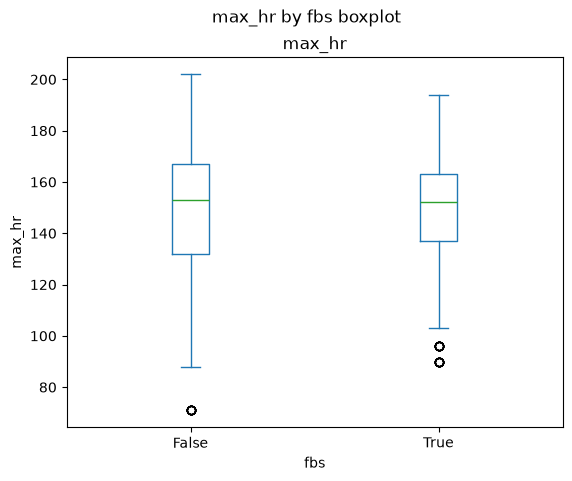

In [1029]:
column_cat = "fbs"
column_num = "max_hr"
corazon_df.plot(
    kind="box",
    column=column_num,
    by=column_cat,
    xlabel=column_cat,
    ylabel=column_num,
    title=f"{column_num} by {column_cat} boxplot",
    grid=False,
)

Text(0.5, 1.0, 'max_hr by fbs barplot')

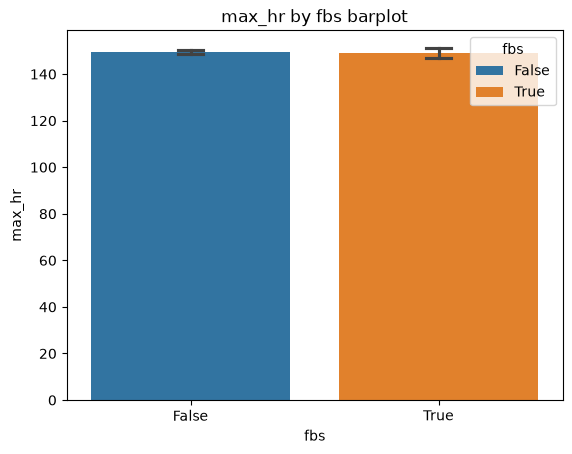

In [1030]:
sns.barplot(
    data=corazon_df.dropna(subset=[column_cat, column_num]),
    x=column_cat,
    y=column_num,
    errorbar="ci",
    capsize=0.1,
    hue=column_cat,
).set_title(f"{column_num} by {column_cat} barplot")

#### fbs vs ca

ca    Axes(0.125,0.11;0.775x0.77)
dtype: object

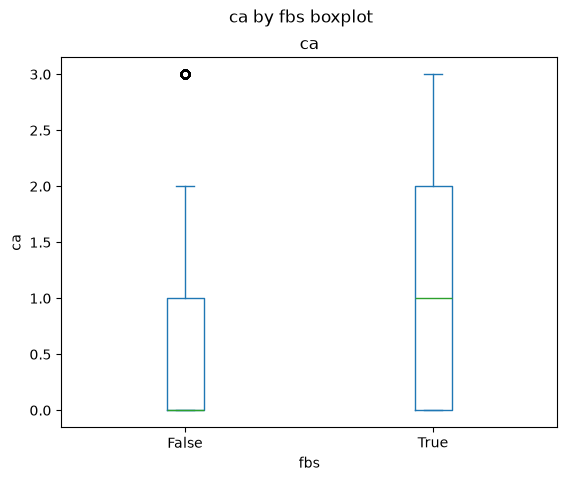

In [1031]:
column_cat = "fbs"
column_num = "ca"
corazon_df.plot(
    kind="box",
    column=column_num,
    by=column_cat,
    xlabel=column_cat,
    ylabel=column_num,
    title=f"{column_num} by {column_cat} boxplot",
    grid=False,
)

Text(0.5, 1.0, 'ca by fbs barplot')

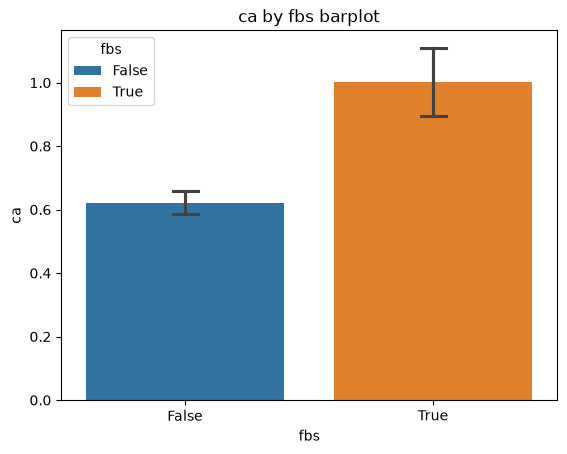

In [1032]:
sns.barplot(
    data=corazon_df.dropna(subset=[column_cat, column_num]),
    x=column_cat,
    y=column_num,
    errorbar="ci",
    capsize=0.1,
    hue=column_cat,
).set_title(f"{column_num} by {column_cat} barplot")

#### exang vs age

/home/karen/Dataset-Corazon/.venv/lib/python3.12/site-packages/IPython/core/displayhook.py:291: UserWarning: Output cache limit (currently 1000 entries) hit.
Flushing oldest 200 entries.
  warn('Output cache limit (currently {sz} entries) hit.\n'


age    Axes(0.125,0.11;0.775x0.77)
dtype: object

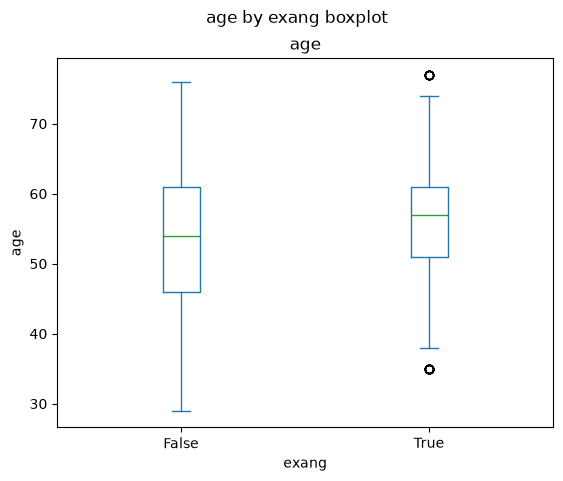

In [1033]:
column_cat = "exang"
column_num = "age"
corazon_df.plot(
    kind="box",
    column=column_num,
    by=column_cat,
    xlabel=column_cat,
    ylabel=column_num,
    title=f"{column_num} by {column_cat} boxplot",
    grid=False,
)

Text(0.5, 1.0, 'age by exang barplot')

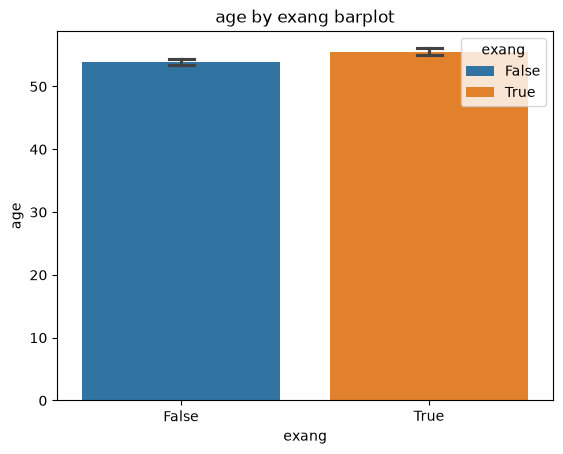

In [1034]:
sns.barplot(
    data=corazon_df.dropna(subset=[column_cat, column_num]),
    x=column_cat,
    y=column_num,
    errorbar="ci",
    capsize=0.1,
    hue=column_cat,
).set_title(f"{column_num} by {column_cat} barplot")

#### exang vs rest_bp

rest_bp    Axes(0.125,0.11;0.775x0.77)
dtype: object

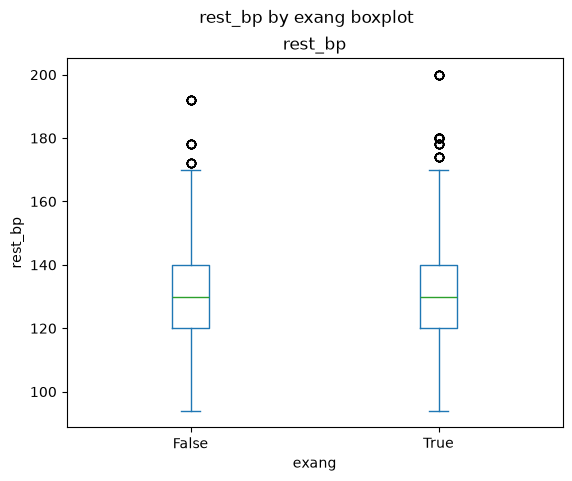

In [1035]:
column_cat = "exang"
column_num = "rest_bp"
corazon_df.plot(
    kind="box",
    column=column_num,
    by=column_cat,
    xlabel=column_cat,
    ylabel=column_num,
    title=f"{column_num} by {column_cat} boxplot",
    grid=False,
)

Text(0.5, 1.0, 'rest_bp by exang barplot')

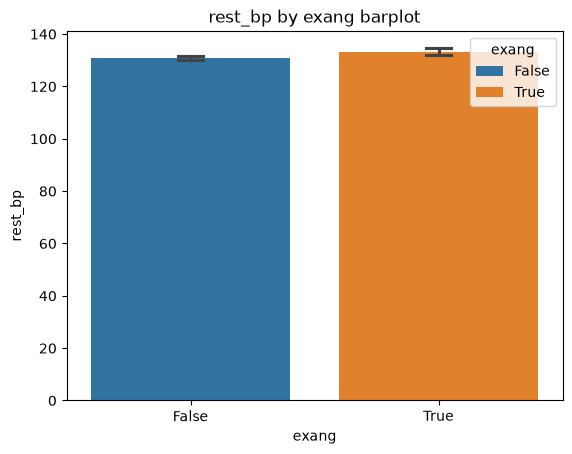

In [1036]:
sns.barplot(
    data=corazon_df.dropna(subset=[column_cat, column_num]),
    x=column_cat,
    y=column_num,
    errorbar="ci",
    capsize=0.1,
    hue=column_cat,
).set_title(f"{column_num} by {column_cat} barplot")

#### exang vs chol

chol    Axes(0.125,0.11;0.775x0.77)
dtype: object

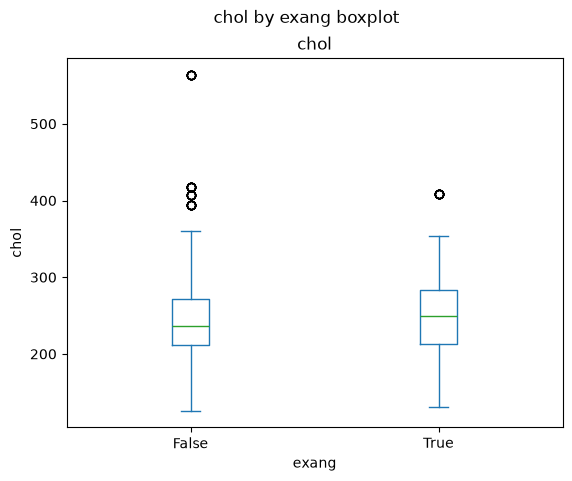

In [1037]:
column_cat = "exang"
column_num = "chol"
corazon_df.plot(
    kind="box",
    column=column_num,
    by=column_cat,
    xlabel=column_cat,
    ylabel=column_num,
    title=f"{column_num} by {column_cat} boxplot",
    grid=False,
)

Text(0.5, 1.0, 'chol by exang barplot')

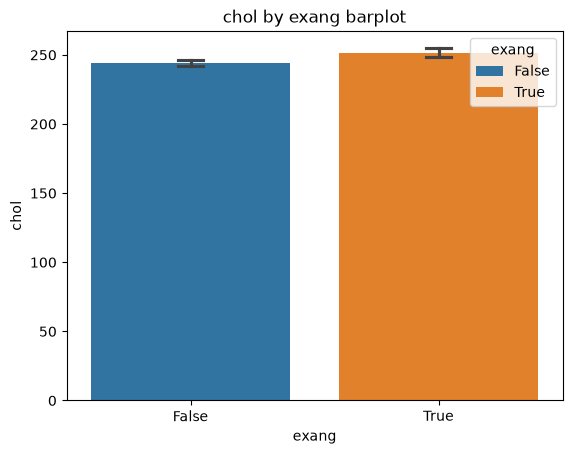

In [1038]:
sns.barplot(
    data=corazon_df.dropna(subset=[column_cat, column_num]),
    x=column_cat,
    y=column_num,
    errorbar="ci",
    capsize=0.1,
    hue=column_cat,
).set_title(f"{column_num} by {column_cat} barplot")

#### exang vs old_peak

old_peak    Axes(0.125,0.11;0.775x0.77)
dtype: object

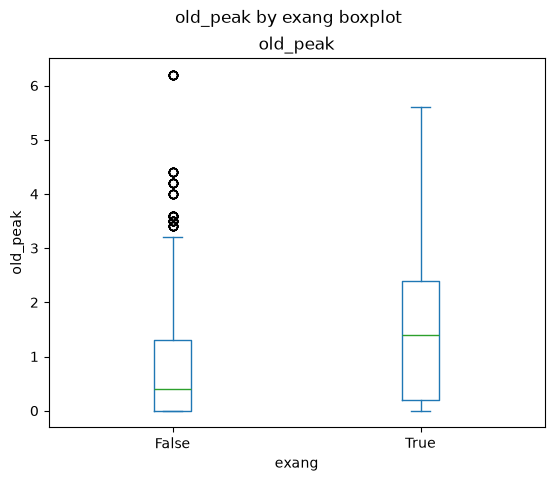

In [1039]:
column_cat = "exang"
column_num = "old_peak"
corazon_df.plot(
    kind="box",
    column=column_num,
    by=column_cat,
    xlabel=column_cat,
    ylabel=column_num,
    title=f"{column_num} by {column_cat} boxplot",
    grid=False,
)

Text(0.5, 1.0, 'old_peak by exang barplot')

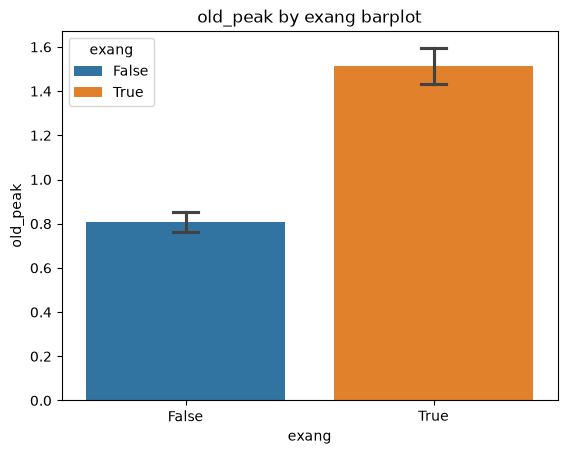

In [1040]:
sns.barplot(
    data=corazon_df.dropna(subset=[column_cat, column_num]),
    x=column_cat,
    y=column_num,
    errorbar="ci",
    capsize=0.1,
    hue=column_cat,
).set_title(f"{column_num} by {column_cat} barplot")

#### exang vs max_hr

max_hr    Axes(0.125,0.11;0.775x0.77)
dtype: object

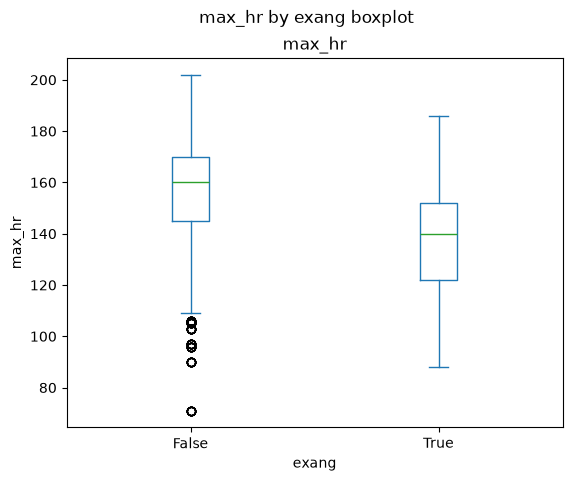

In [1041]:
column_cat = "exang"
column_num = "max_hr"
corazon_df.plot(
    kind="box",
    column=column_num,
    by=column_cat,
    xlabel=column_cat,
    ylabel=column_num,
    title=f"{column_num} by {column_cat} boxplot",
    grid=False,
)

Text(0.5, 1.0, 'max_hr by exang barplot')

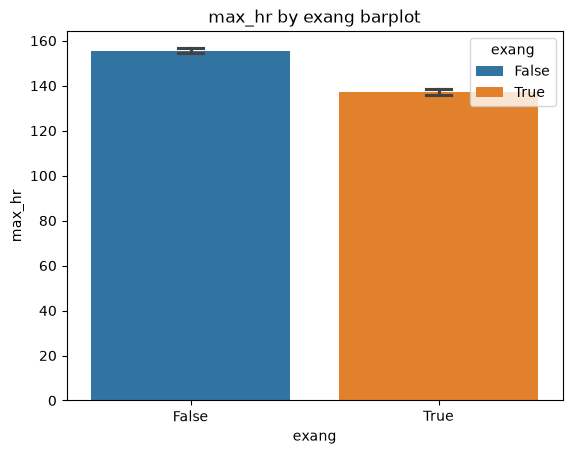

In [1042]:
sns.barplot(
    data=corazon_df.dropna(subset=[column_cat, column_num]),
    x=column_cat,
    y=column_num,
    errorbar="ci",
    capsize=0.1,
    hue=column_cat,
).set_title(f"{column_num} by {column_cat} barplot")

#### exang vs ca

ca    Axes(0.125,0.11;0.775x0.77)
dtype: object

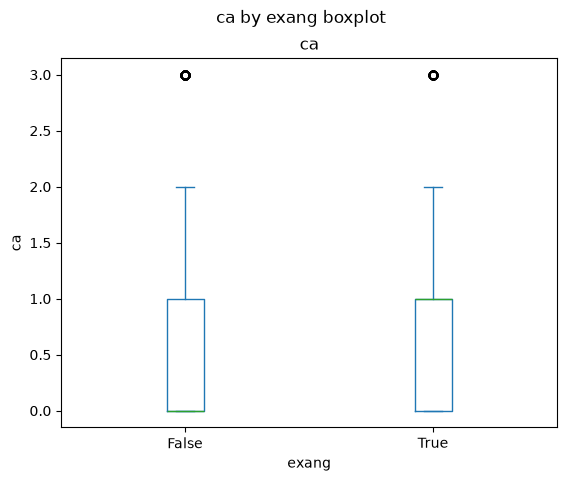

In [1043]:
column_cat = "exang"
column_num = "ca"
corazon_df.plot(
    kind="box",
    column=column_num,
    by=column_cat,
    xlabel=column_cat,
    ylabel=column_num,
    title=f"{column_num} by {column_cat} boxplot",
    grid=False,
)

Text(0.5, 1.0, 'ca by exang barplot')

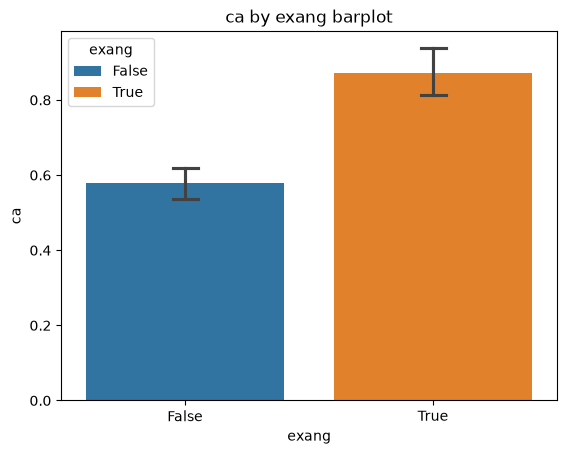

In [1044]:
sns.barplot(
    data=corazon_df.dropna(subset=[column_cat, column_num]),
    x=column_cat,
    y=column_num,
    errorbar="ci",
    capsize=0.1,
    hue=column_cat,
).set_title(f"{column_num} by {column_cat} barplot")

In [1045]:
numerical_cols = ["age", "rest_bp", "chol", "old_peak", "max_hr", "ca"]
categorical_cols = ["sex", "chest_pain", "rest_ecg", "slope", "thal", "fbs", "exang"]

for cat in categorical_cols:
    print(f"--- Promedio de variables numéricas por {cat} ---")
    print(corazon_df.groupby(cat, observed=True)[numerical_cols].mean())
    print()

--- Promedio de variables numéricas por sex ---
         age  rest_bp   chol  old_peak  max_hr   ca
sex                                                
Female 55.76   133.18 261.47      0.87  151.52 0.55
Male   53.85   130.87 239.71      1.12  148.66 0.74

--- Promedio de variables numéricas por chest_pain ---
               age  rest_bp   chol  old_peak  max_hr   ca
chest_pain                                               
asymptomatic 55.76   132.16 250.57      1.37  140.68 0.93
nonanginal   53.73   129.96 244.07      0.80  155.41 0.47
nontypical   51.43   128.54 244.98      0.31  162.24 0.37
typical      55.99   141.41 237.49      1.40  155.38 0.49

--- Promedio de variables numéricas por rest_ecg ---
                               age  rest_bp   chol  old_peak  max_hr   ca
rest_ecg                                                                 
ST-T wave abnormality        61.00   141.94 265.14      2.76  125.39 0.97
left ventricular hypertrophy 55.66   134.18 254.75      1.14  14

## 📊 Analysis of Results and Conclusions

### Target vs Numerical Variables

- **age:** Los pacientes con enfermedad tienden a ser mayores (mediana ~58 años) que los que no la tienen (mediana ~52 años).
- **rest_bp:** Sin diferencia relevante entre pacientes con y sin enfermedad (mediana 130 en ambos casos).
- **chol:** Ligeramente más alto en pacientes con enfermedad (mediana ~248 vs ~235), pero con distribuciones muy solapadas.
- **old_peak:** Una de las variables más discriminantes: los pacientes con enfermedad tienen valores notablemente más altos (mediana ~1.4 vs ~0.2).
- **max_hr:** Relación inversa: los pacientes con enfermedad alcanzan frecuencias cardíacas máximas más bajas (mediana ~142 vs ~161).
- **ca:** También muy discriminante: los pacientes sin enfermedad concentran casi todo en 0 vasos afectados, mientras que los pacientes con enfermedad se reparten entre 0 y 3, con mediana en 1.

### Target vs Categorical Variables

- **sex:** Los hombres presentan una tasa de enfermedad mucho mayor (55.45%) que las mujeres (26.24%).
- **chest_pain:** El tipo "asymptomatic" tiene la tasa más alta de enfermedad (73.05%), mientras "nontypical" tiene la más baja (17.46%) — un patrón que puede parecer contraintuitivo, pero es consistente con la literatura clínica real de este dataset.
- **rest_ecg:** "ST-T wave abnormality" tiene la tasa más alta (77.14%) frente a "normal" (36.81%).
- **slope:** La categoría 2 tiene la tasa más alta (65.47%), la 1 la más baja (24.79%).
- **thal:** "Reversable" (76.11%) y "fixed" (68.05%) tienen tasas mucho más altas que "normal" (22.26%).
- **fbs:** Prácticamente sin diferencia (45.49% vs 48.21%) — parece ser una variable poco predictiva.
- **exang:** Fuerte diferencia: 76.41% con enfermedad cuando hay angina inducida por ejercicio, frente a 30.62% cuando no la hay.

### Numerical vs Numerical Variables

La mayoría de los pares de variables numéricas no muestran correlación clara entre sí. Las excepciones son **age vs max_hr** (relación negativa moderada: a mayor edad, menor frecuencia cardíaca máxima) y **age vs ca** (relación positiva: a mayor edad, más vasos afectados).

### Categorical vs Categorical Variables

Se destacan dos patrones: **sex vs thal** (los hombres tienen una proporción mucho mayor de "reversable", mientras las mujeres concentran "normal") y **chest_pain vs exang** (los pacientes con dolor "asymptomatic" presentan angina inducida por ejercicio con mucha más frecuencia que los demás tipos de dolor).

### Categorical vs Numerical Variables

Los promedios agrupados confirman los patrones ya vistos: las categorías asociadas con mayor tasa de enfermedad (`thal=fixed/reversable`, `chest_pain=asymptomatic`, `exang=True`) también presentan, en promedio, más vasos afectados (`ca`), mayor `old_peak` y menor `max_hr` — es decir, las mismas variables numéricas discriminantes aparecen consistentemente relacionadas con las categóricas más predictivas.

### Key Takeaways

- Las variables más asociadas con la enfermedad son: `exang`, `old_peak`, `ca`, `max_hr`, `thal` y `sex` — estas serán las más importantes a considerar para el modelo base.
- `fbs` y `rest_bp` muestran muy poca o ninguna asociación con la variable objetivo, por lo que podrían aportar poco al modelo.
- No hay señales fuertes de multicolinealidad entre las variables numéricas predictoras (salvo la relación moderada entre `age` y `max_hr`), lo cual es favorable para el modelado.
- Varias variables categóricas están relacionadas entre sí (por ejemplo `chest_pain` y `exang`, `sex` y `thal`), lo cual deberá tenerse en cuenta al interpretar el modelo final.

## 💡 Proposals and Ideas

Para el primer modelo base (baseline), se podrían usar como variables principales: `exang`, `old_peak`, `ca`, `max_hr`, `thal` y `sex`, dado que son las que muestran mayor asociación con la variable objetivo `disease`.